## Introduction

In this notebook, we will do hands-on on what we learned in our reading material about the autoencoders. In particular, we will implement a simple  autoencoder using `pytorch`.

Here we will use `mnist dataset` as input and generate output from autoencoder.

MNIST is a dataset of images of handwritten digits that is often used in machine learning research. It consists of 60,000 training images and 10,000 test images, all of which are 28x28 grayscale images of digits between 0 and 9.



First, we import all the packages we need.

In [ ]:
# coding: utf-8
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.utils.data as data


Then we set the arguments, such as epochs, batch_size, learning_rate, and load the ` mnist dataset` from torchvision.

In [ ]:
# Settings
epochs = 10
batch_size = 128
lr = 0.008


# DataLoader
train_set = torchvision.datasets.MNIST(
    root='mnist',
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

Define the model architecture of AutoEncoder. As mentioned above, it is divided into two parts: Encoder and Decoder.

In [ ]:
# Model structure
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 16),
            nn.Tanh(),
            nn.Linear(16, 2),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        codes = self.encoder(inputs)
        decoded = self.decoder(codes)

        return codes, decoded

Establish the model and determine the optimizer and loss function.

In [ ]:
# Optimizer and loss function
model = AutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_function = nn.MSELoss()

In [ ]:
# Train
for epoch in range(epochs):
    for data, labels in train_loader:
        inputs = data.view(-1, 784)

        # Forward
        codes, decoded = model(inputs)

        # Backward
        optimizer.zero_grad()
        loss = loss_function(decoded, inputs)
        loss.backward()
        optimizer.step()

    # Show progress
    print('[{}/{}] Loss:'.format(epoch+1, epochs), loss.item())


# Save
torch.save(model, 'autoencoder.pth')

[1/10] Loss: 0.05077630281448364
[2/10] Loss: 0.039444029331207275
[3/10] Loss: 0.042671557515859604
[4/10] Loss: 0.0458642840385437
[5/10] Loss: 0.04097220301628113
[6/10] Loss: 0.04139552637934685
[7/10] Loss: 0.04022641107439995
[8/10] Loss: 0.040709055960178375
[9/10] Loss: 0.040749624371528625
[10/10] Loss: 0.039564479142427444


Now that we have trained the AutoEncoder model just now, let's take a look at the picture we restored from the compressed CODE.

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


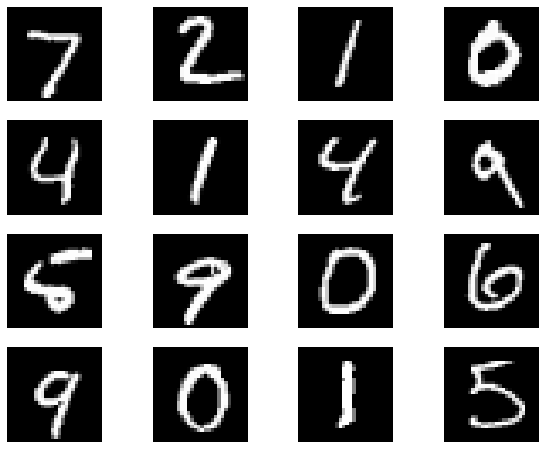

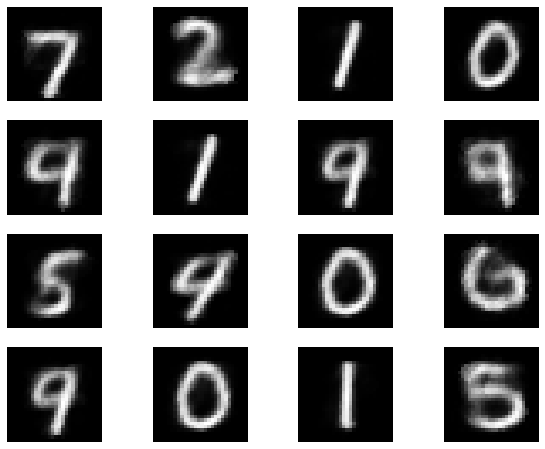

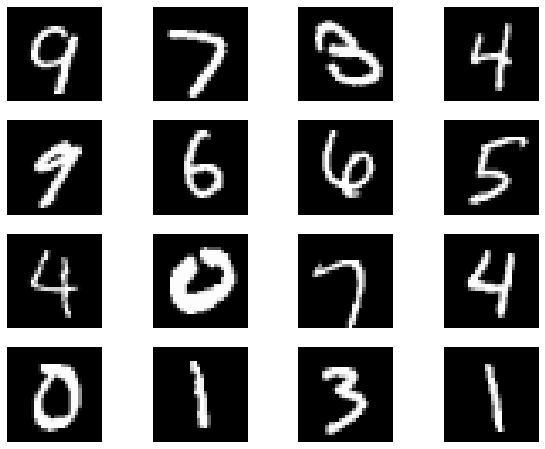

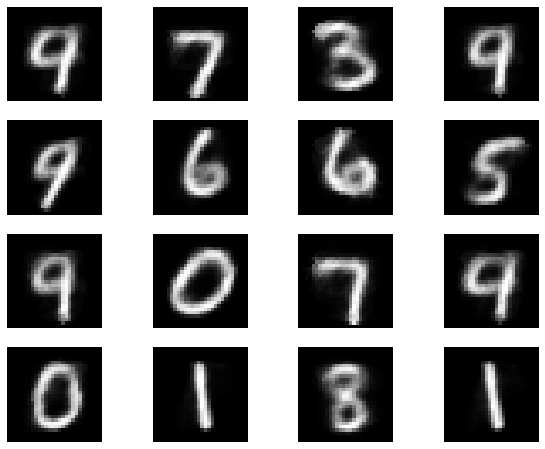

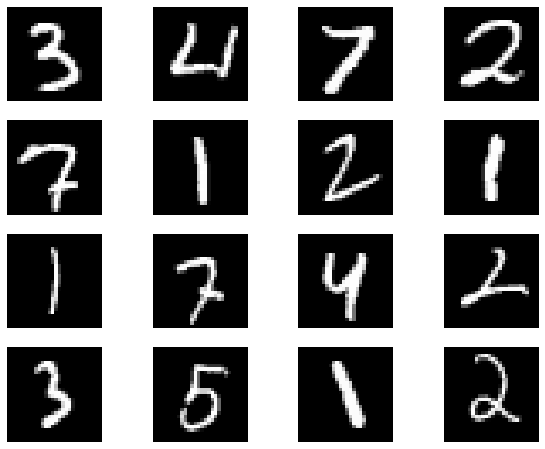

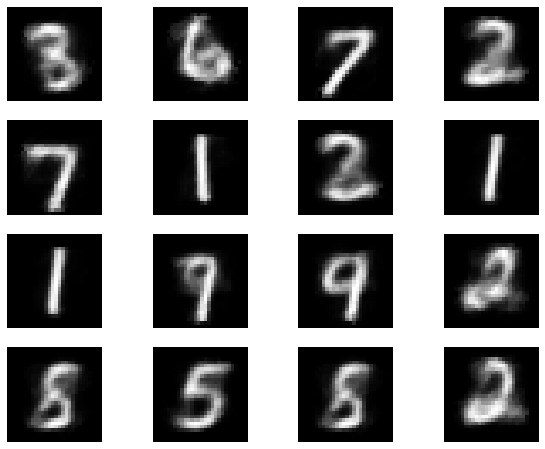

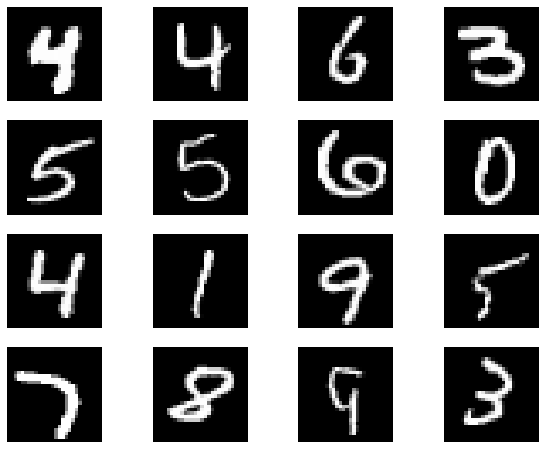

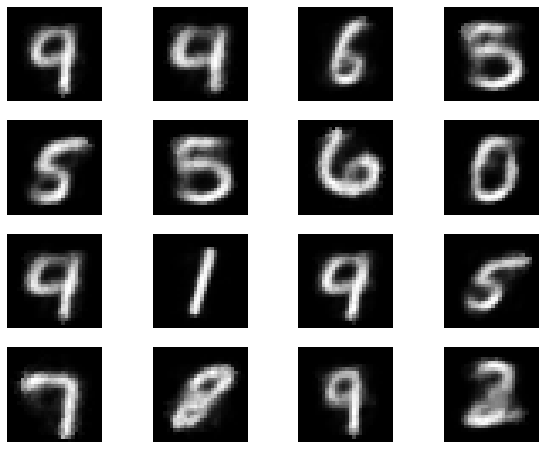

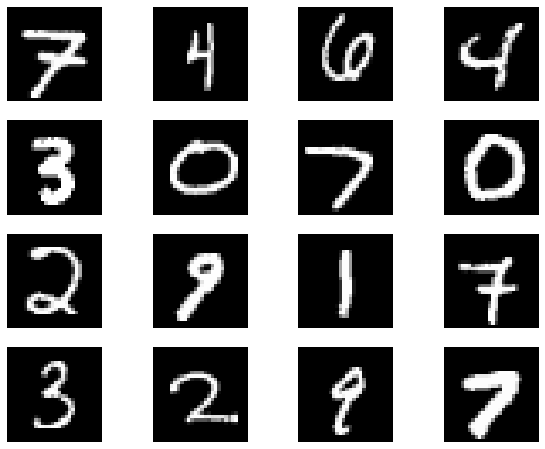

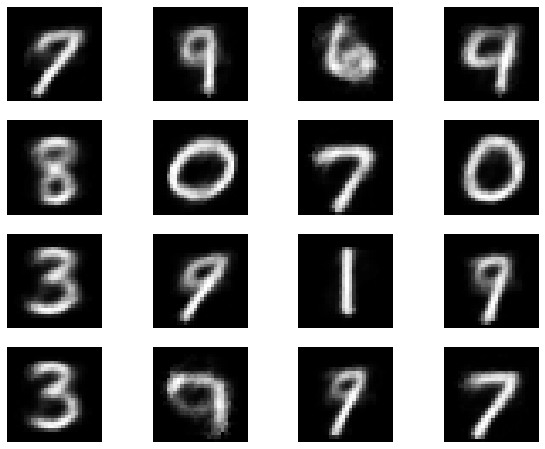

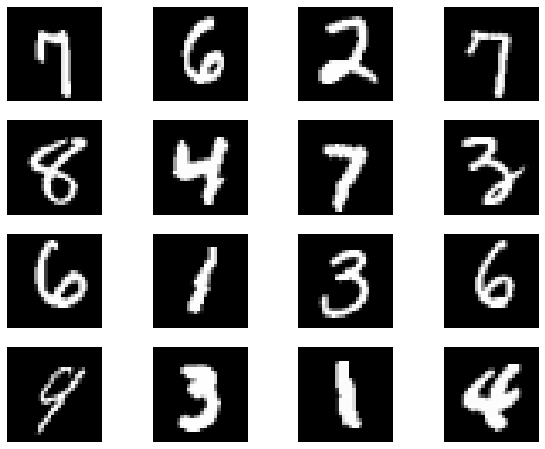

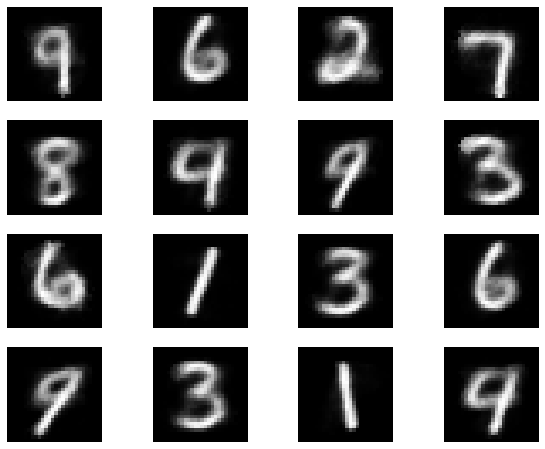

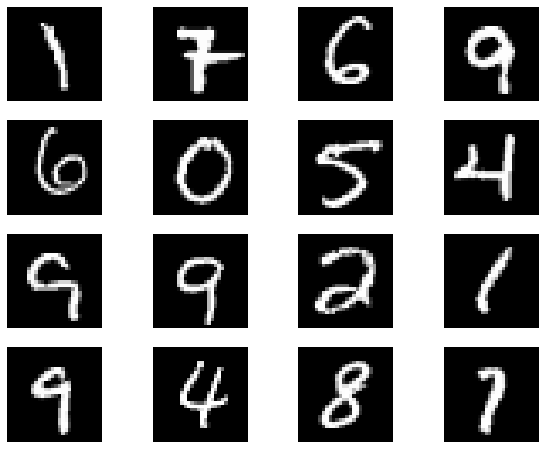

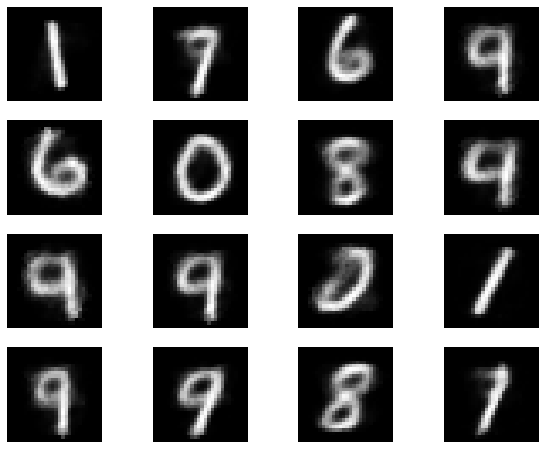

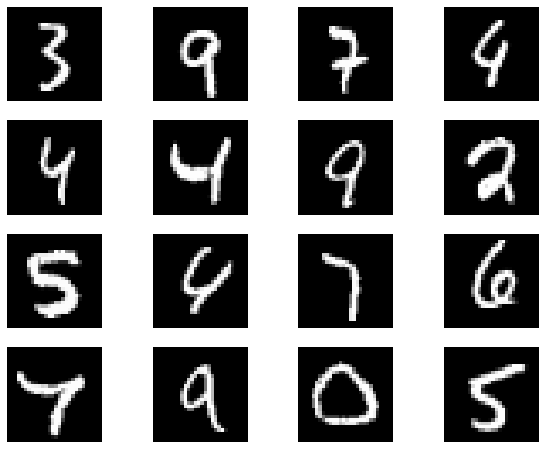

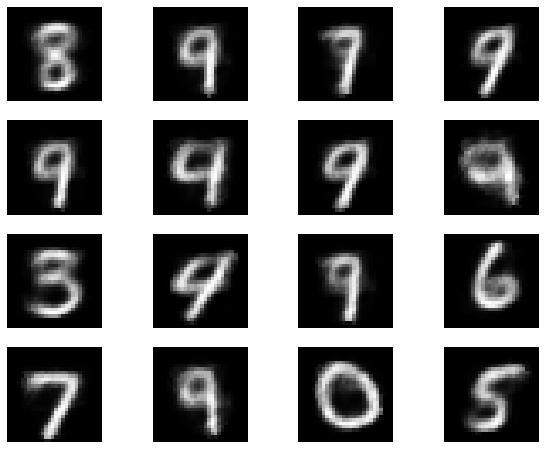

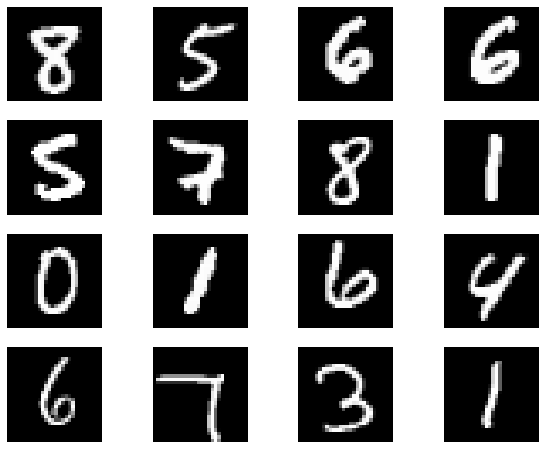

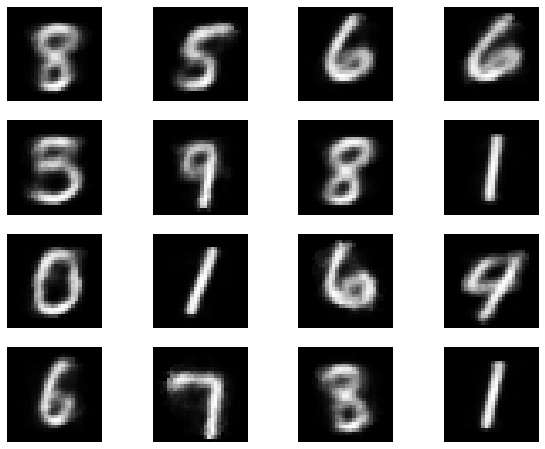

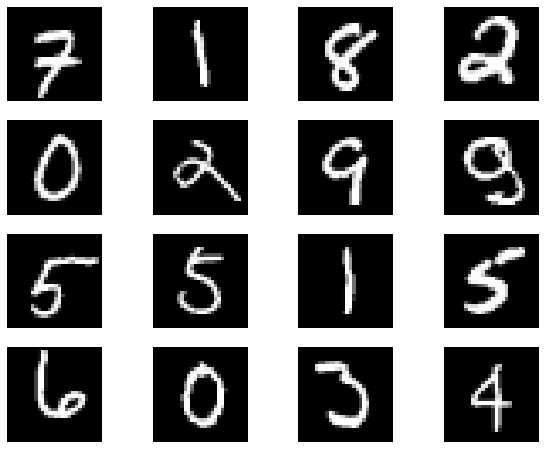

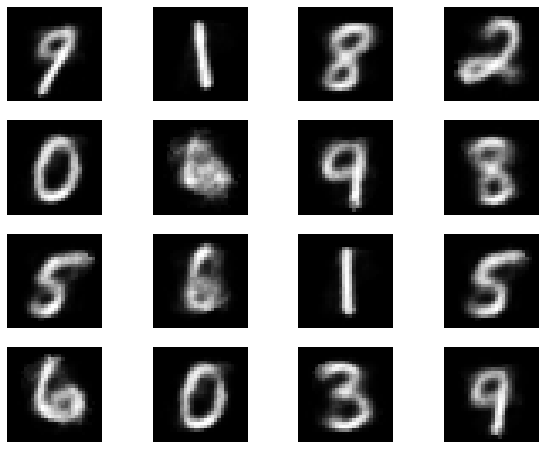

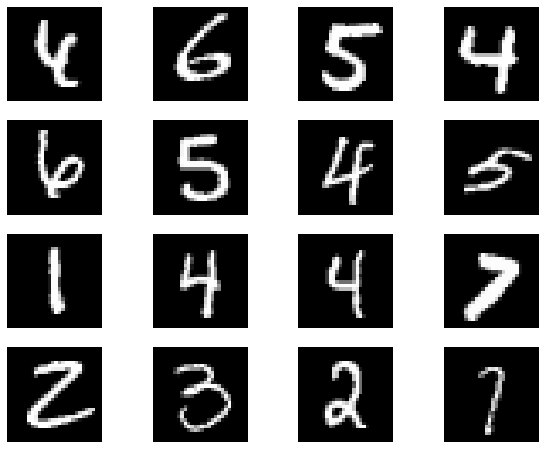

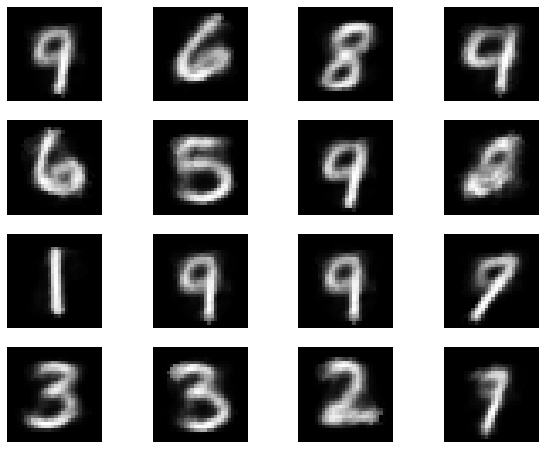

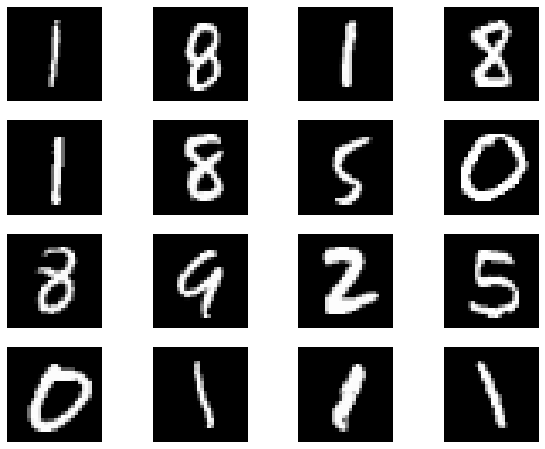

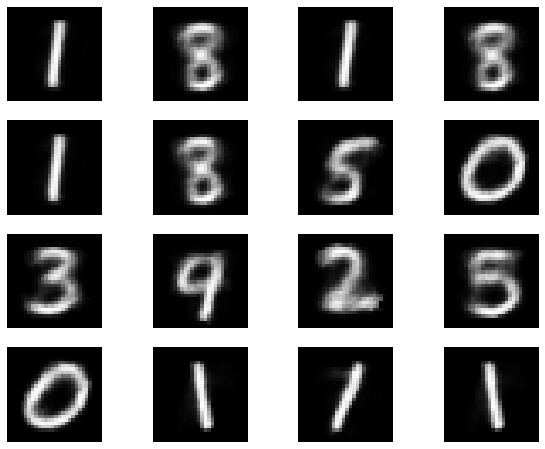

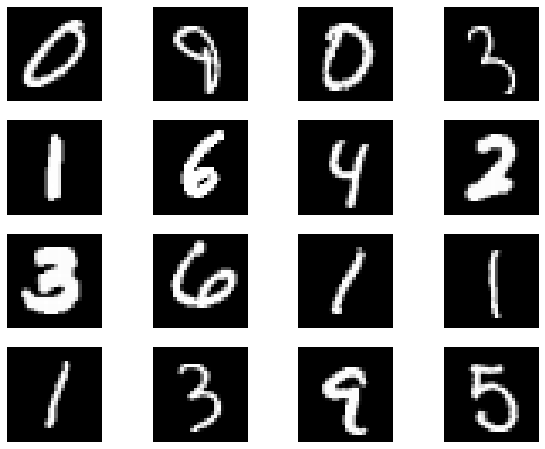

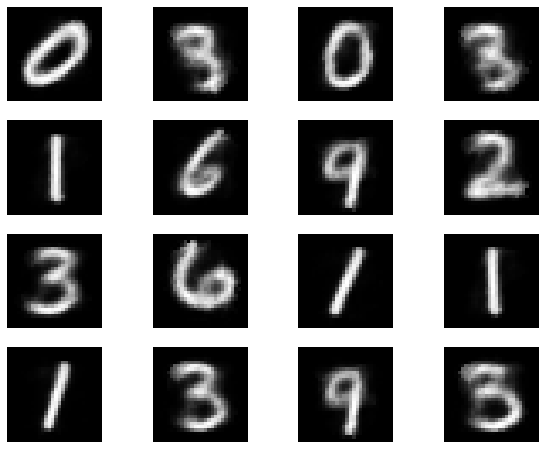

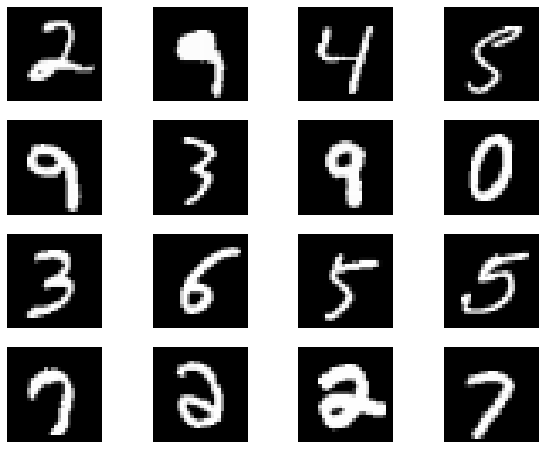

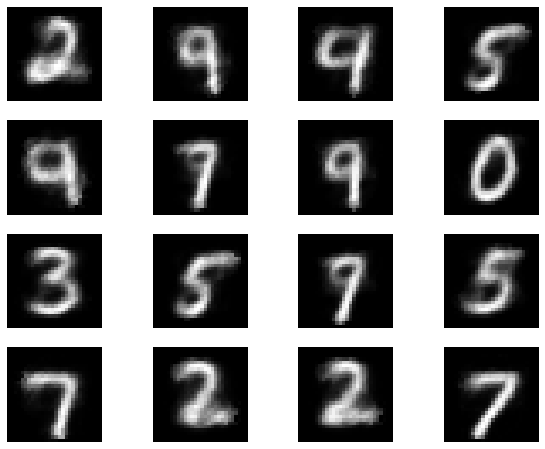

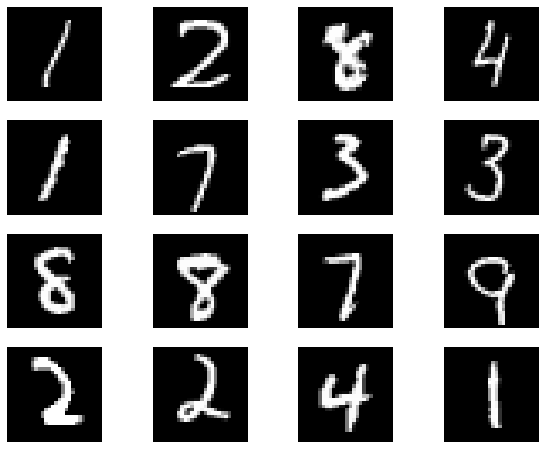

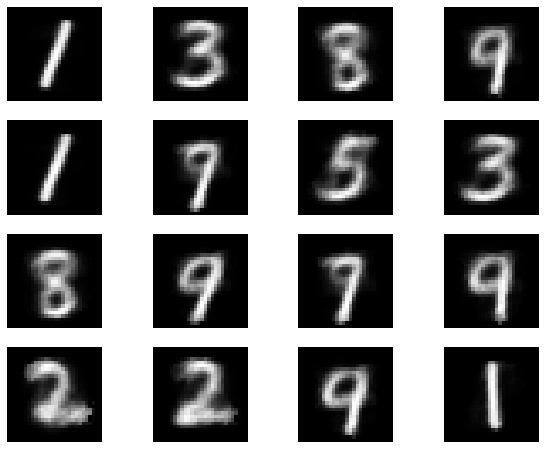

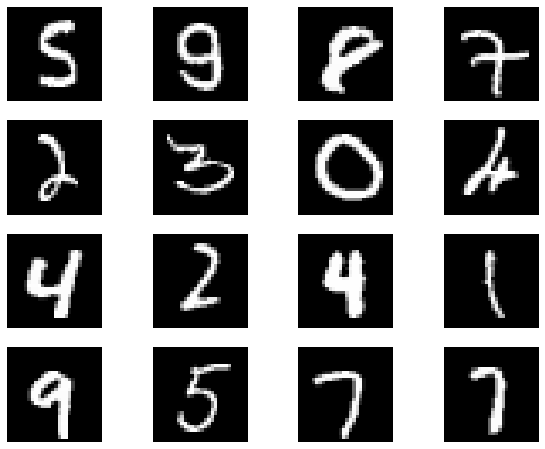

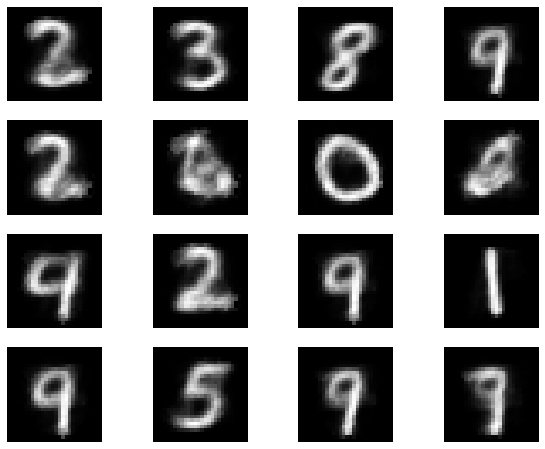

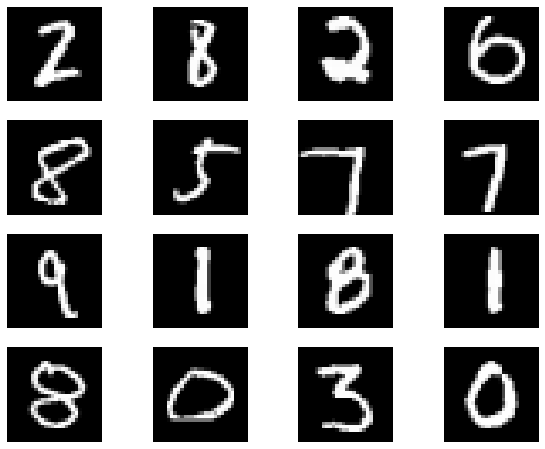

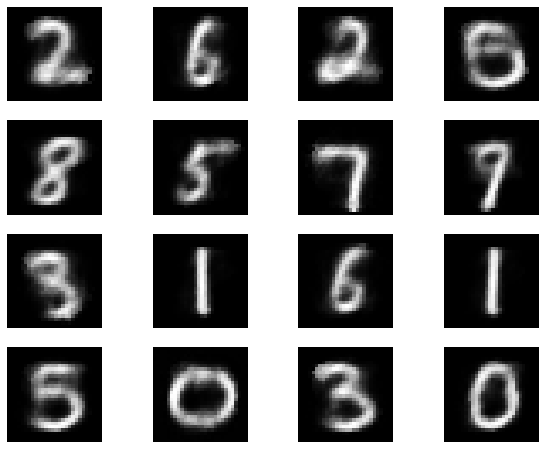

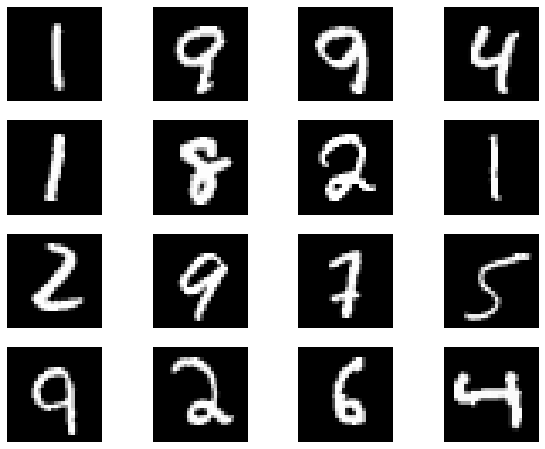

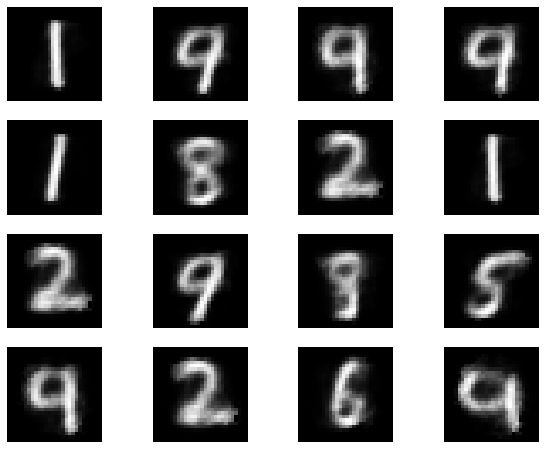

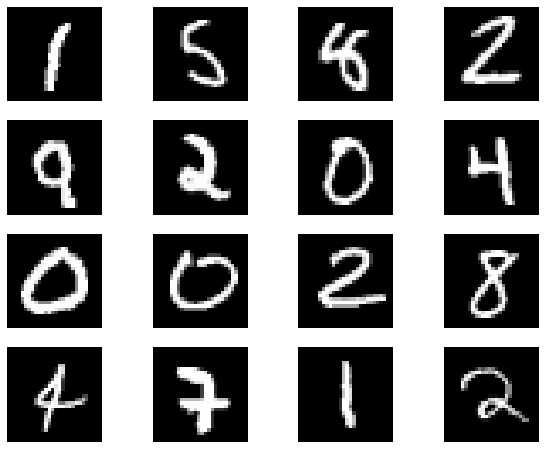

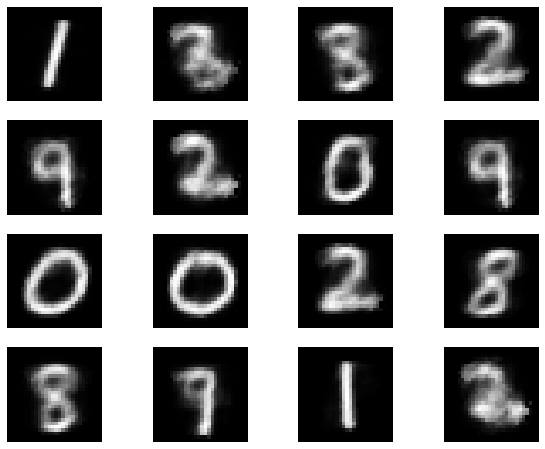

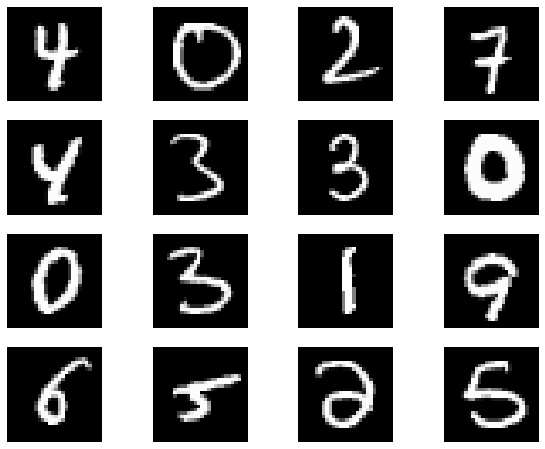

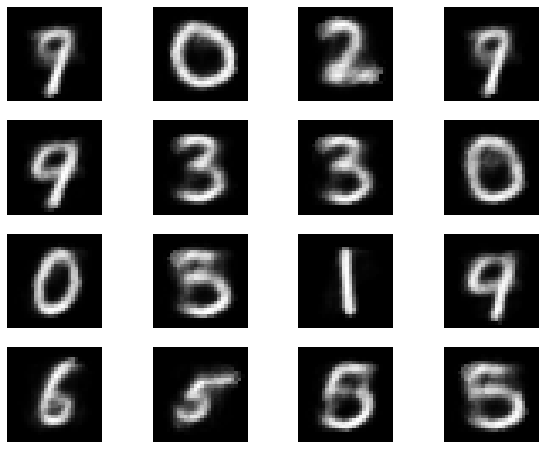

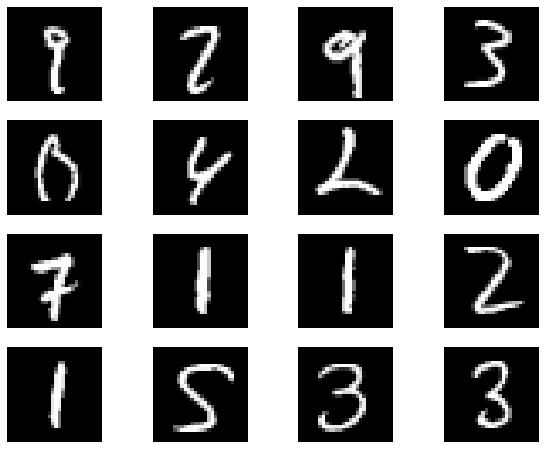

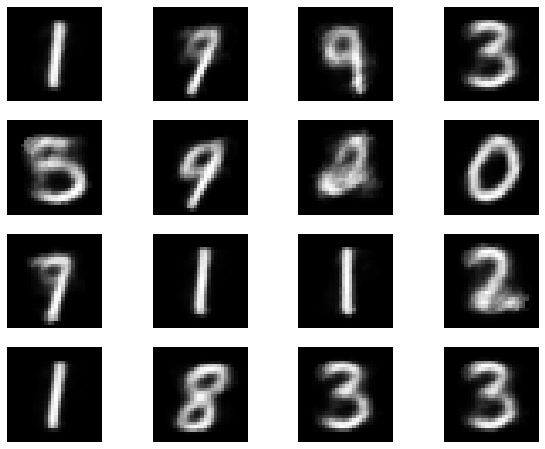

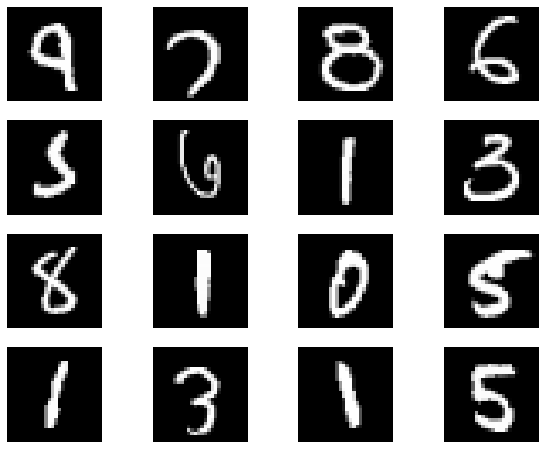

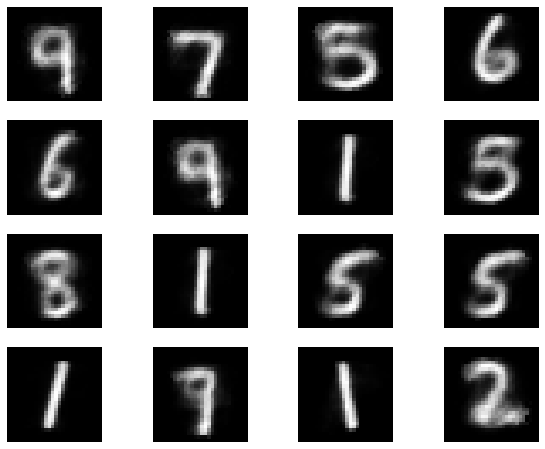

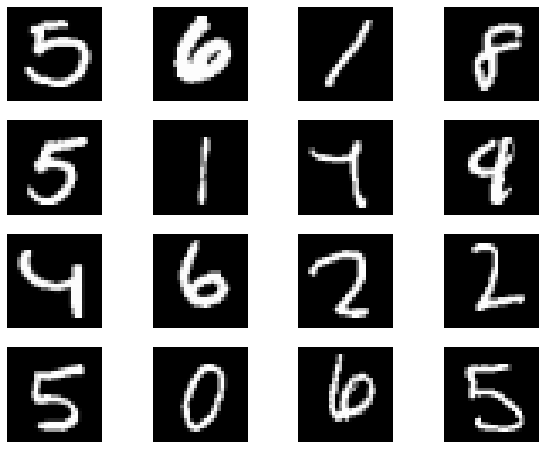

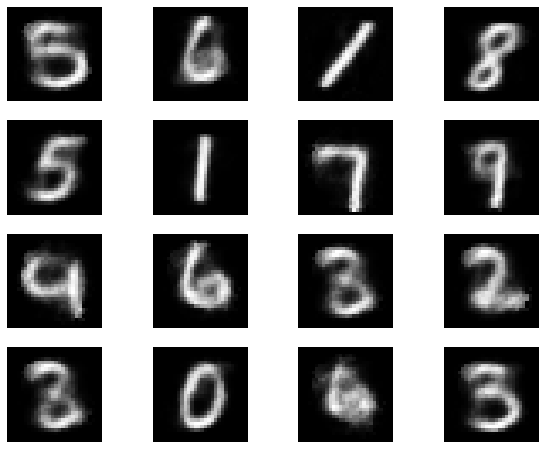

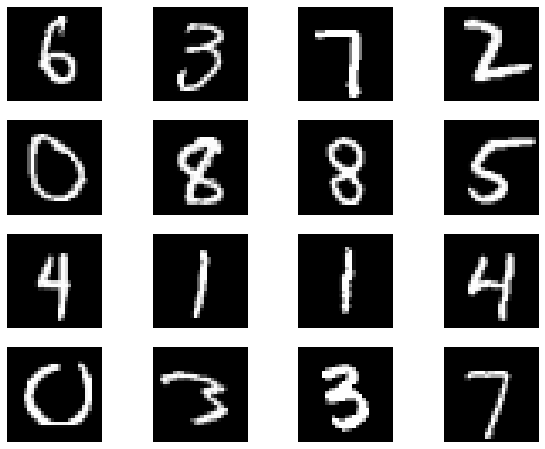

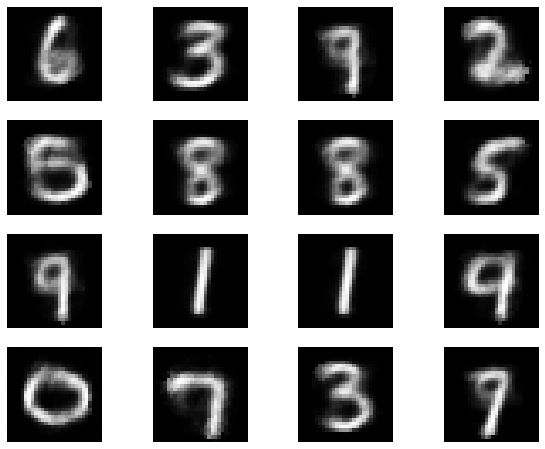

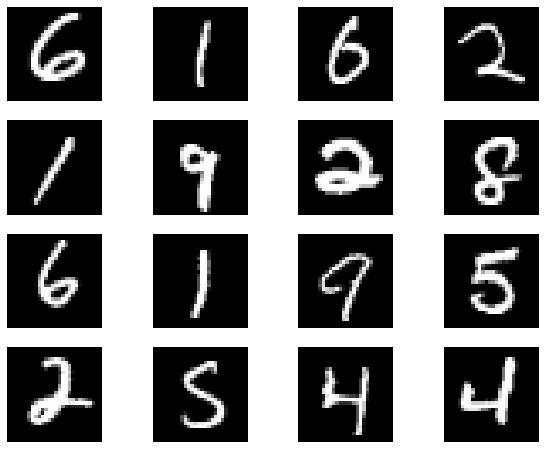

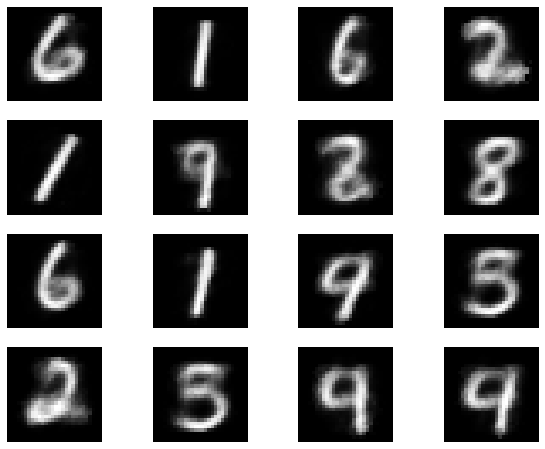

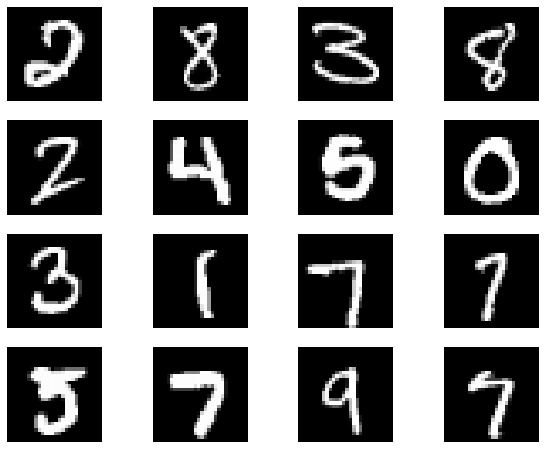

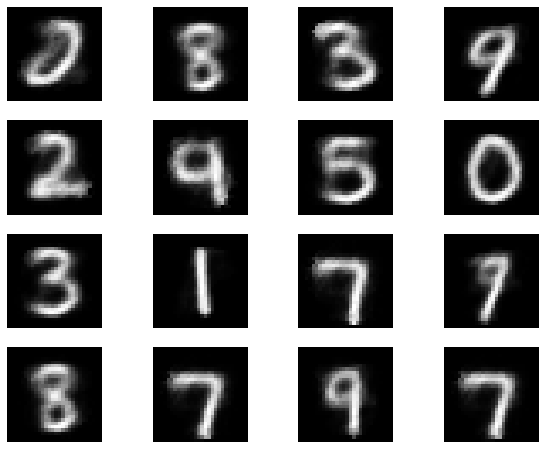

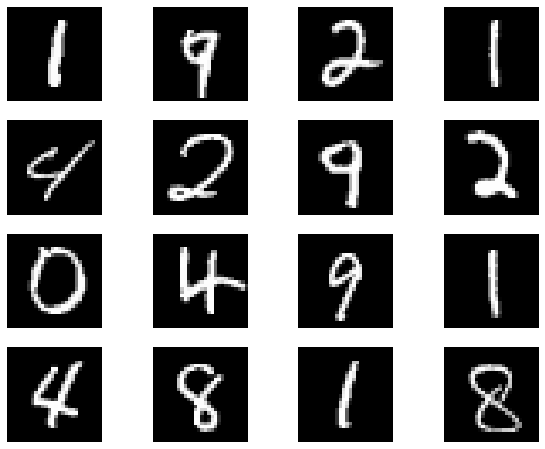

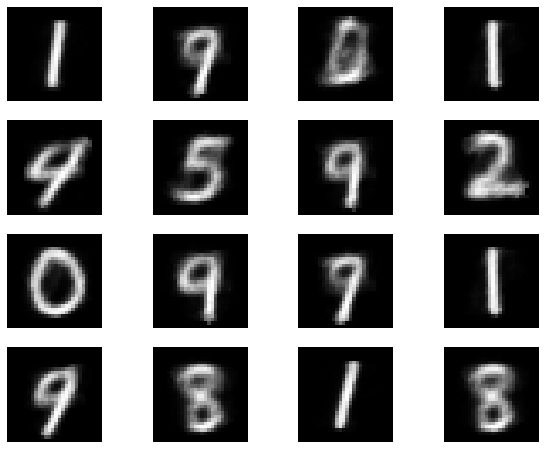

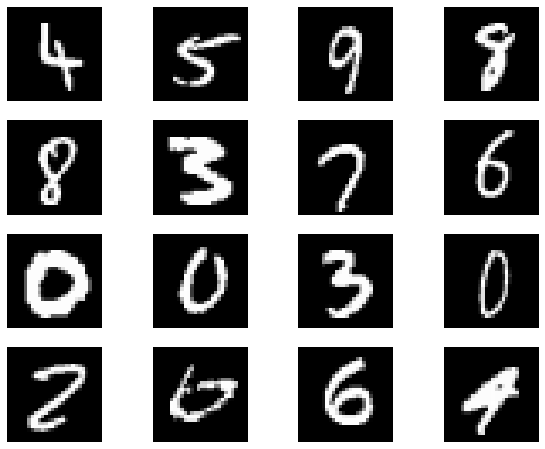

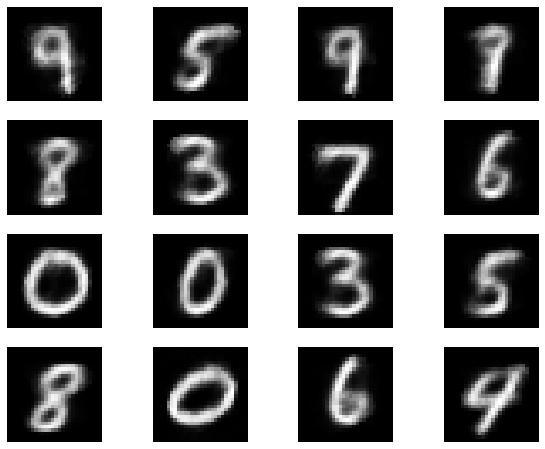

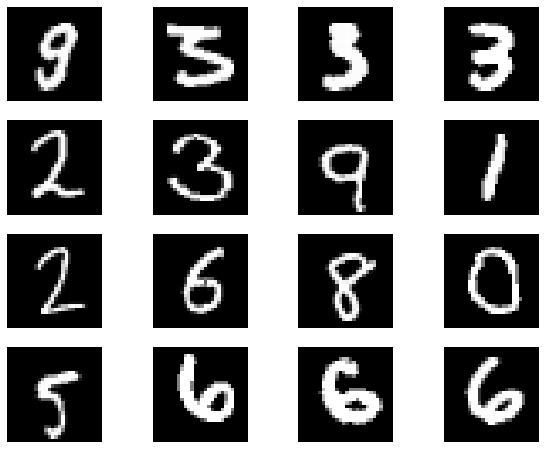

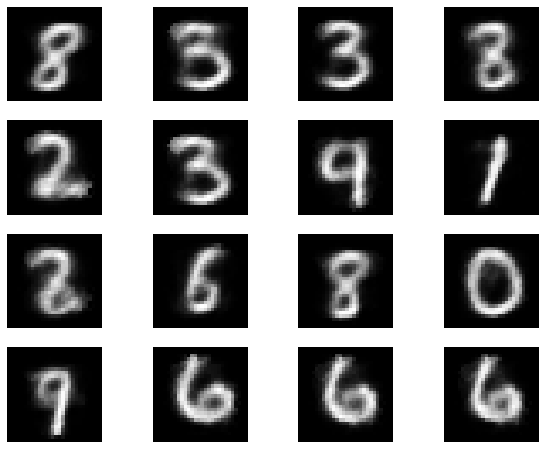

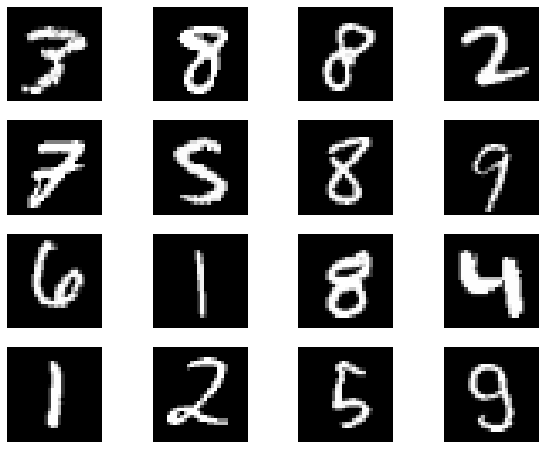

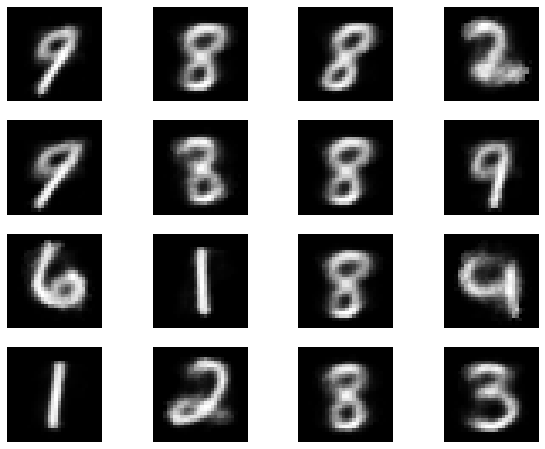

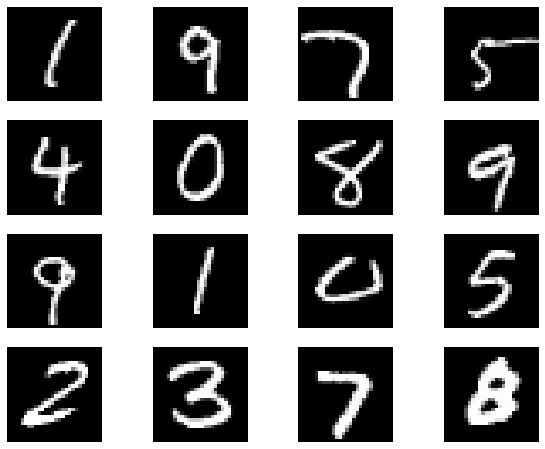

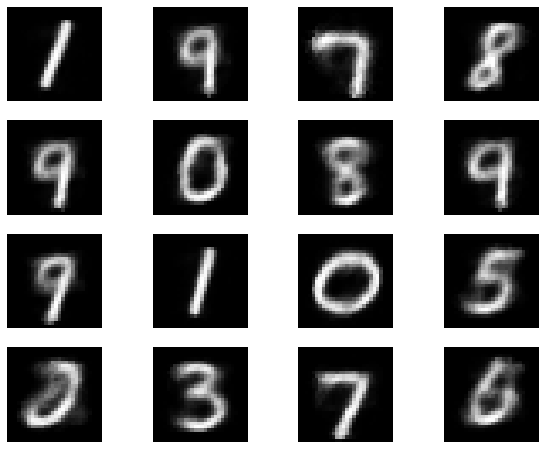

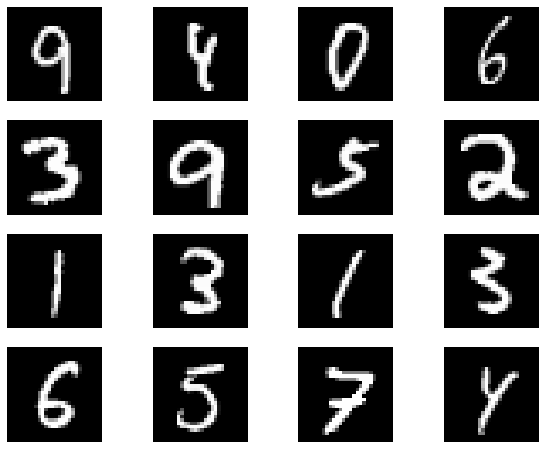

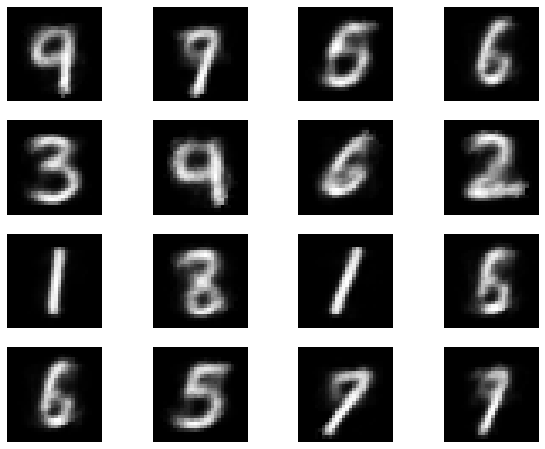

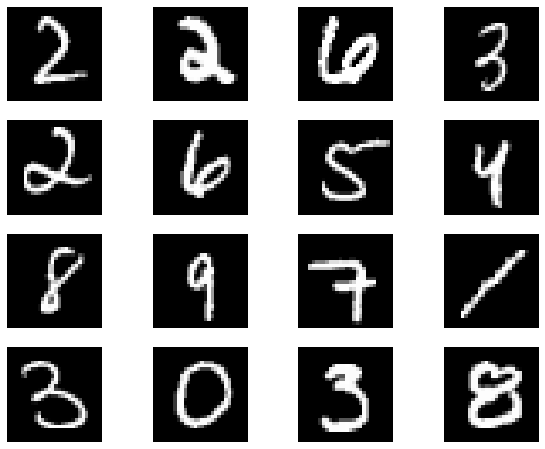

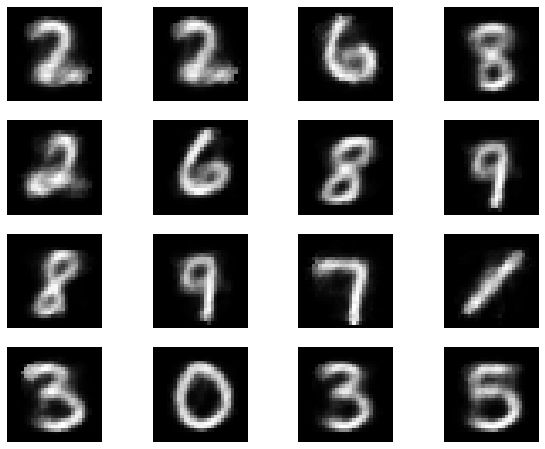

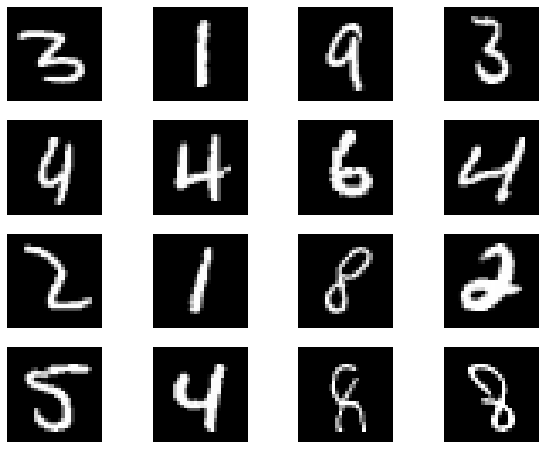

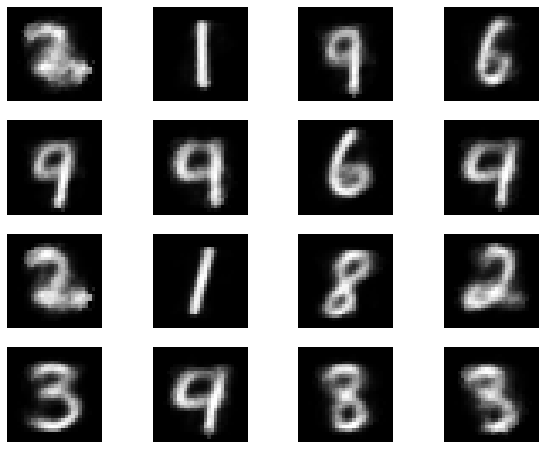

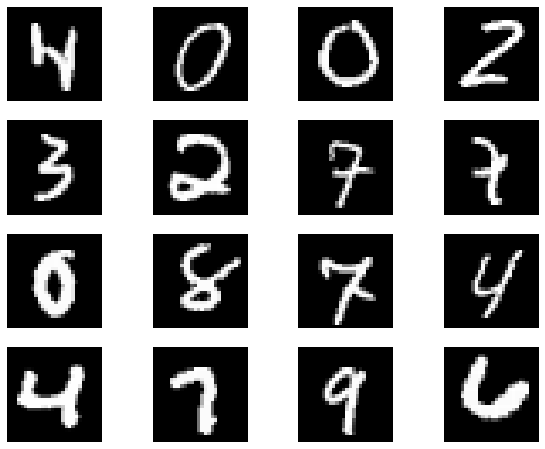

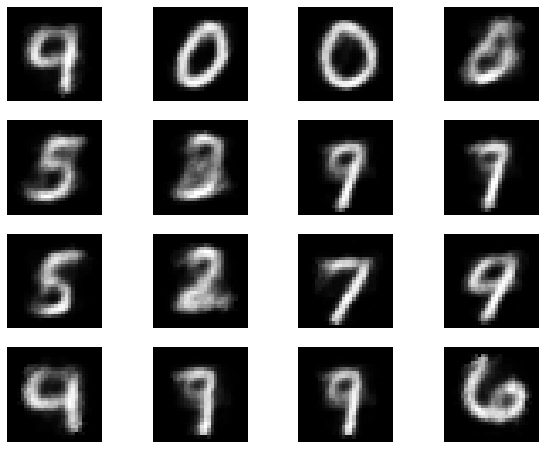

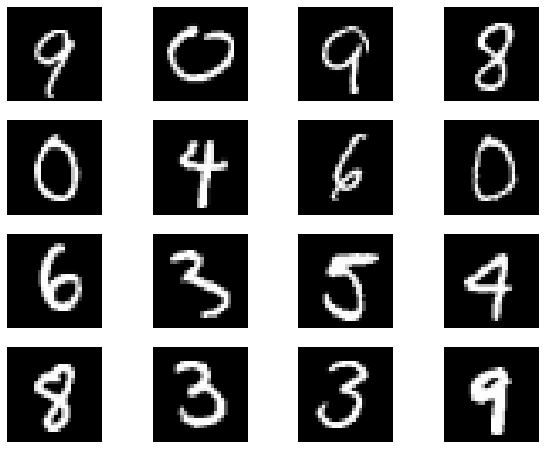

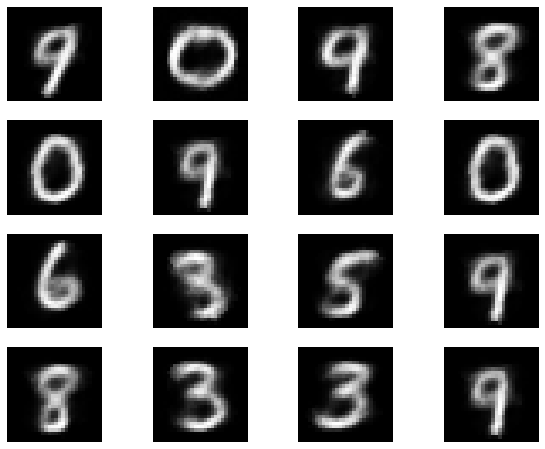

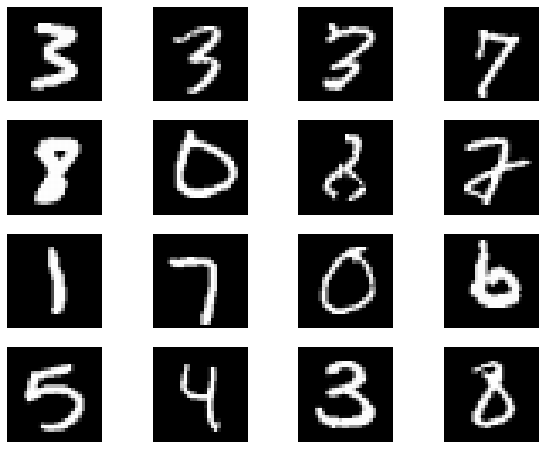

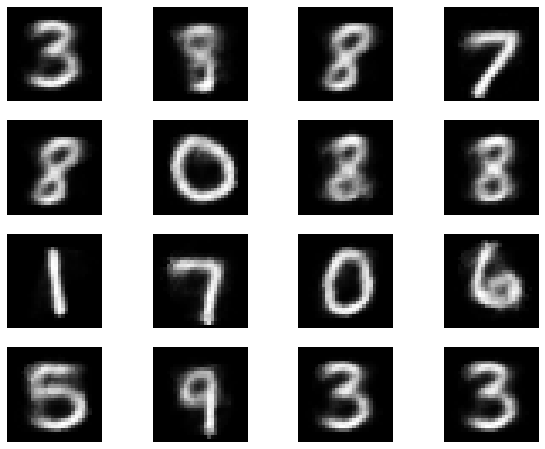

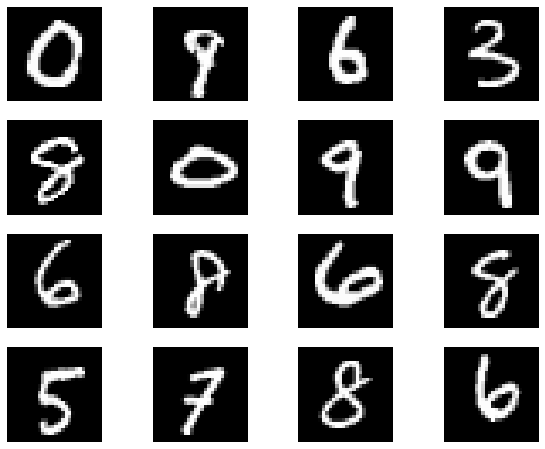

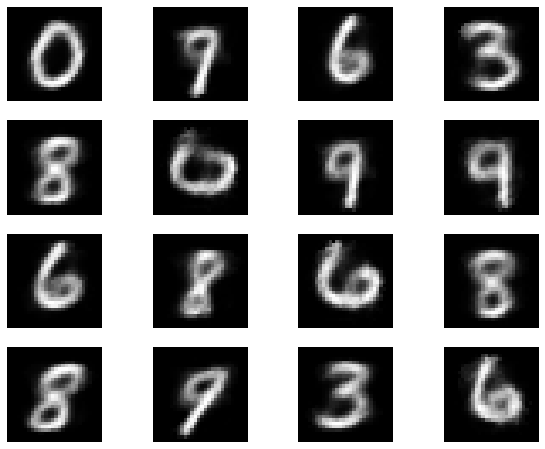

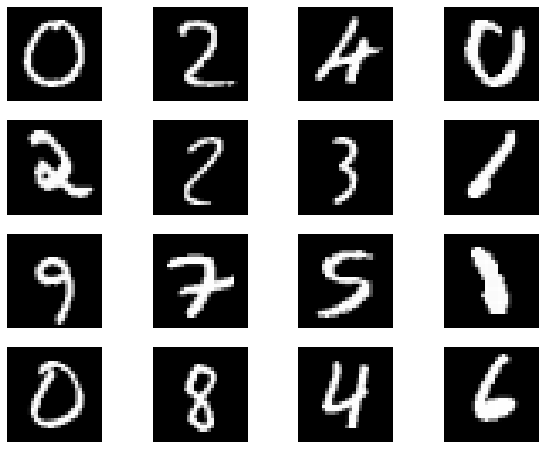

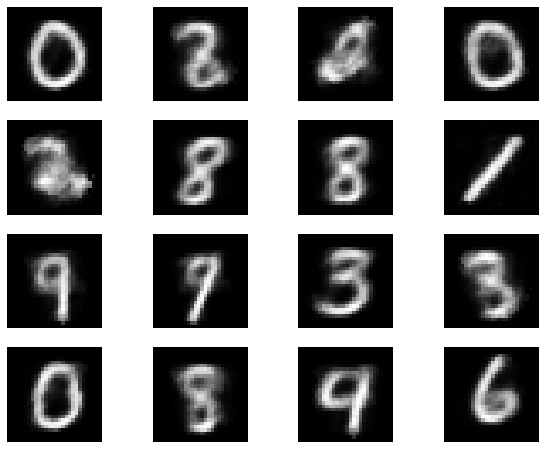

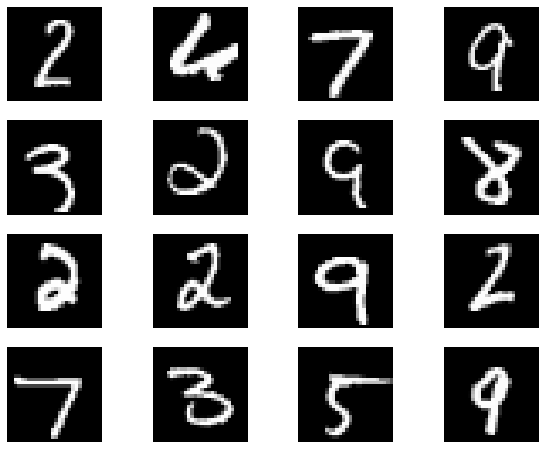

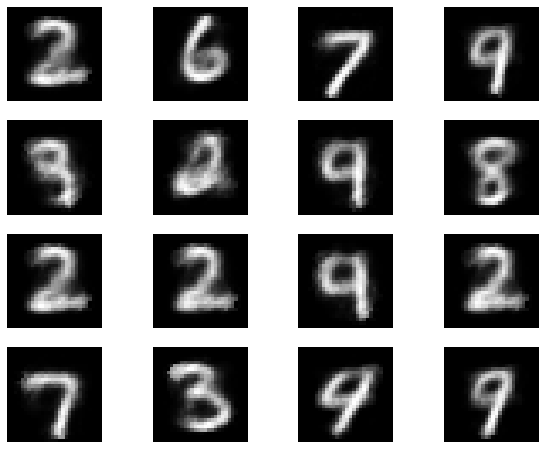

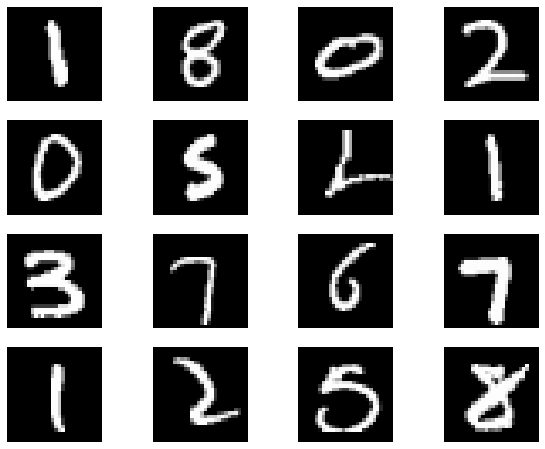

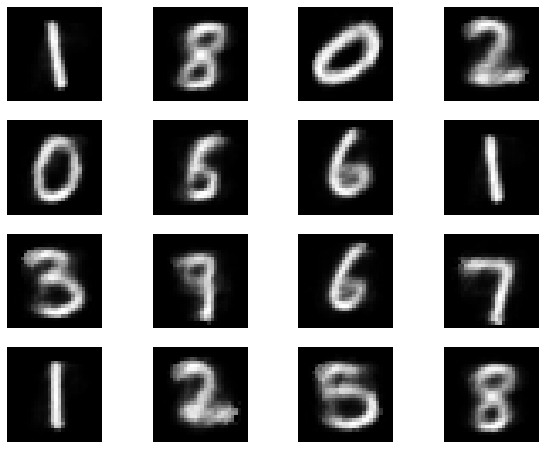

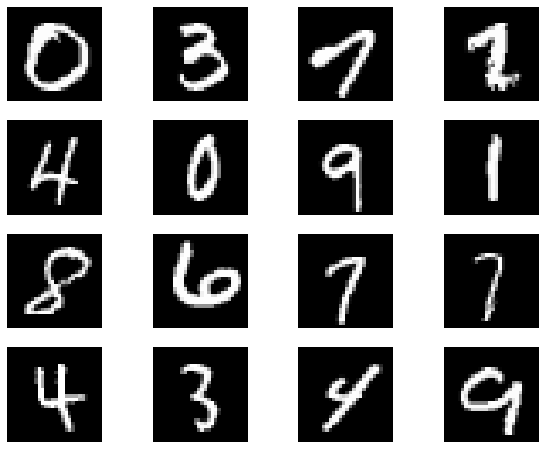

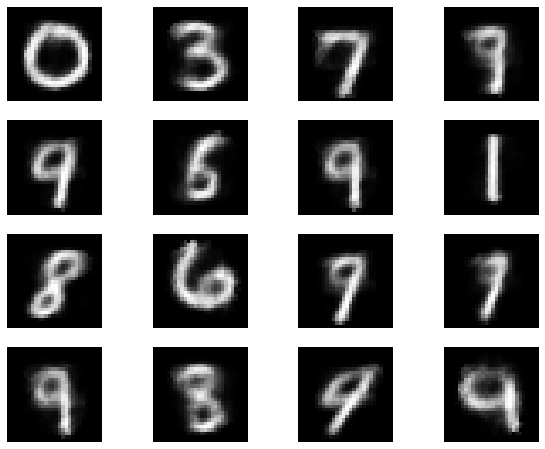

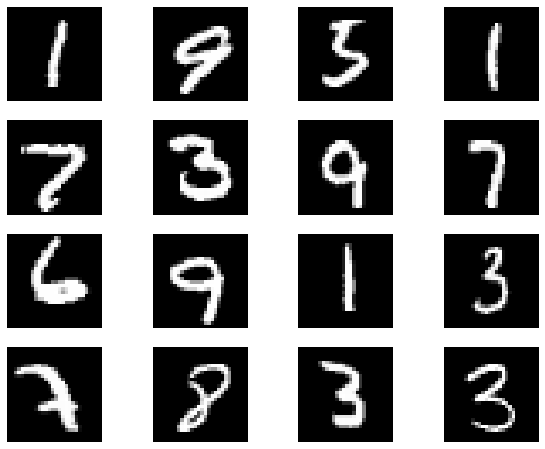

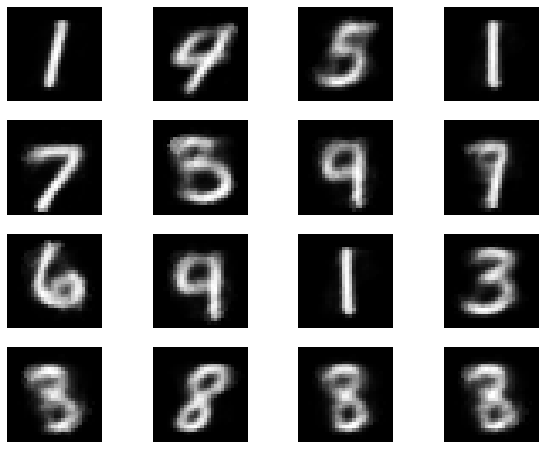

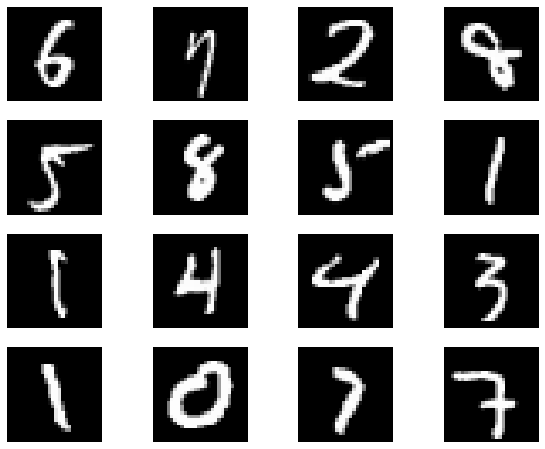

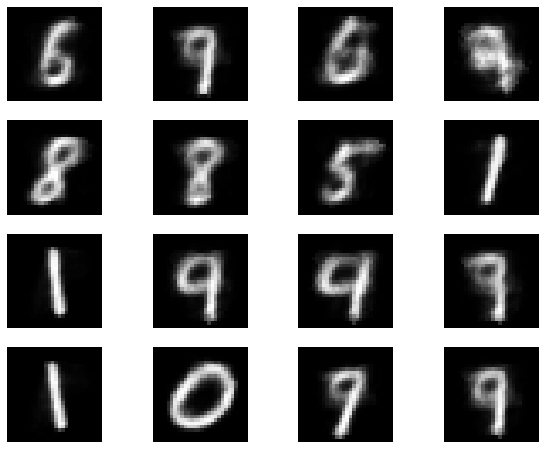

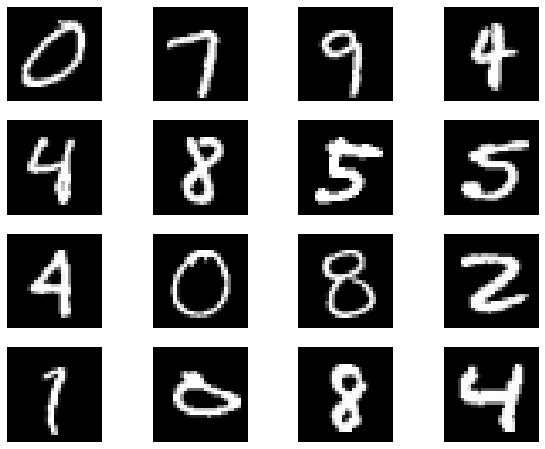

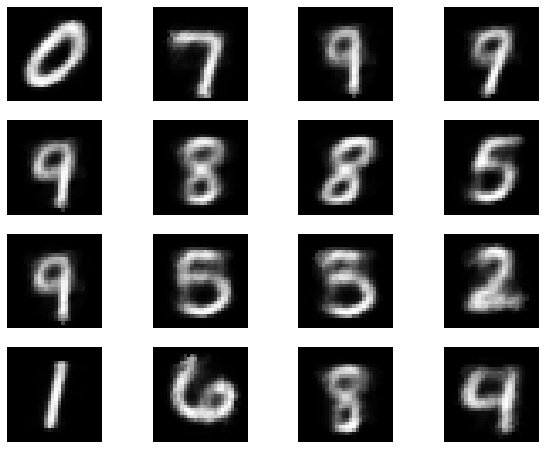

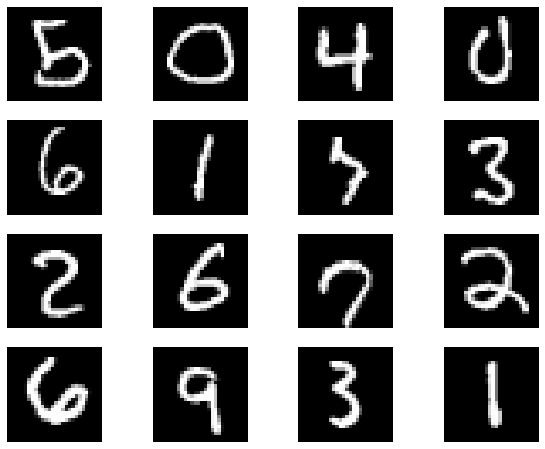

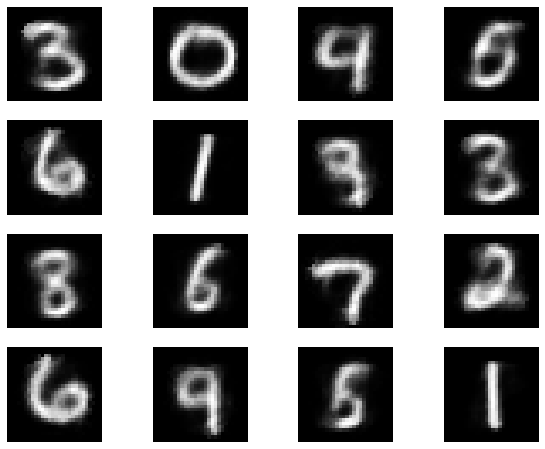

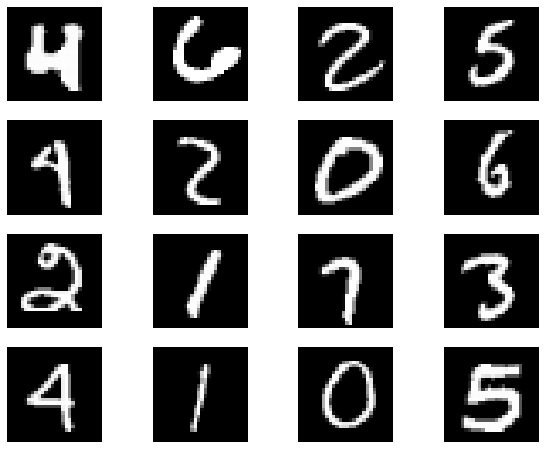

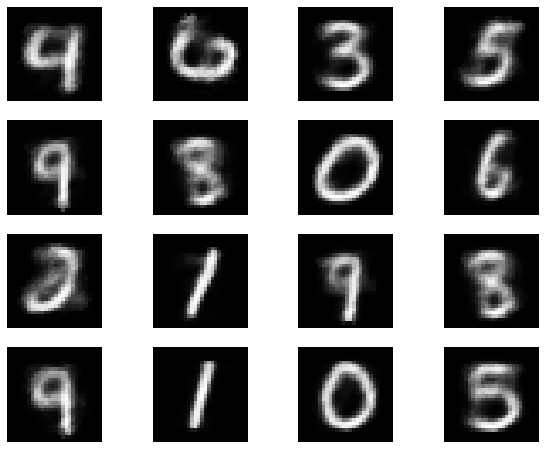

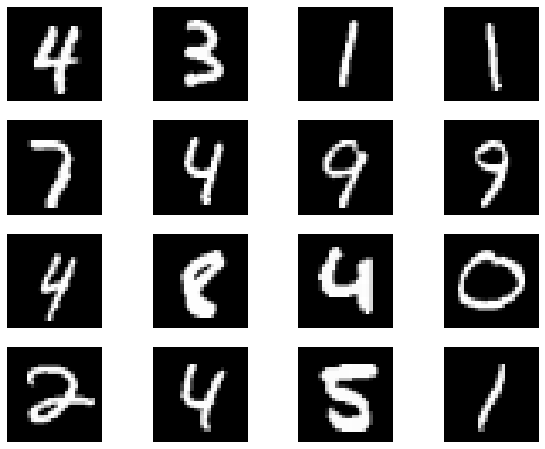

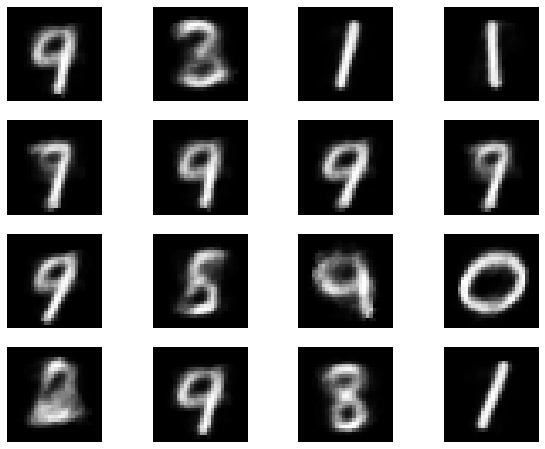

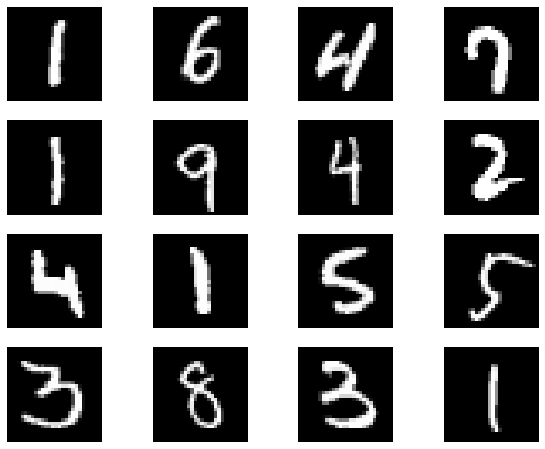

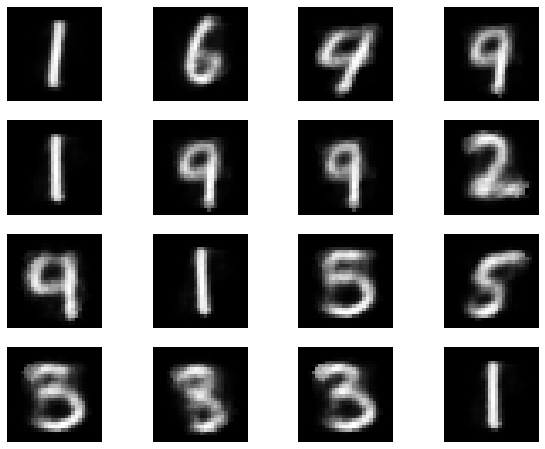

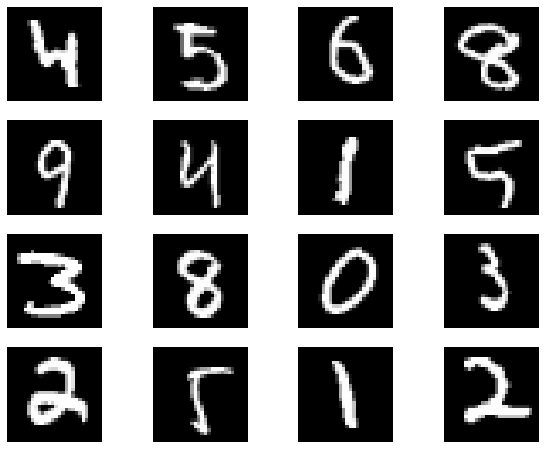

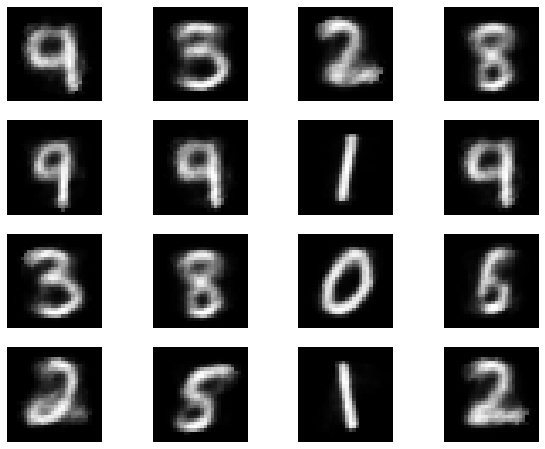

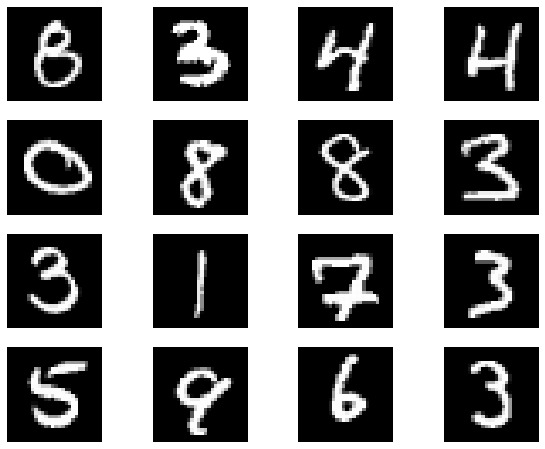

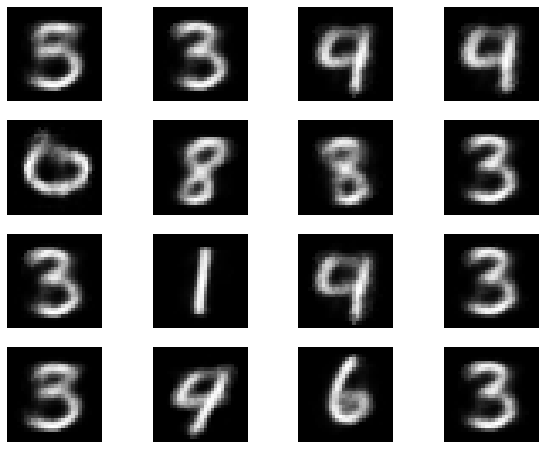

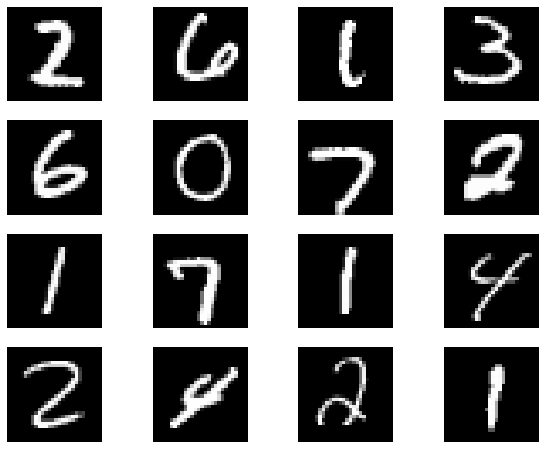

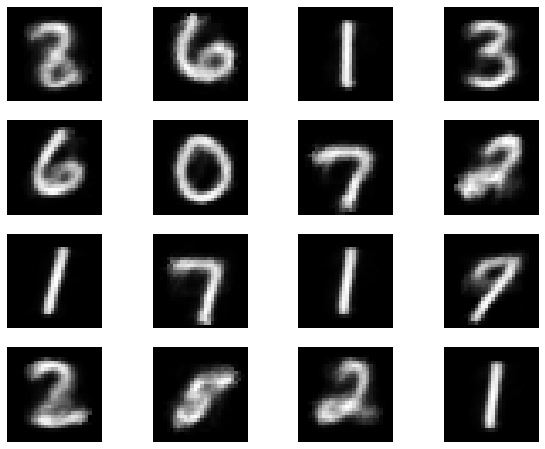

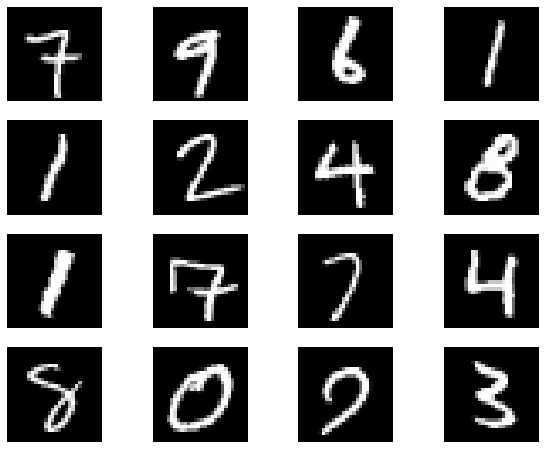

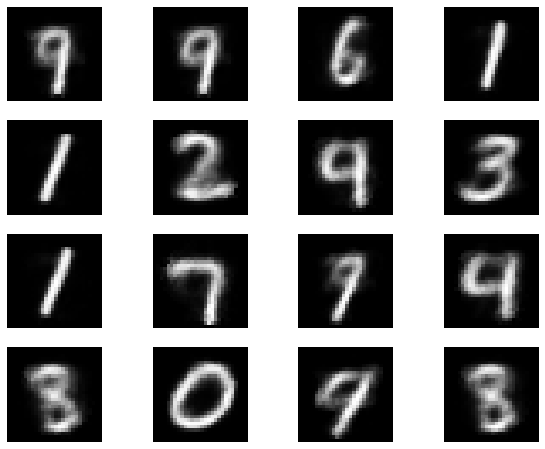

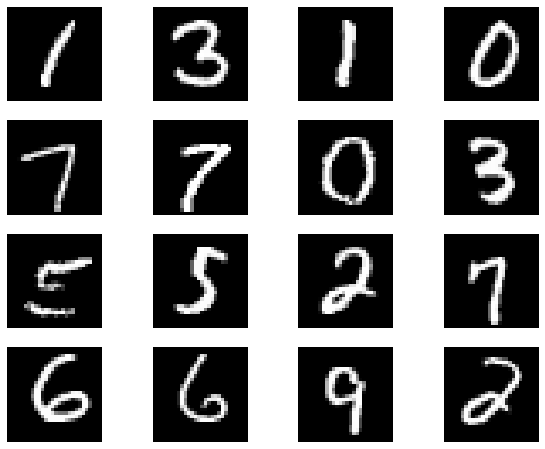

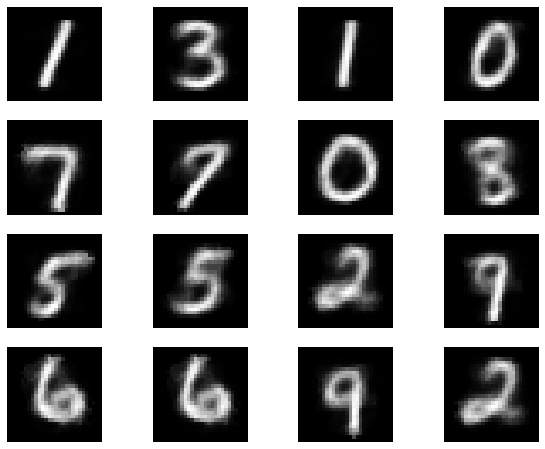

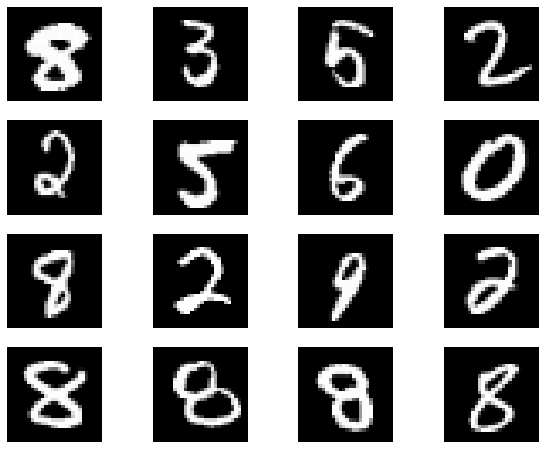

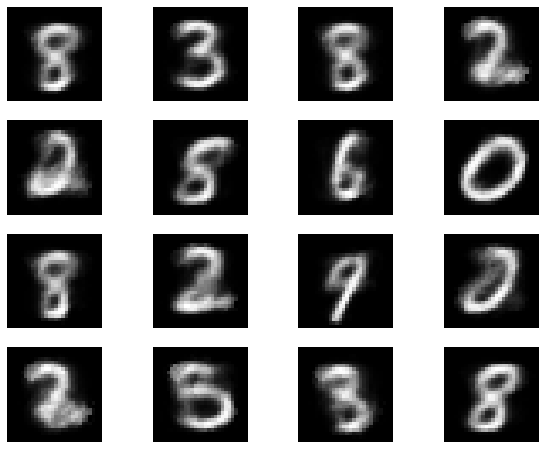

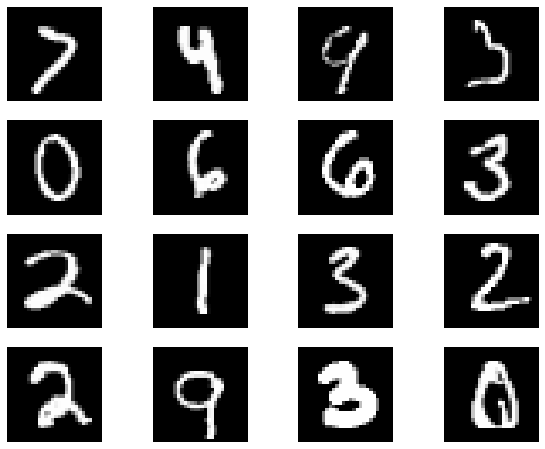

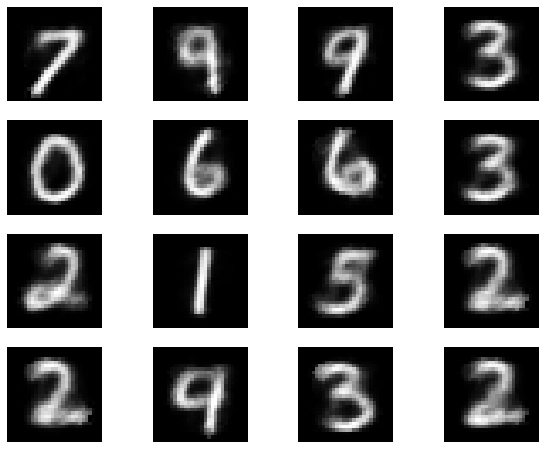

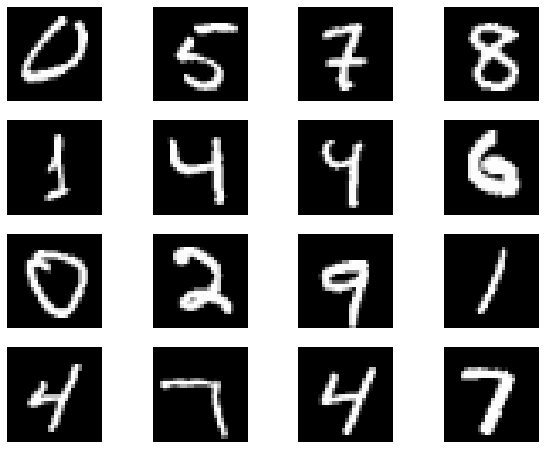

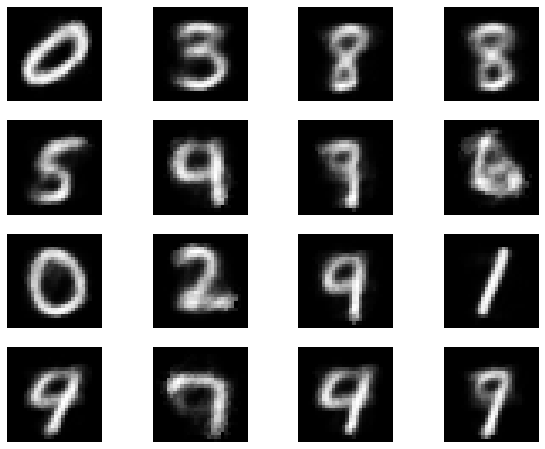

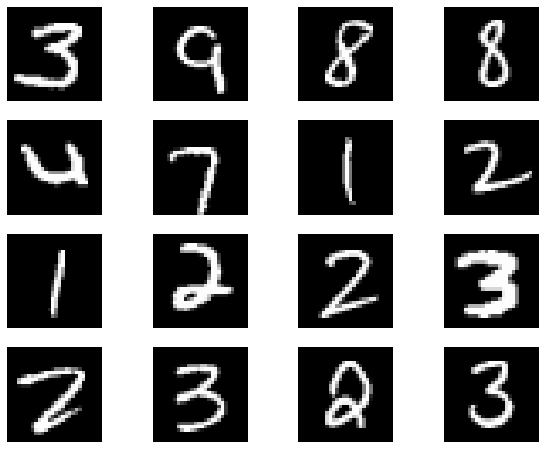

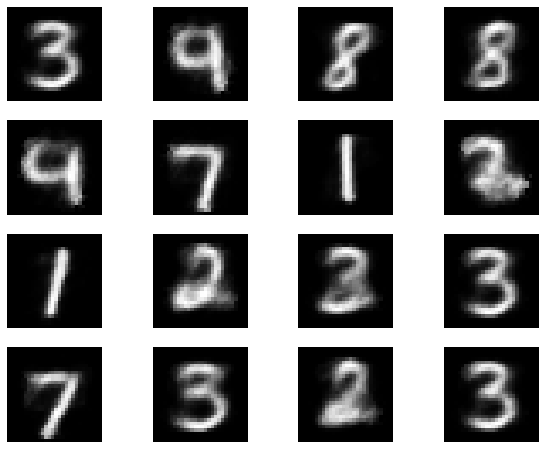

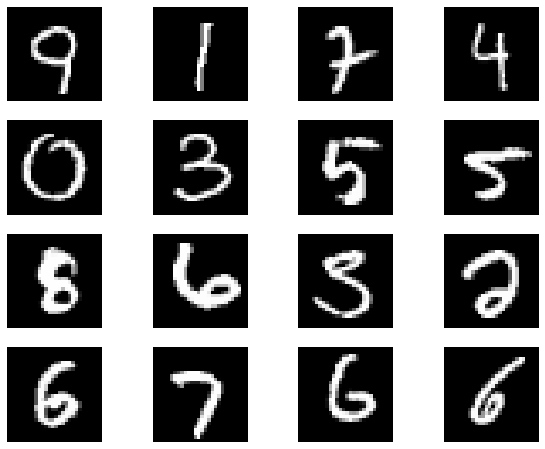

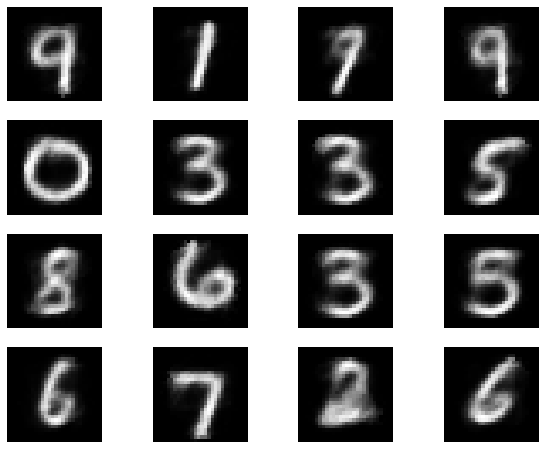

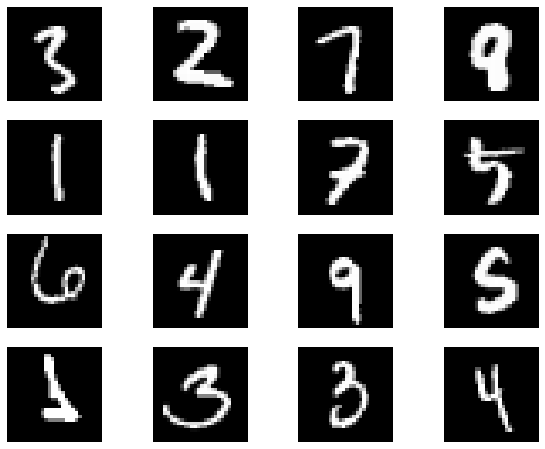

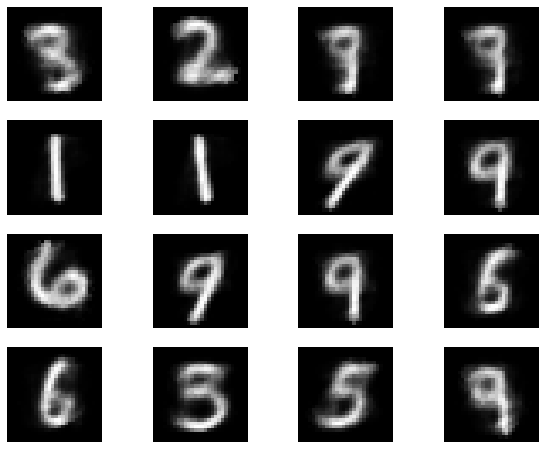

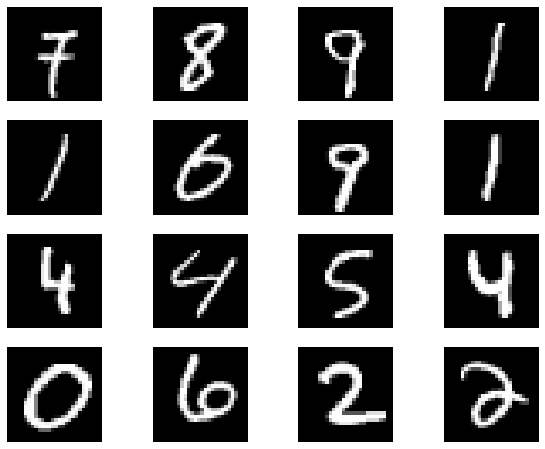

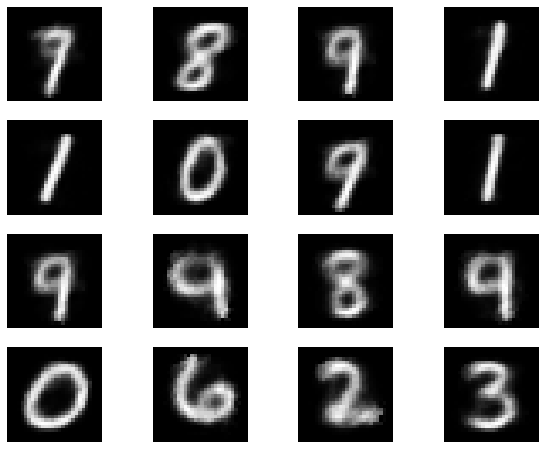

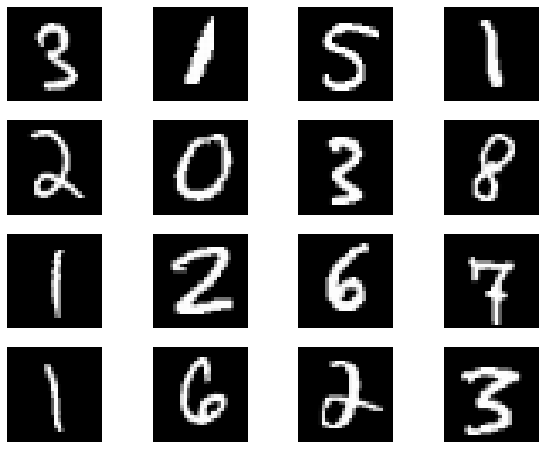

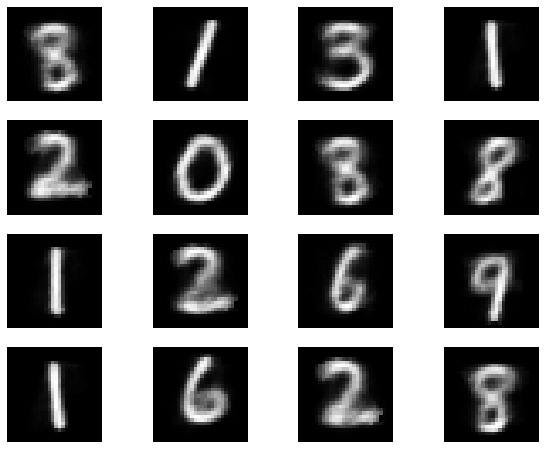

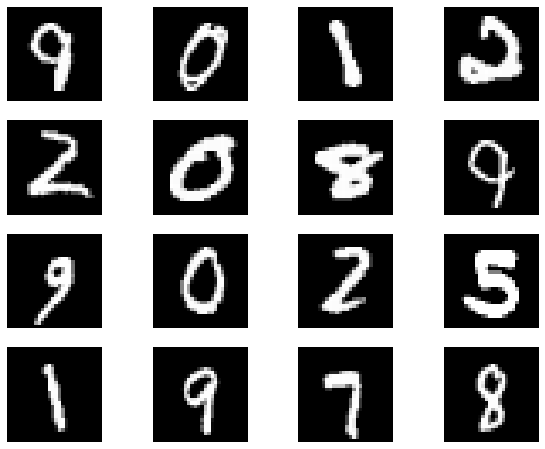

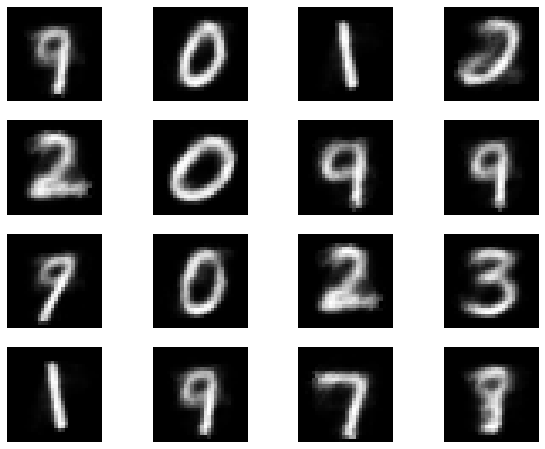

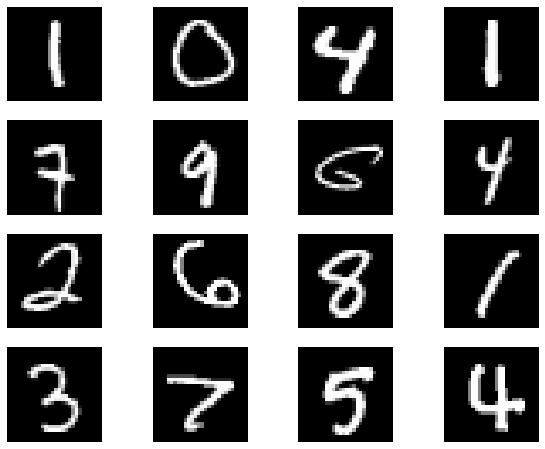

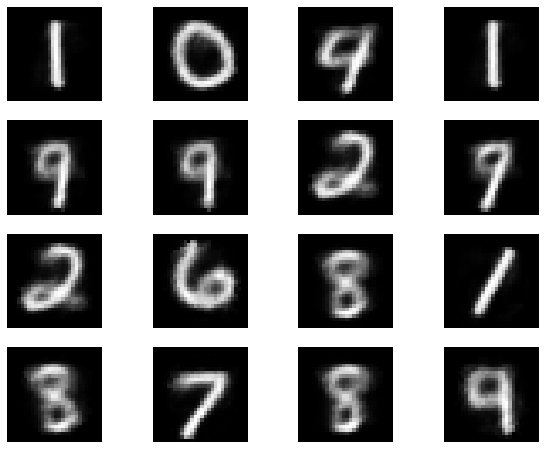

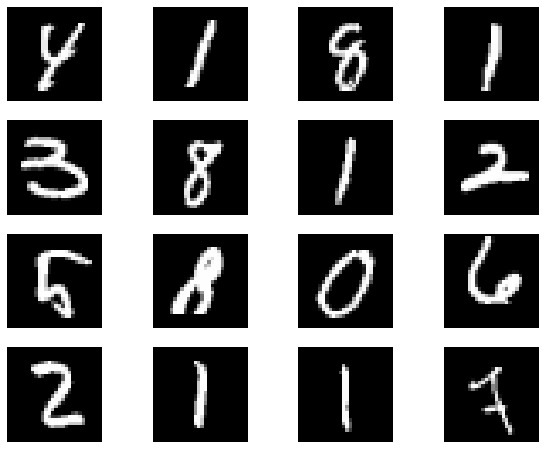

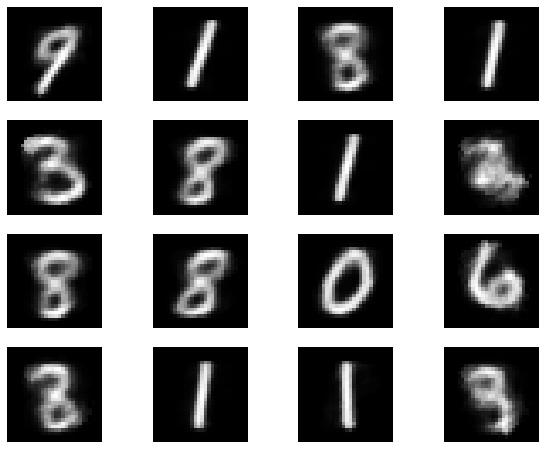

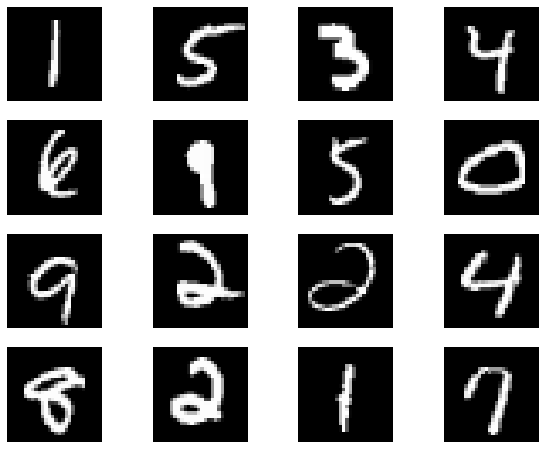

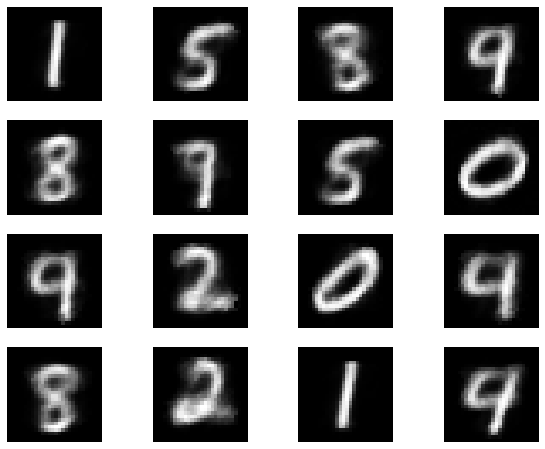

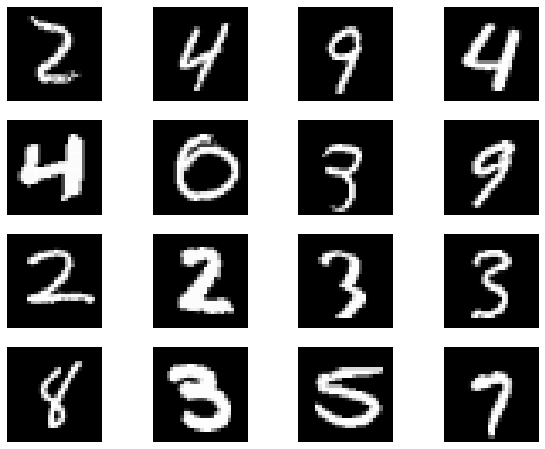

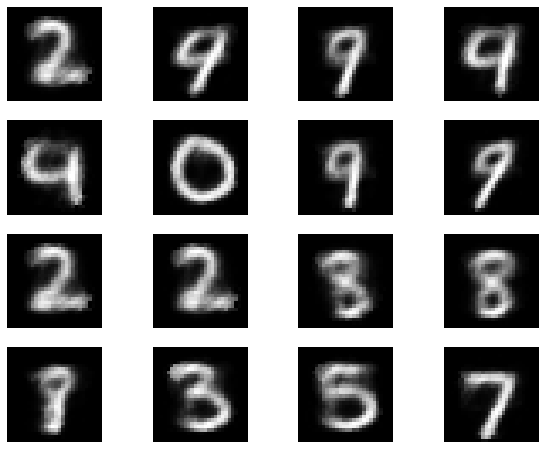

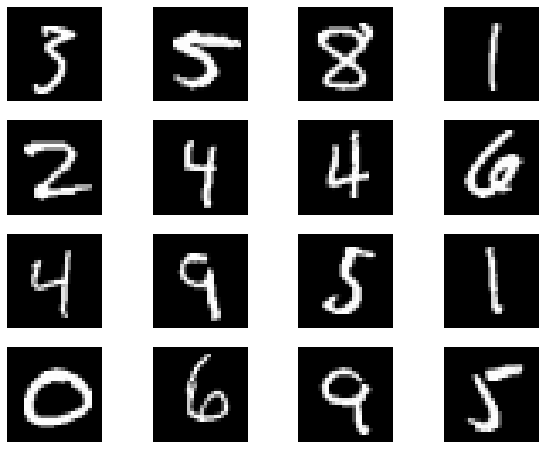

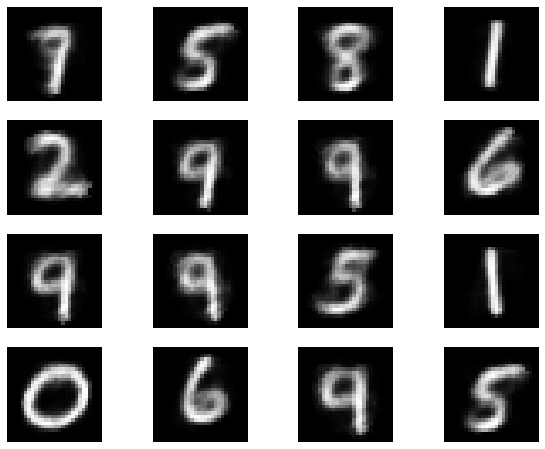

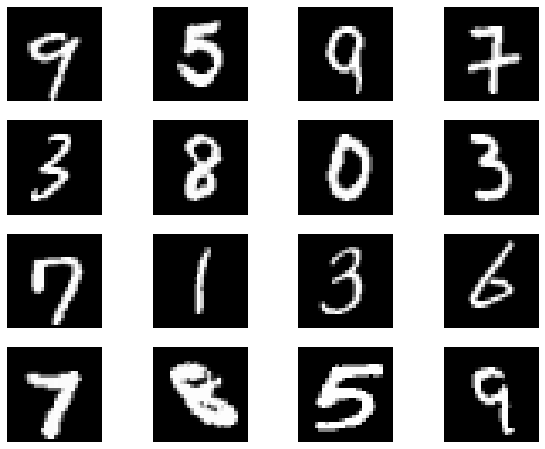

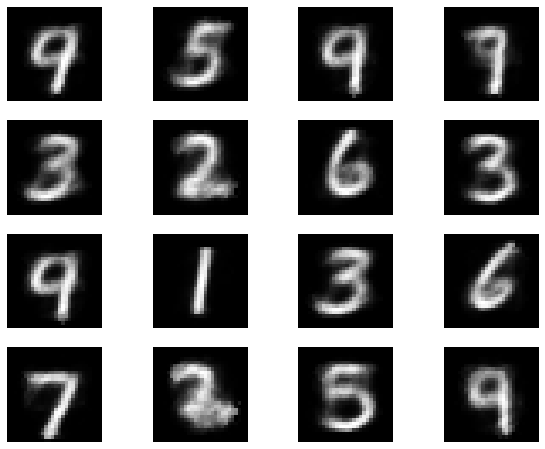

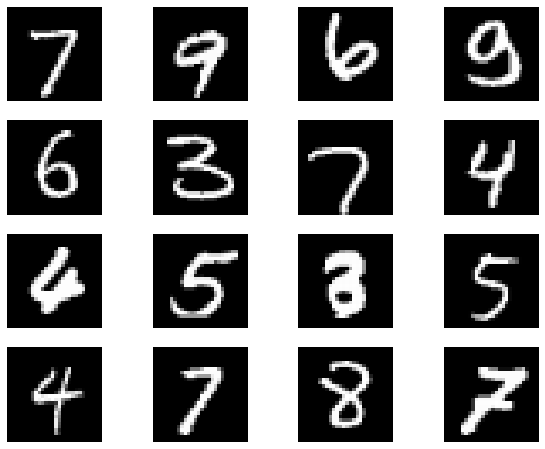

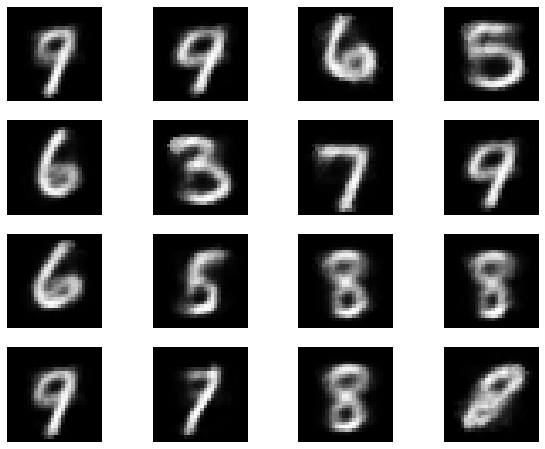

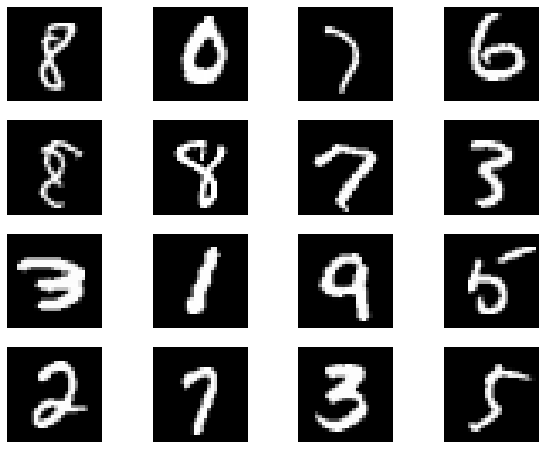

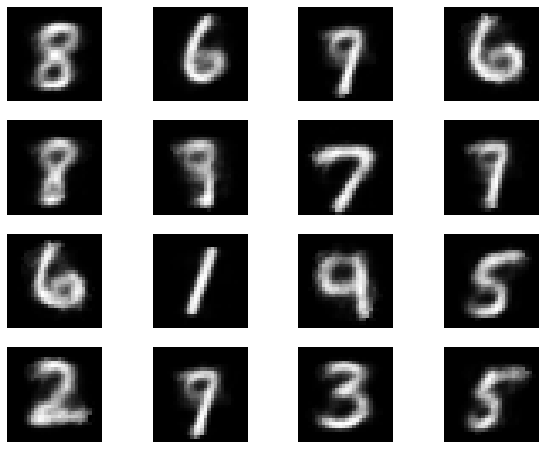

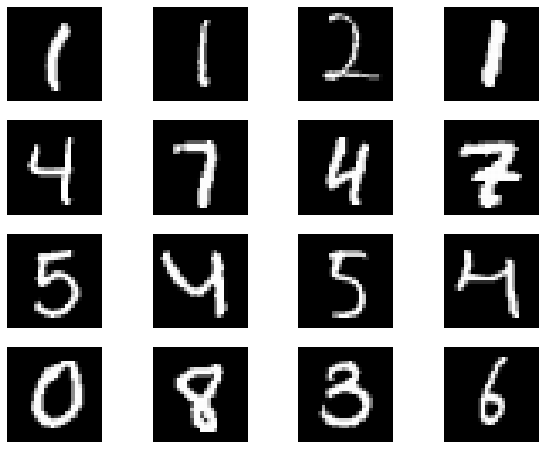

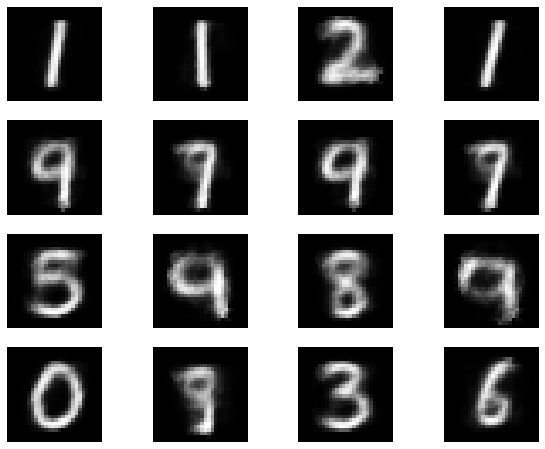

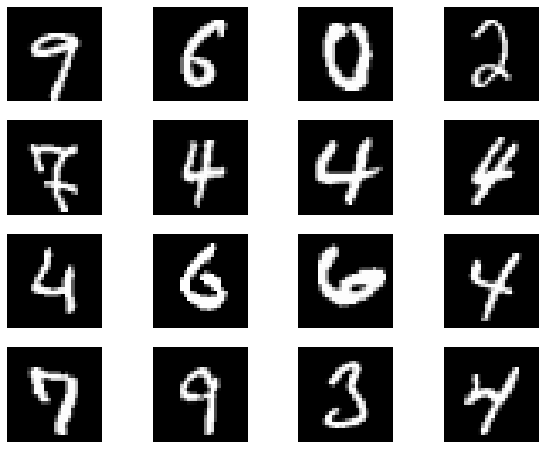

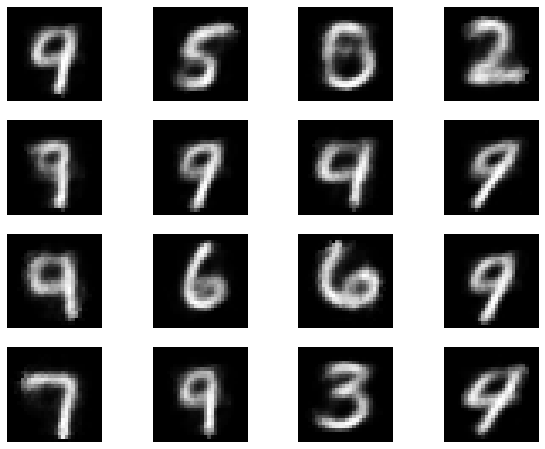

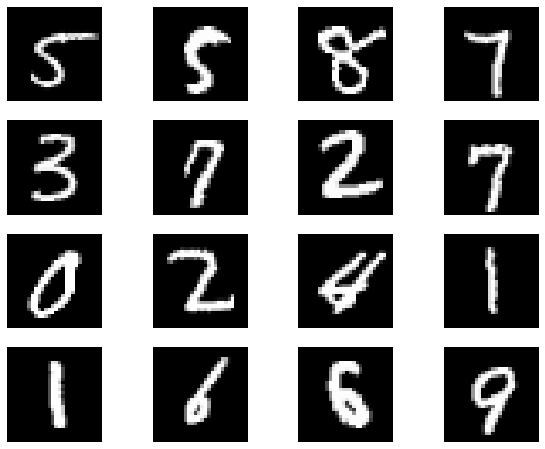

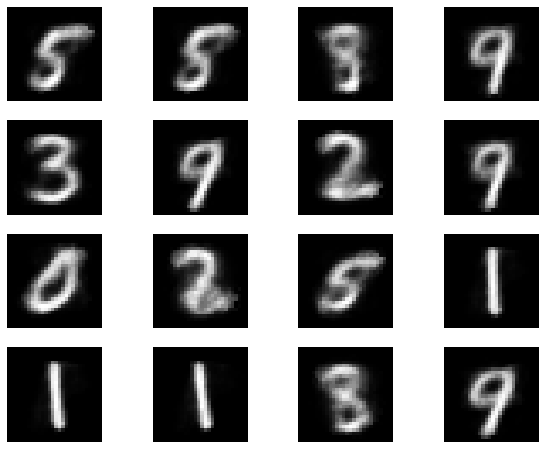

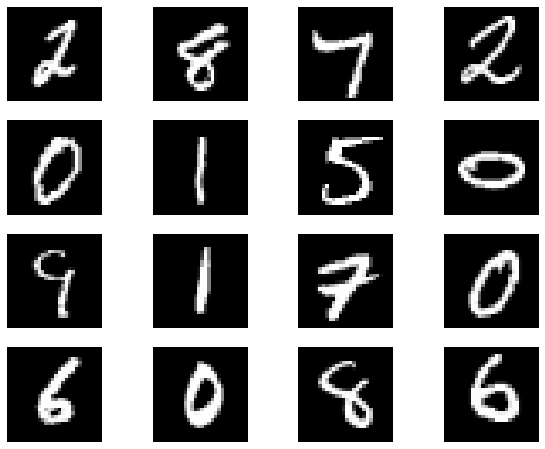

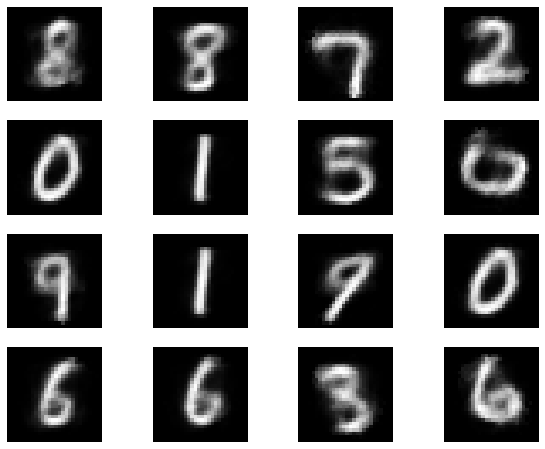

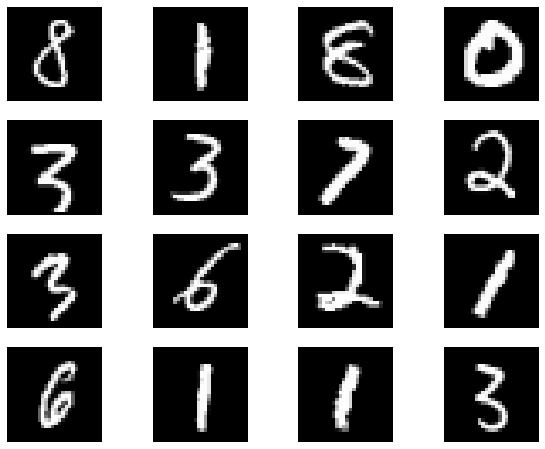

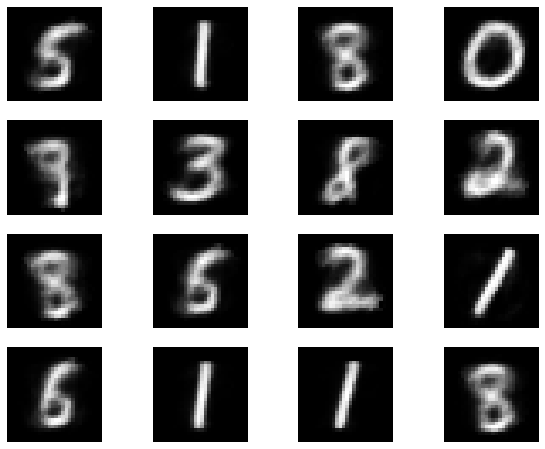

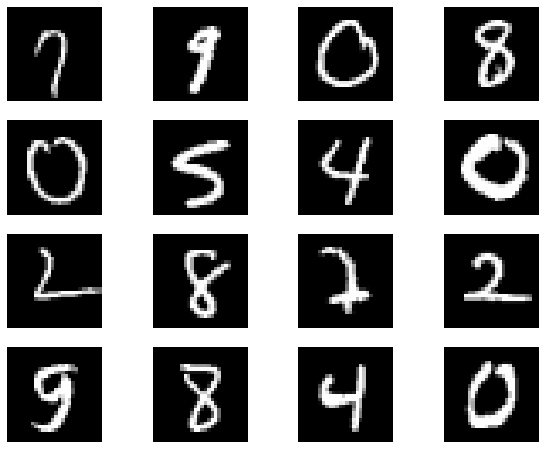

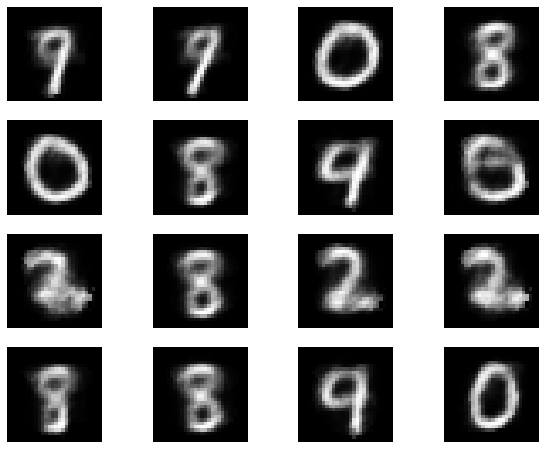

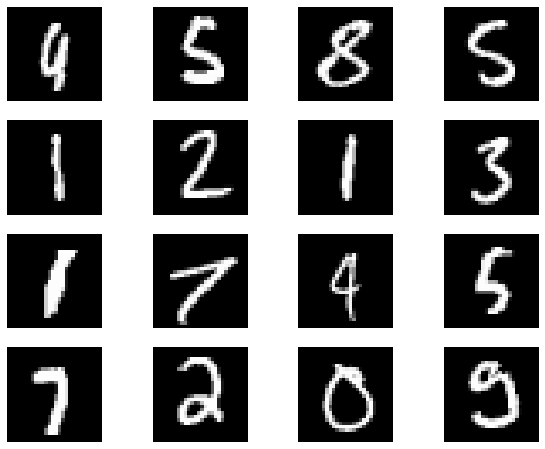

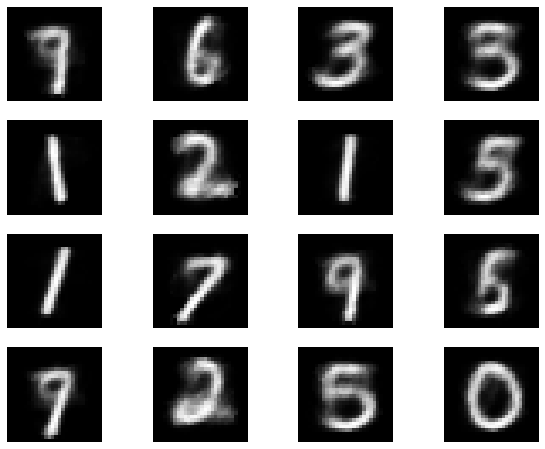

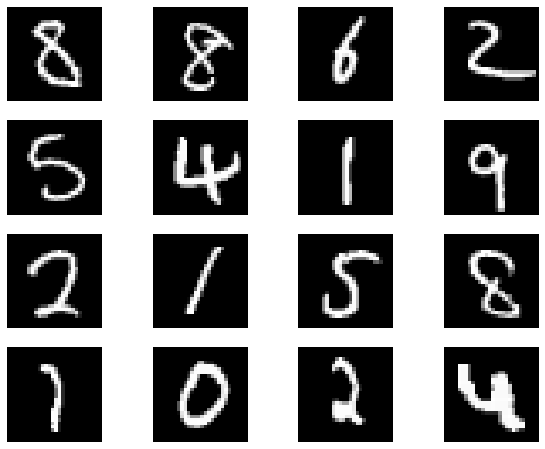

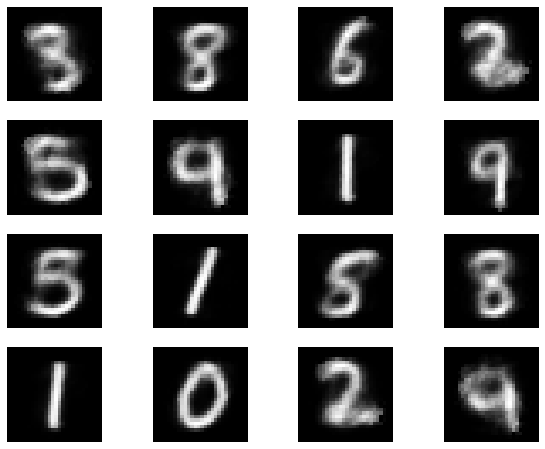

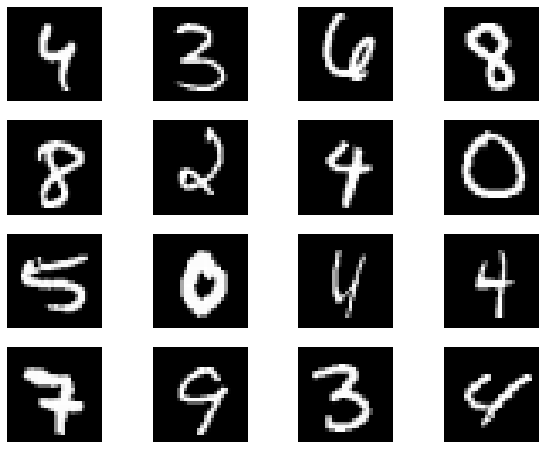

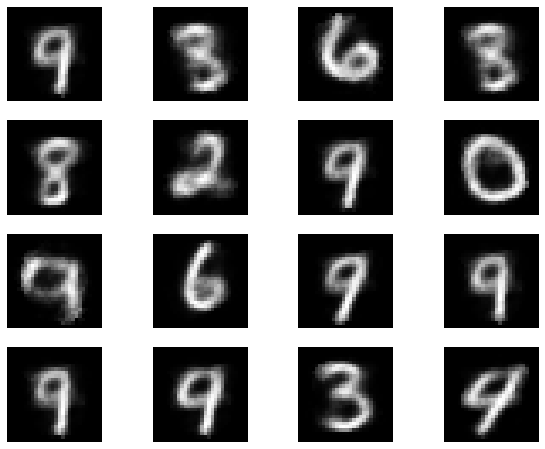

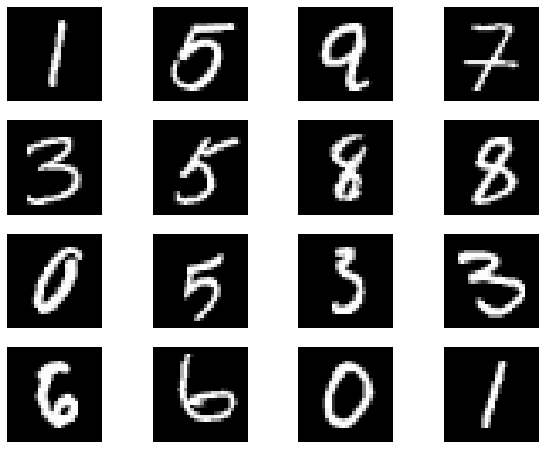

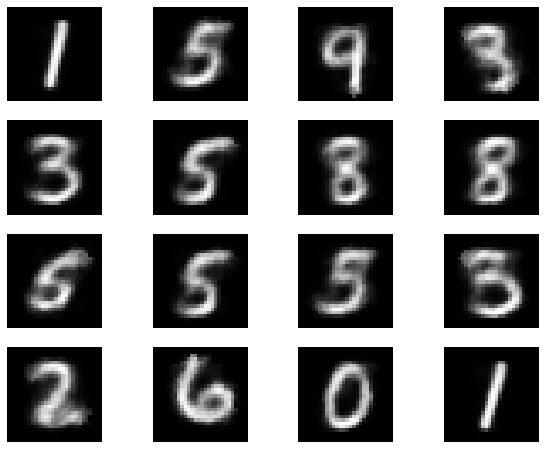

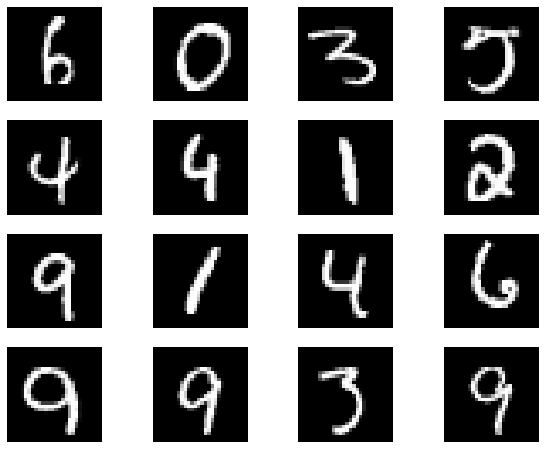

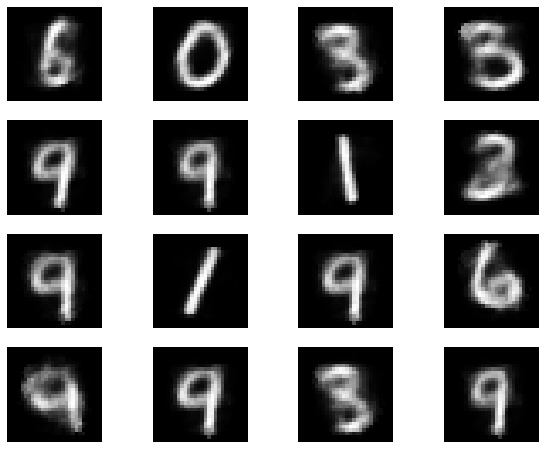

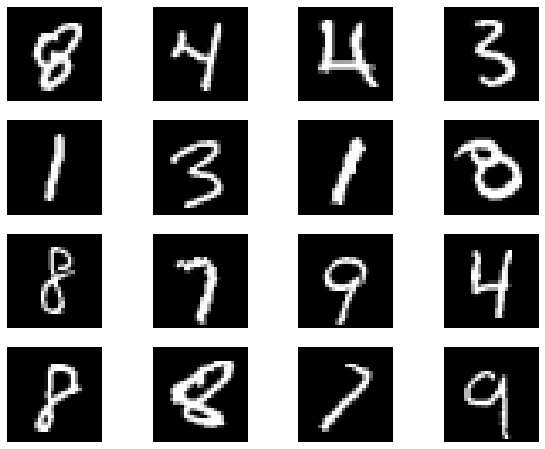

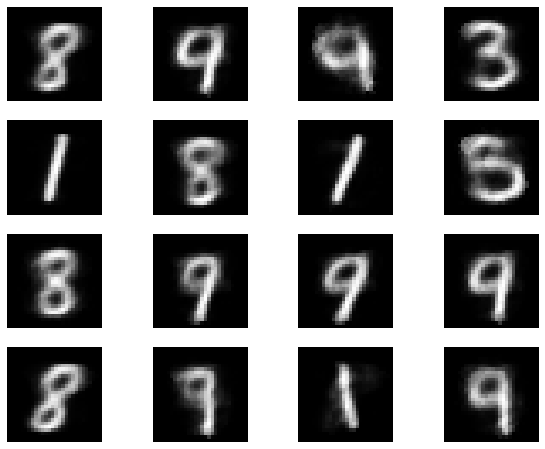

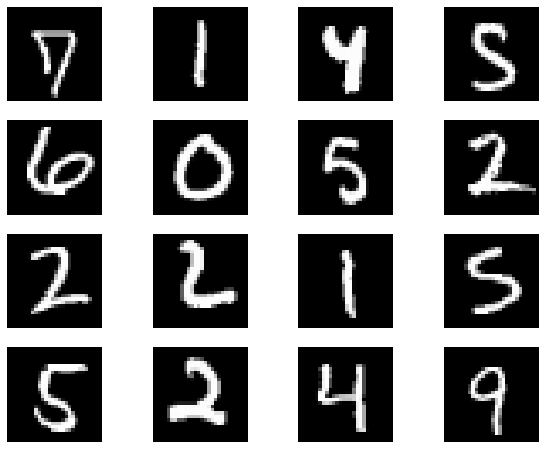

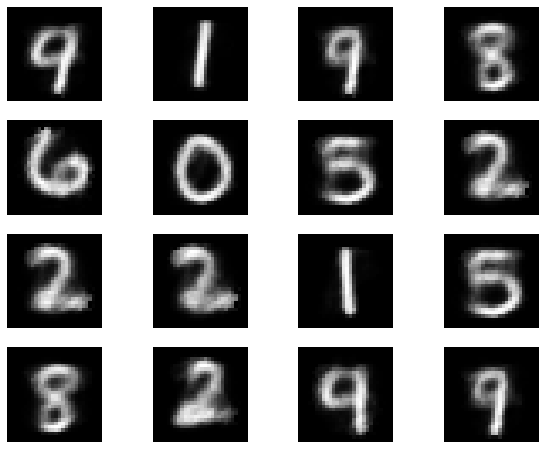

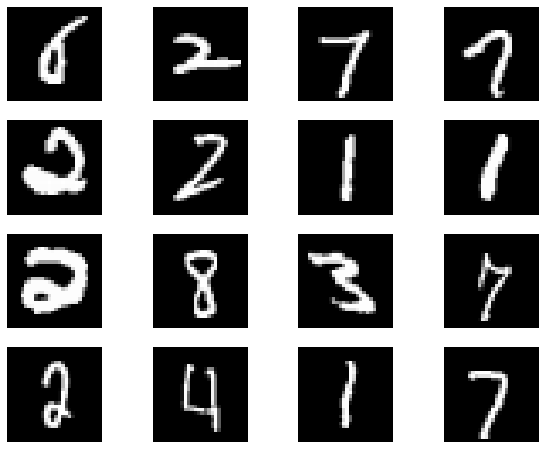

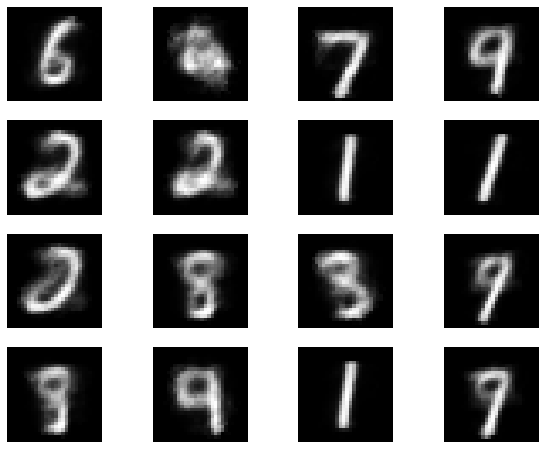

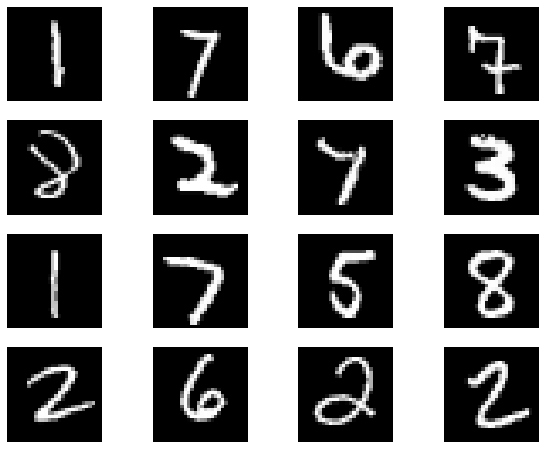

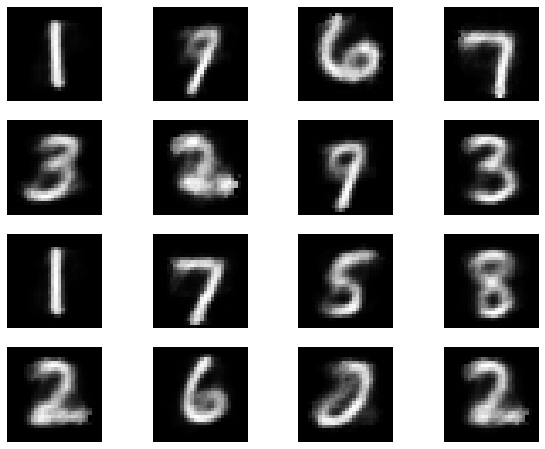

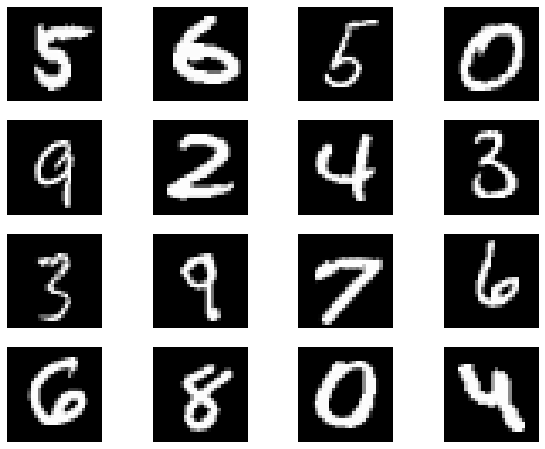

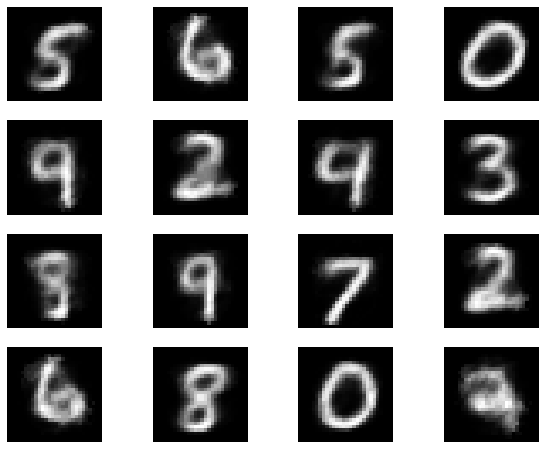

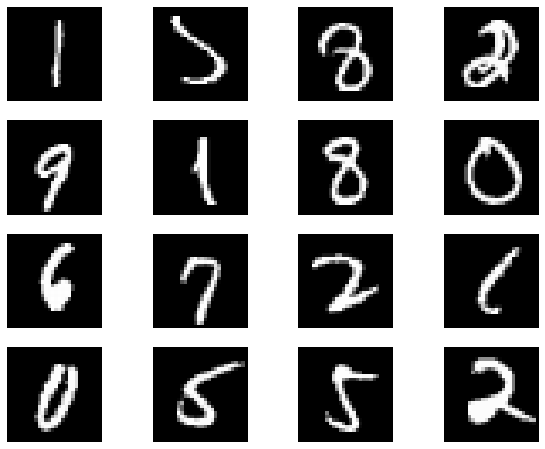

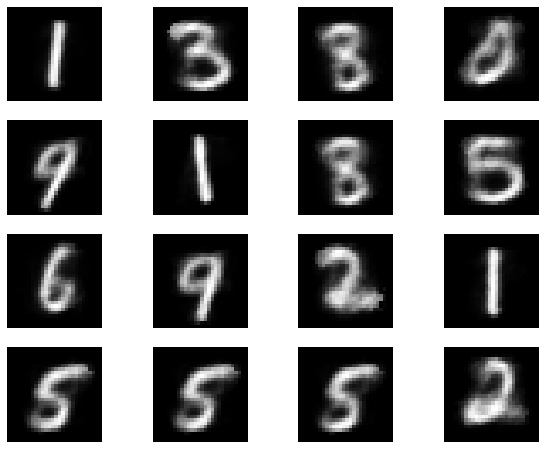

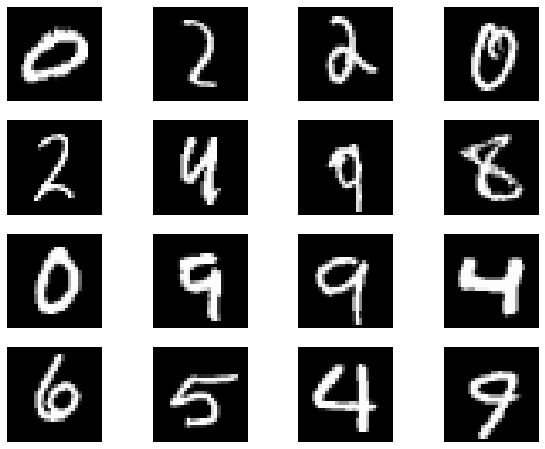

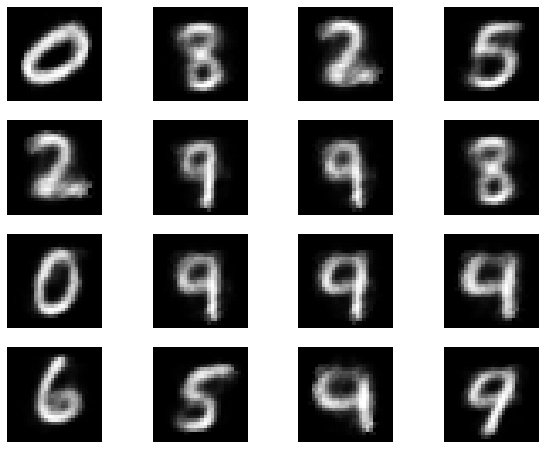

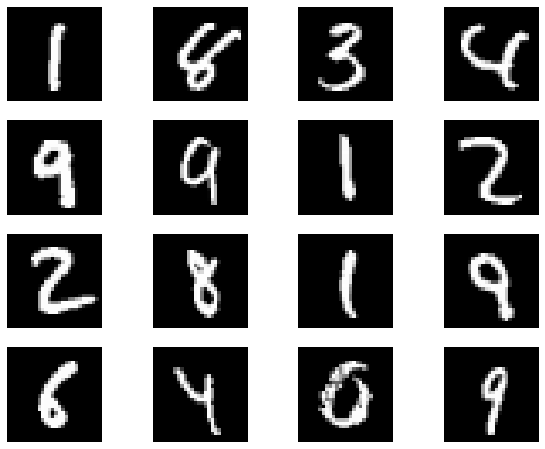

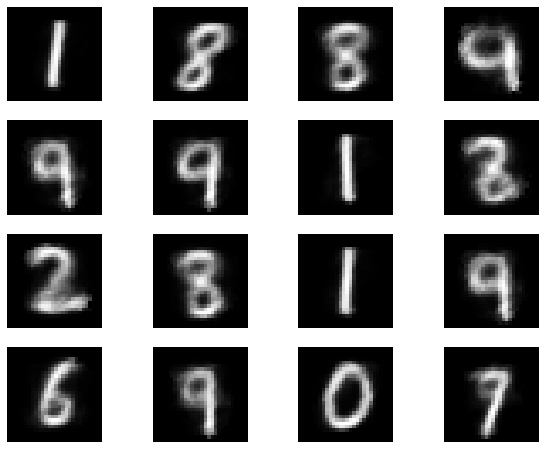

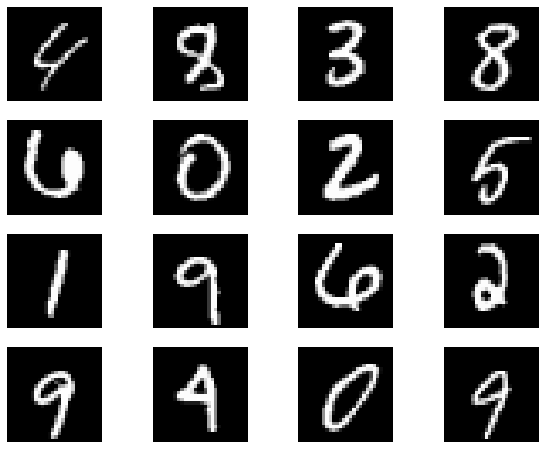

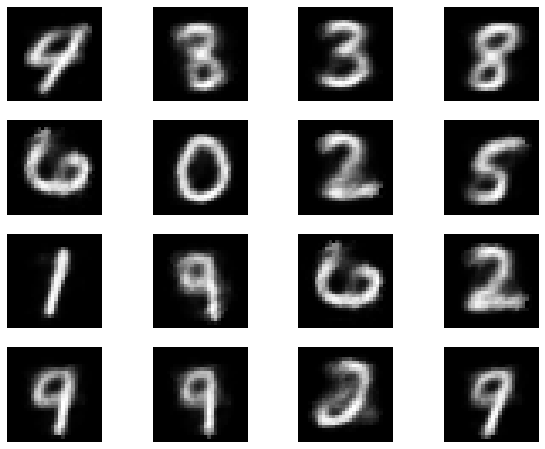

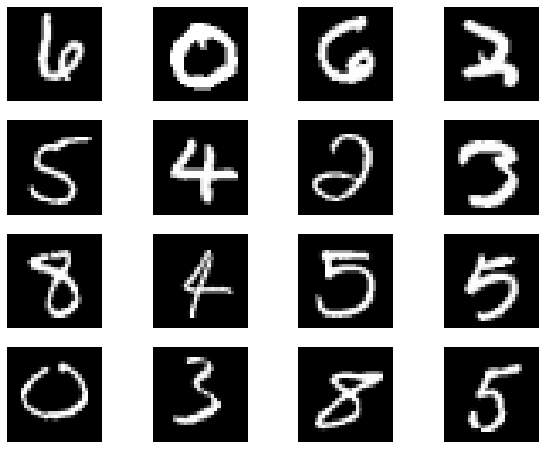

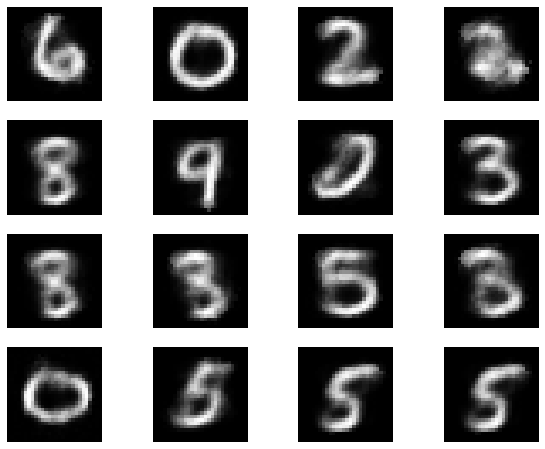

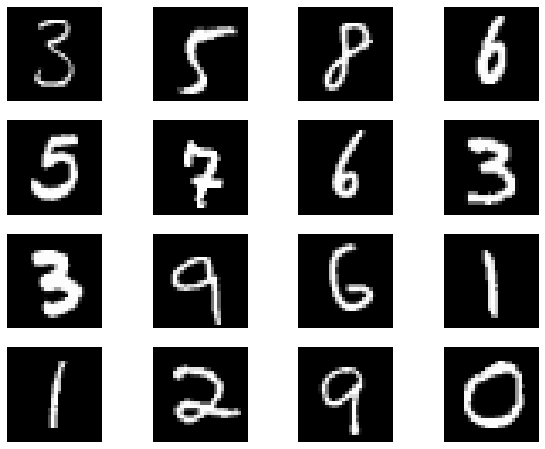

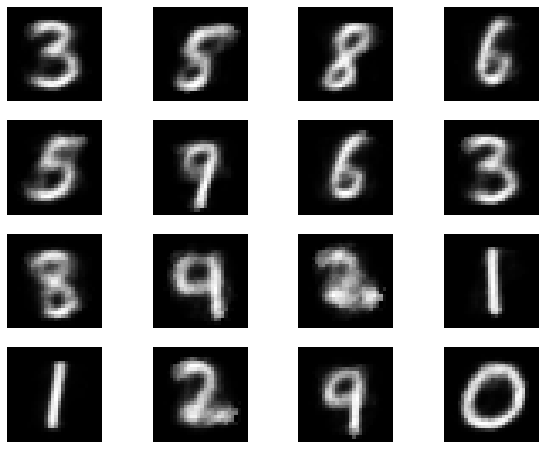

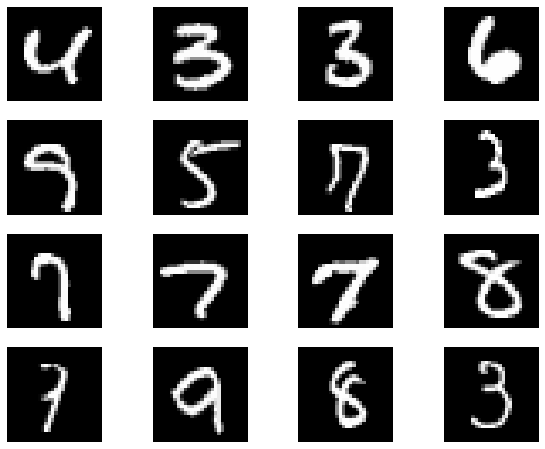

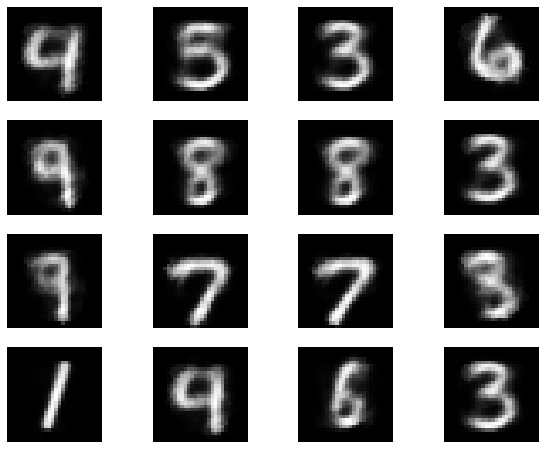

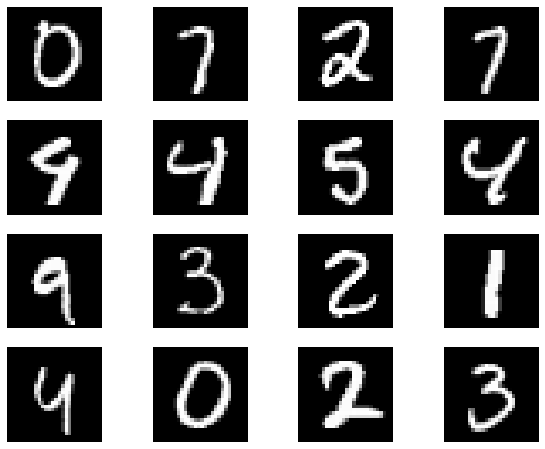

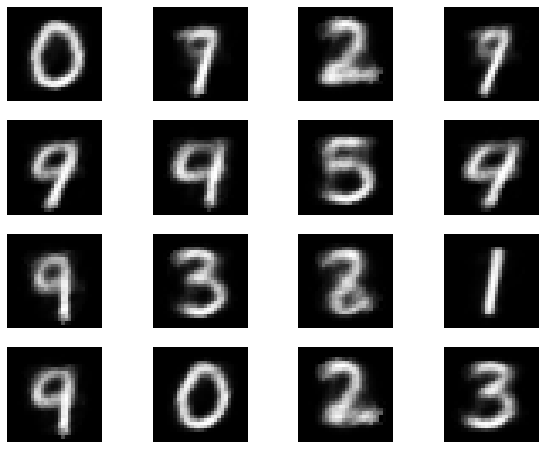

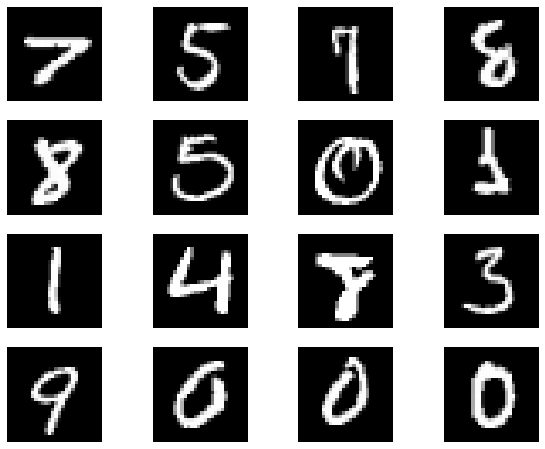

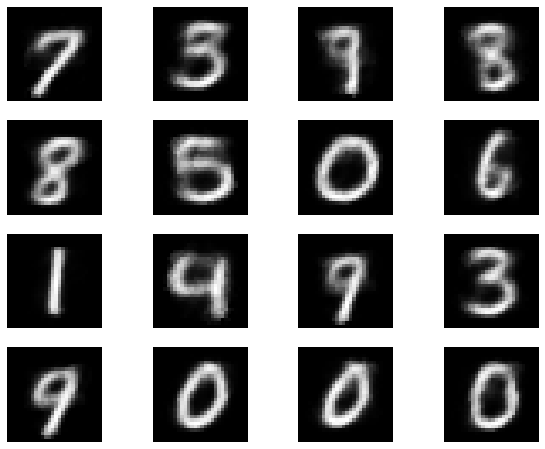

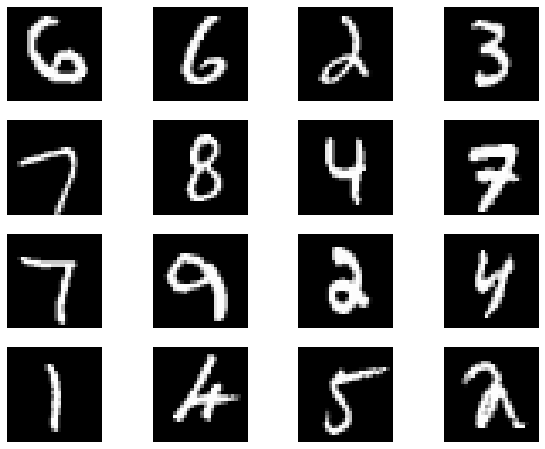

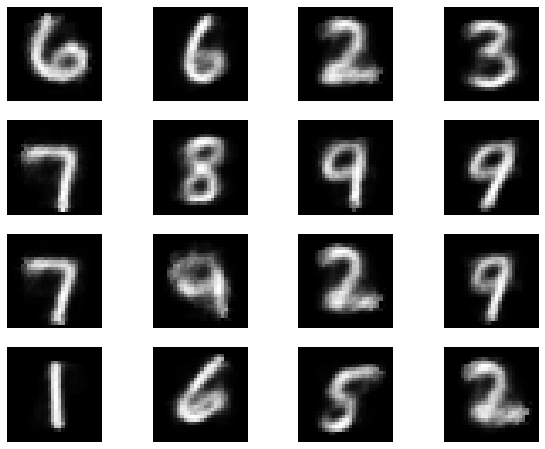

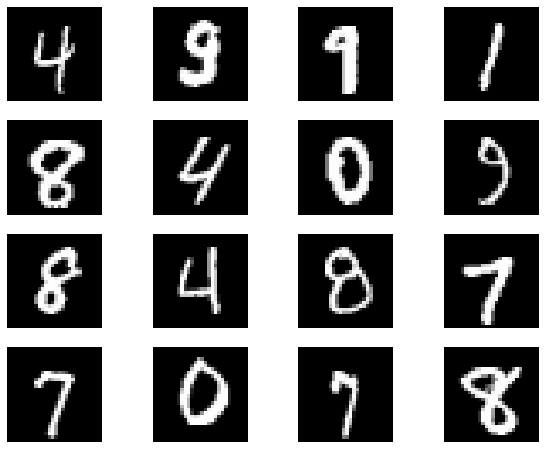

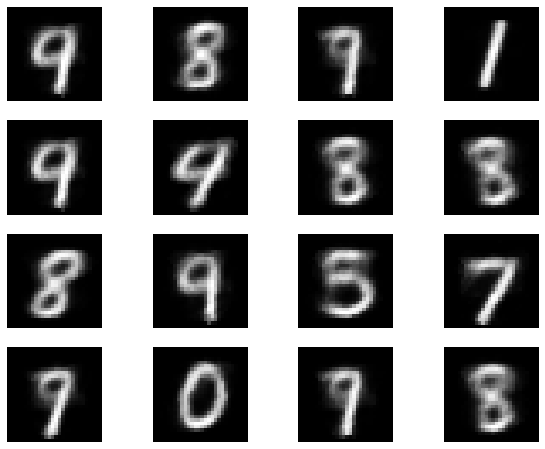

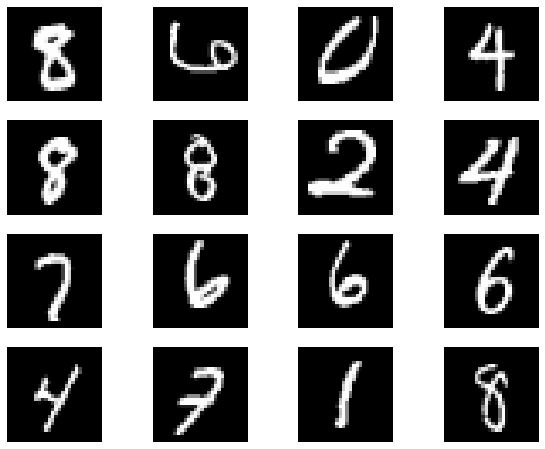

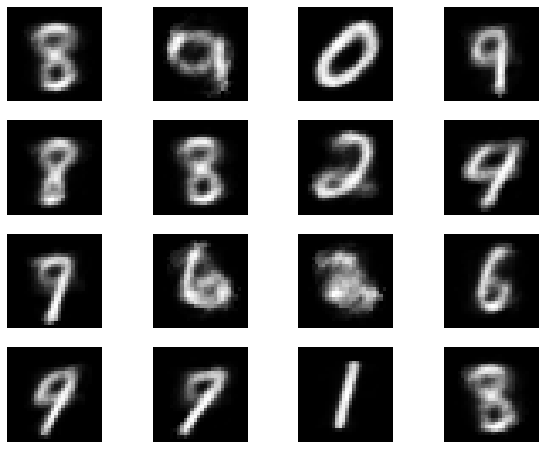

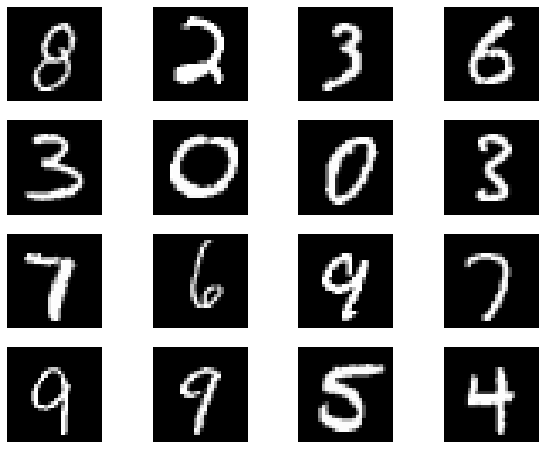

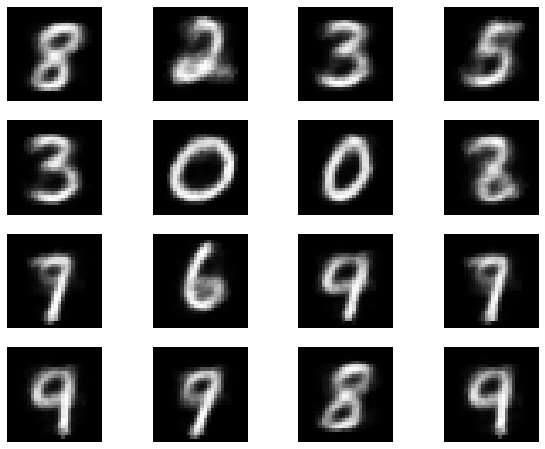

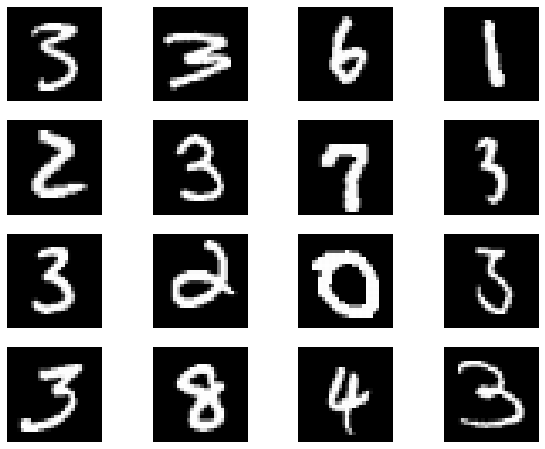

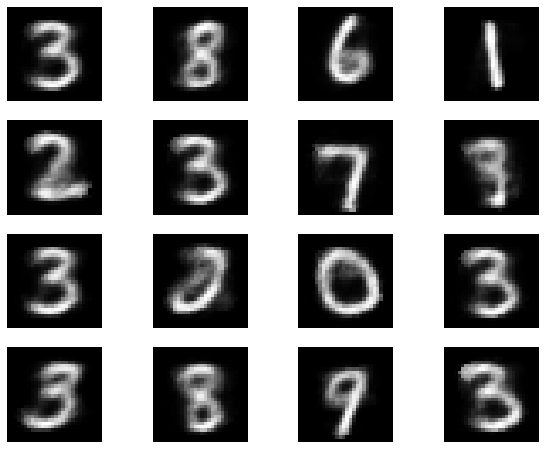

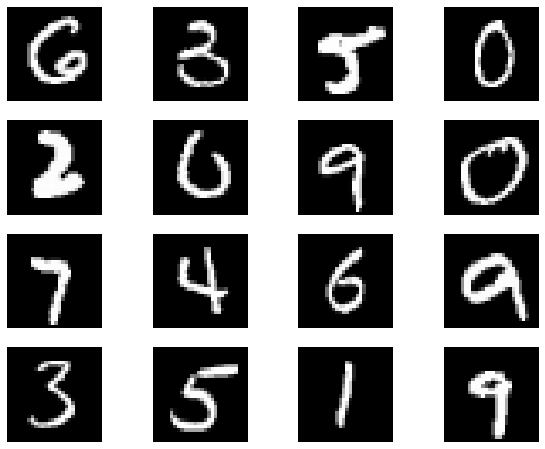

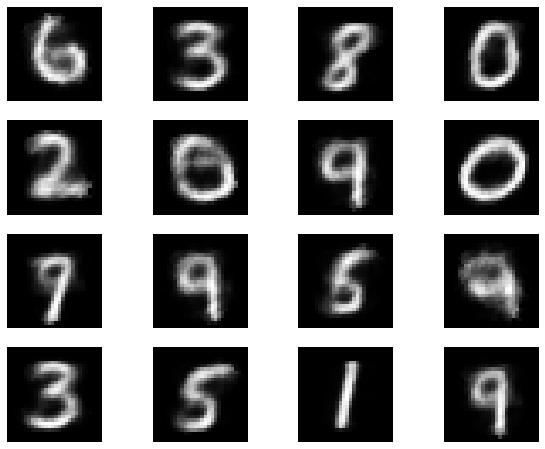

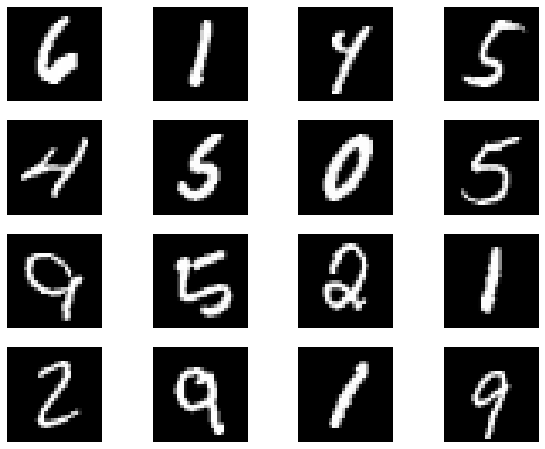

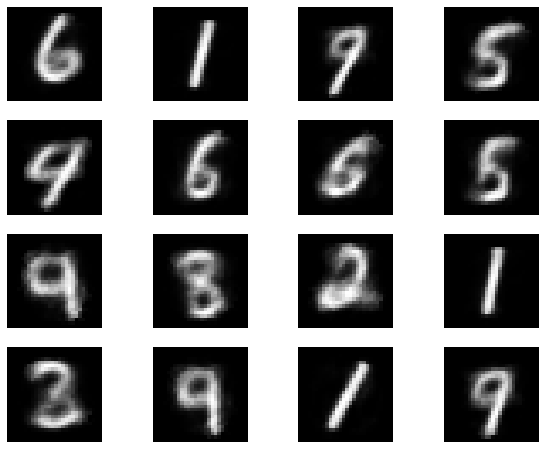

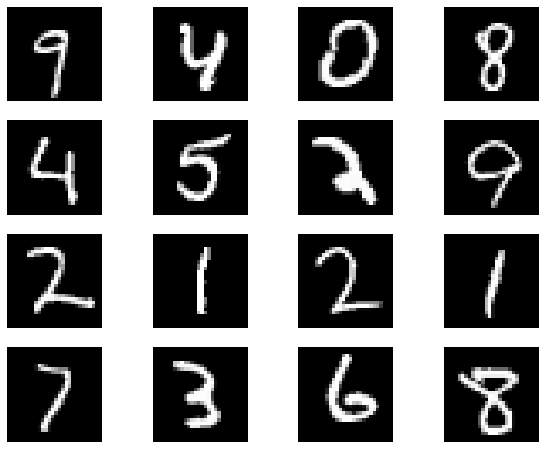

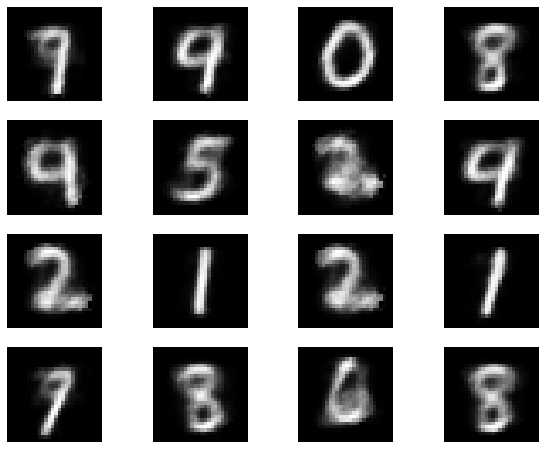

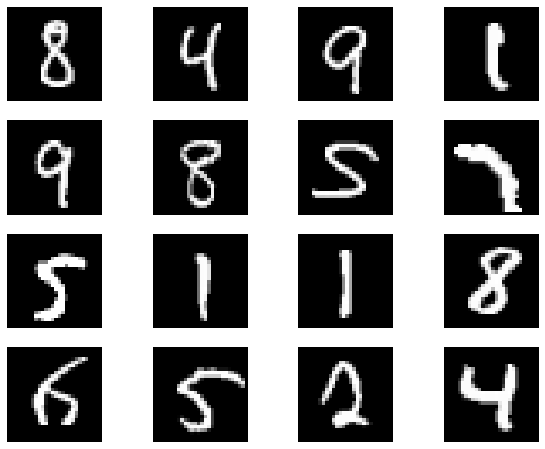

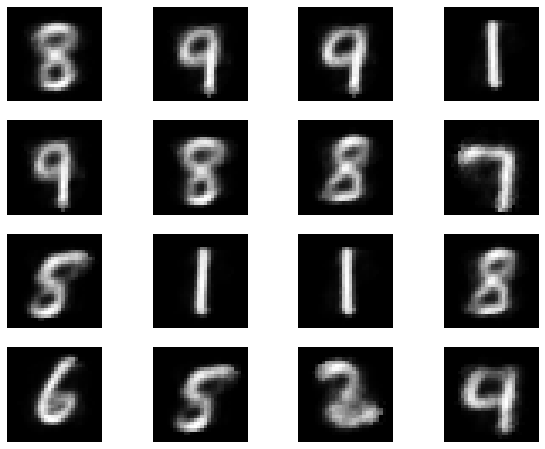

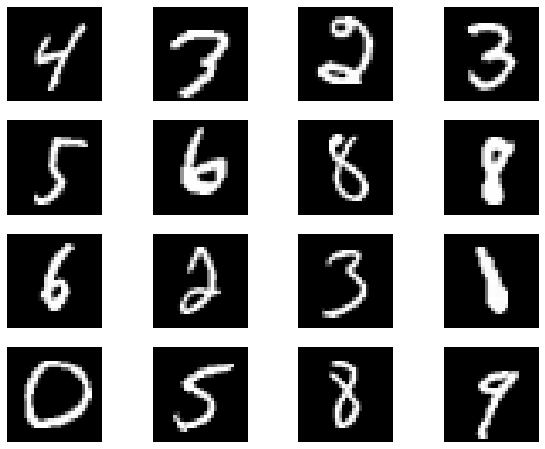

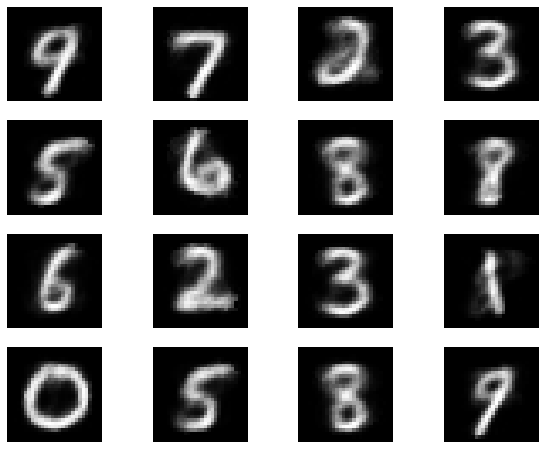

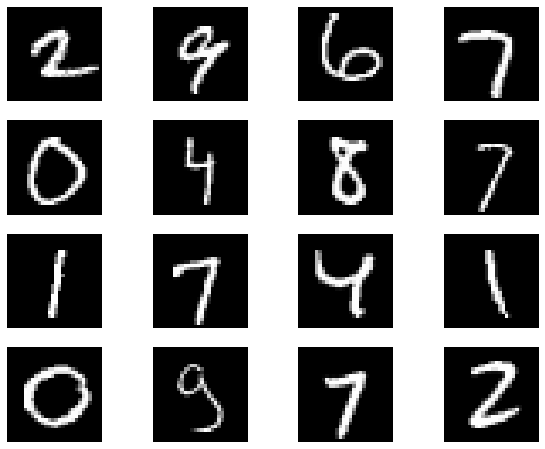

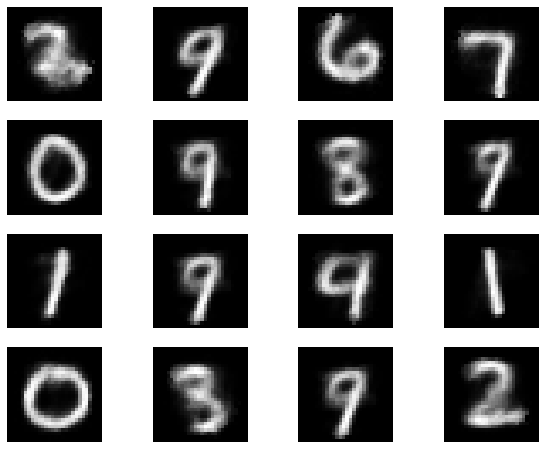

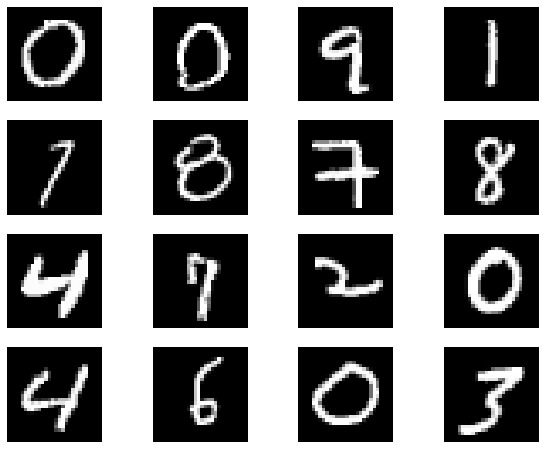

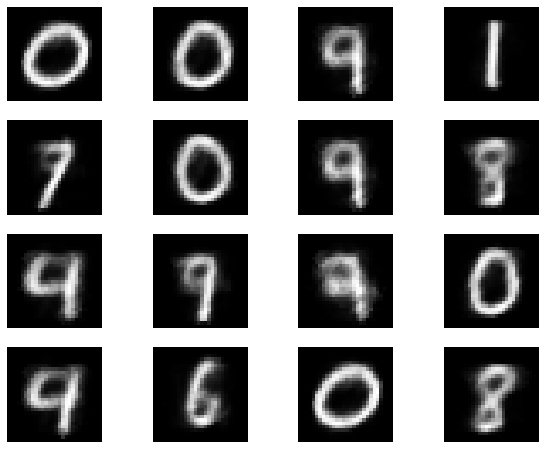

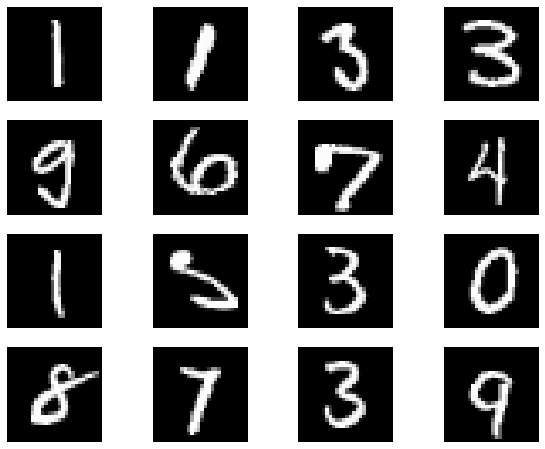

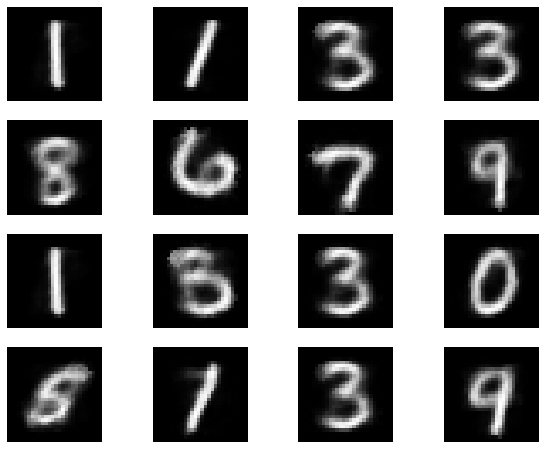

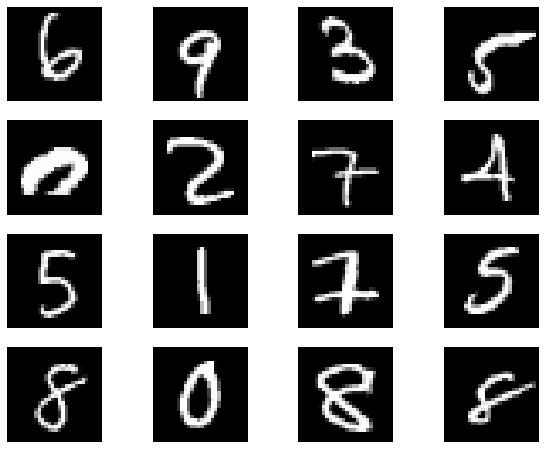

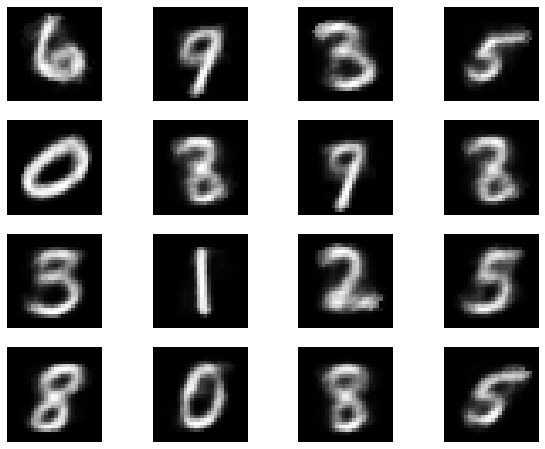

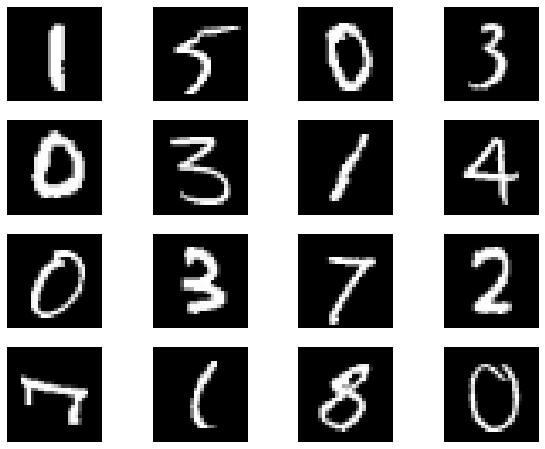

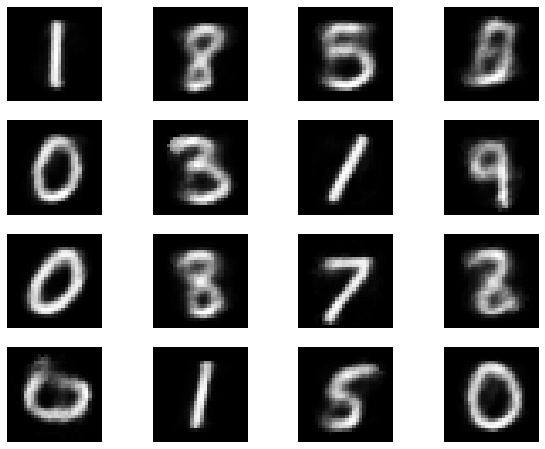

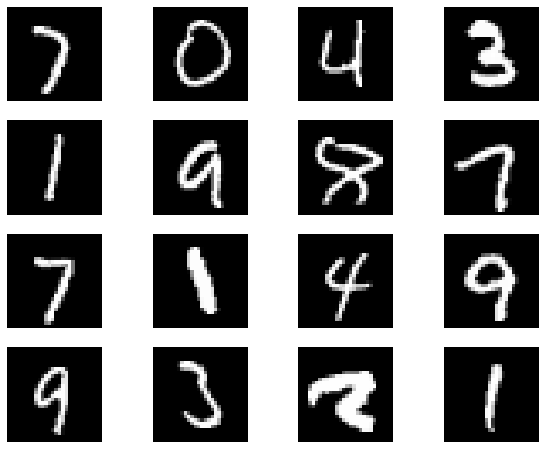

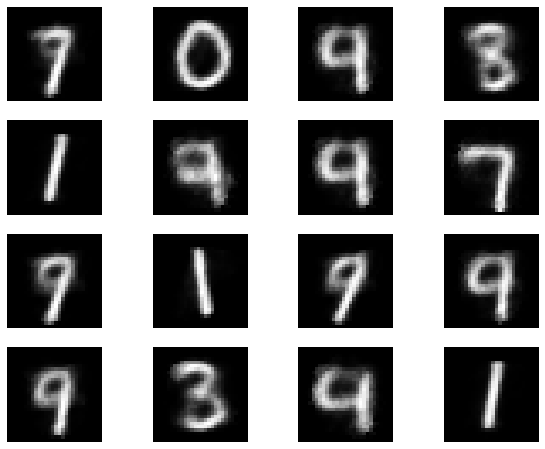

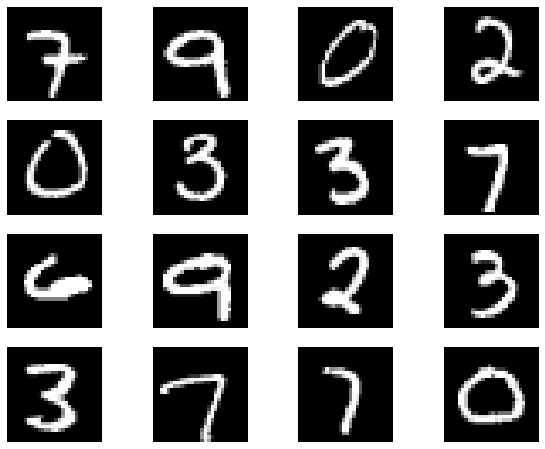

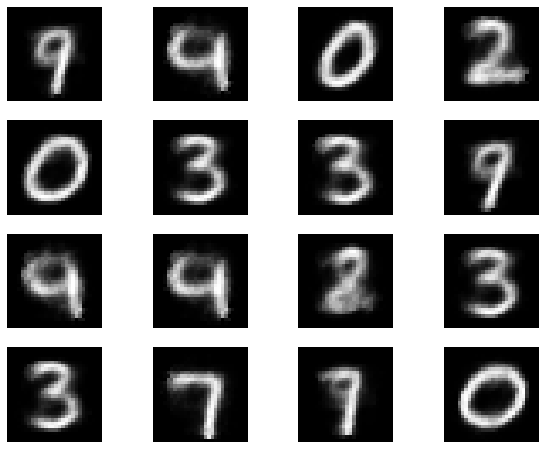

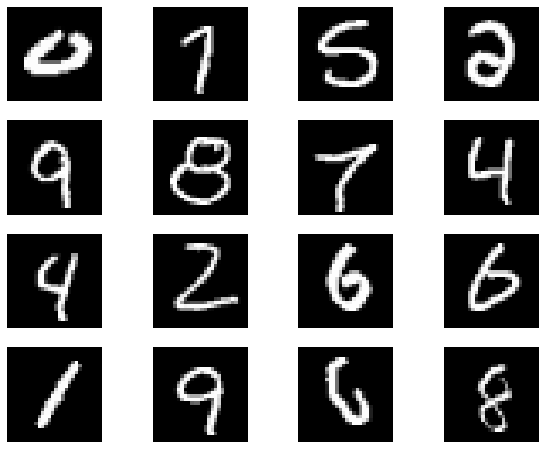

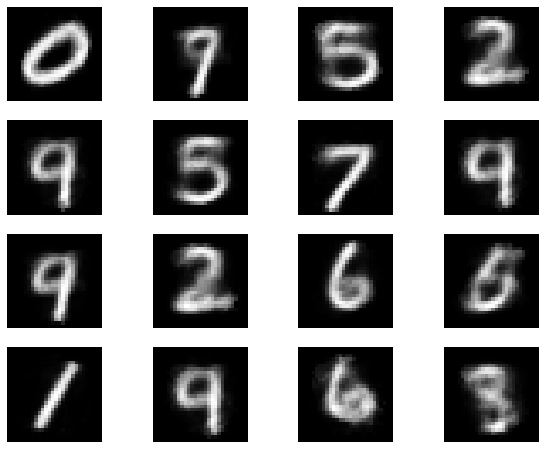

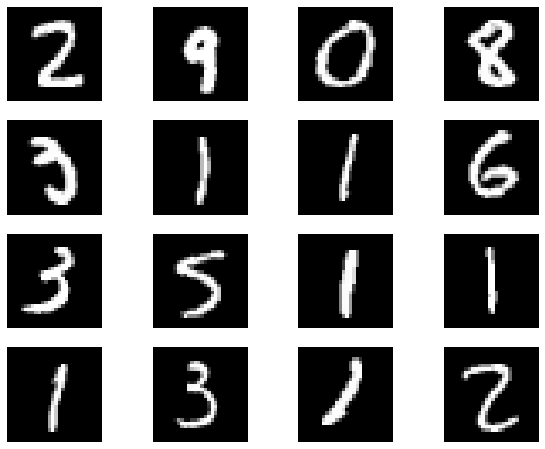

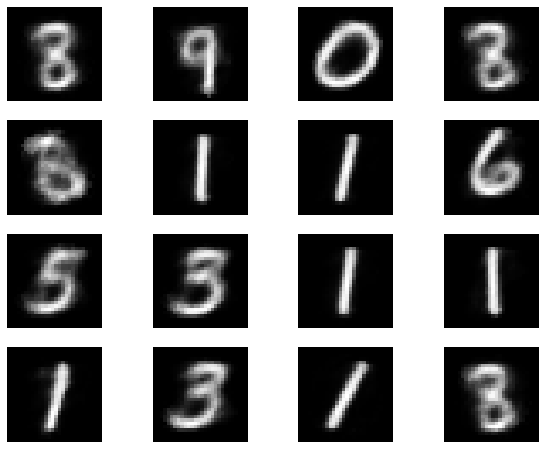

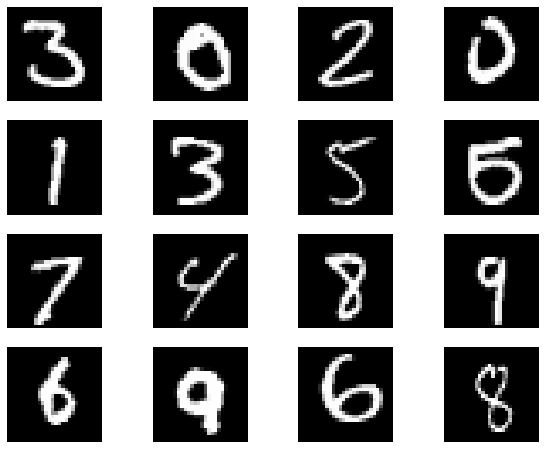

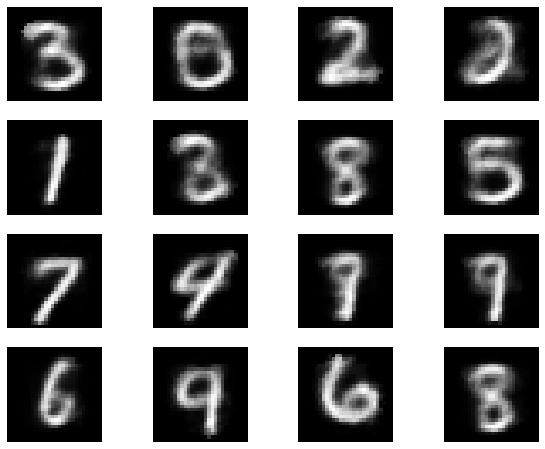

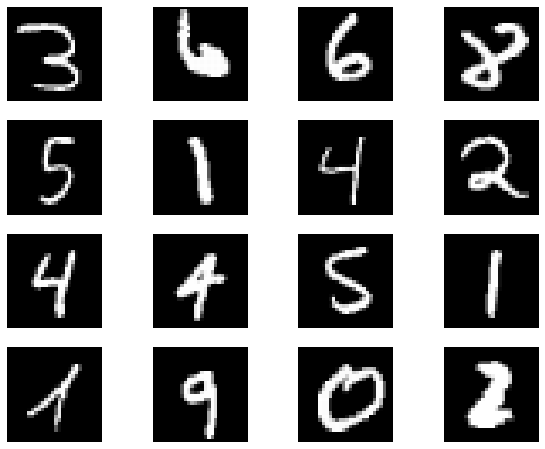

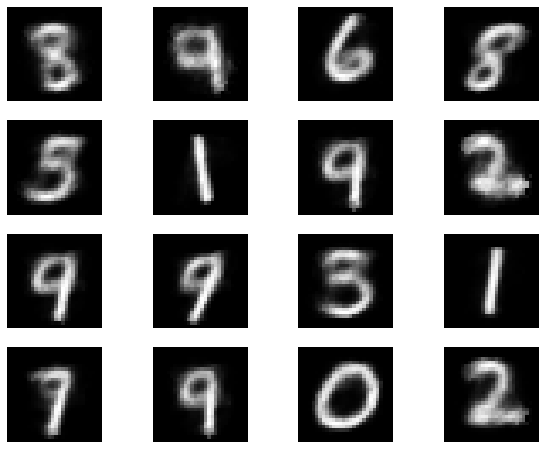

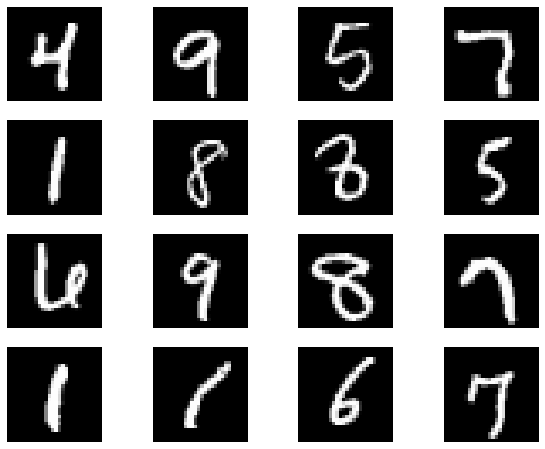

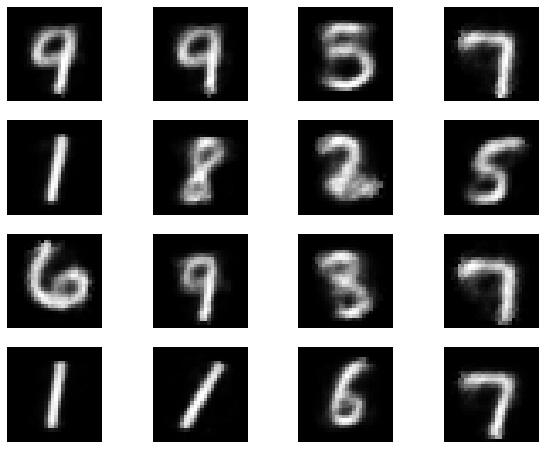

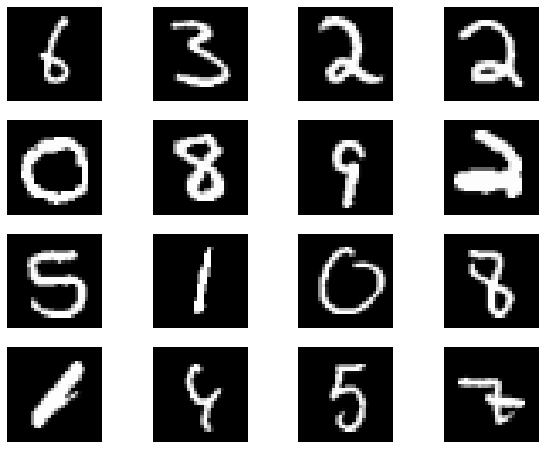

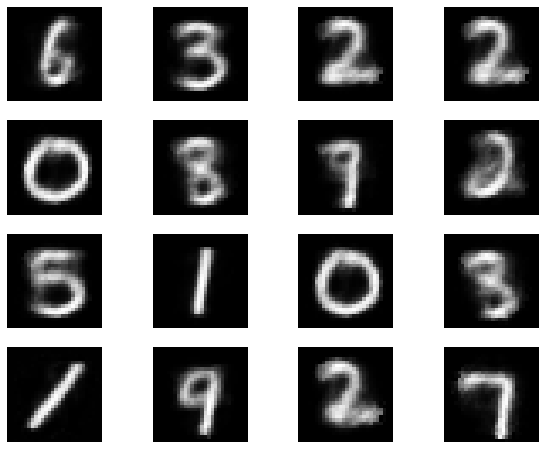

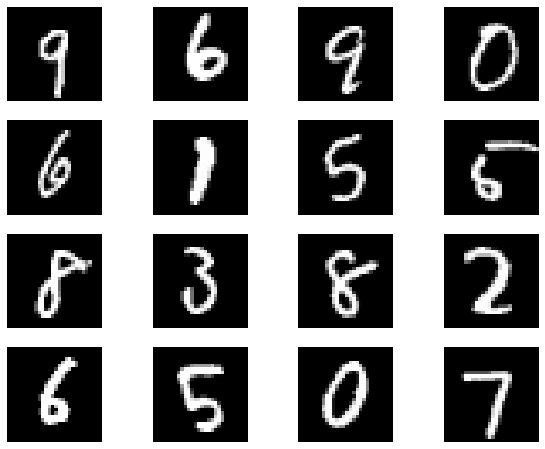

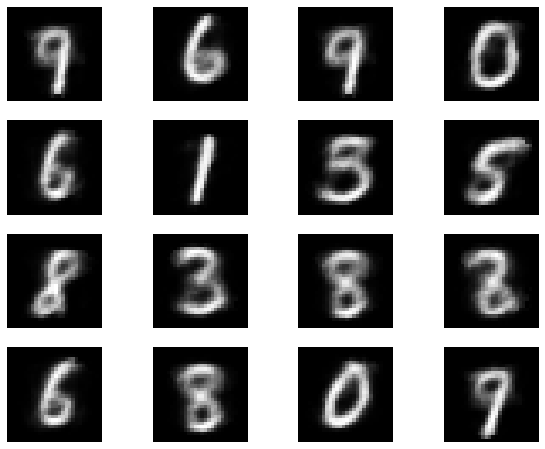

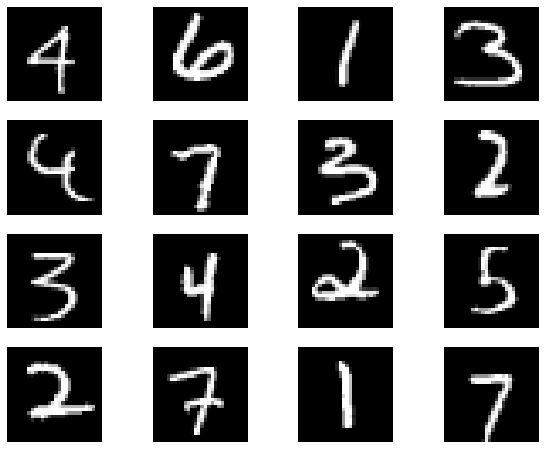

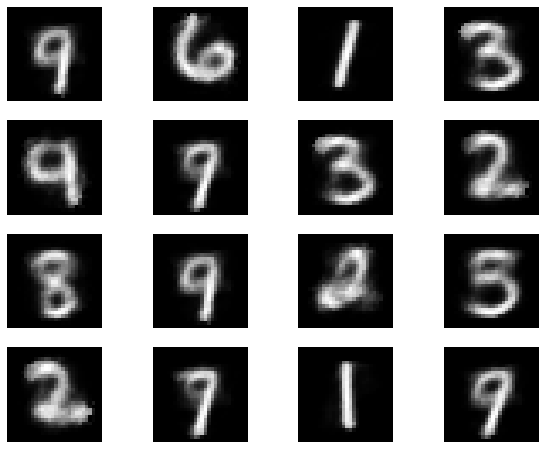

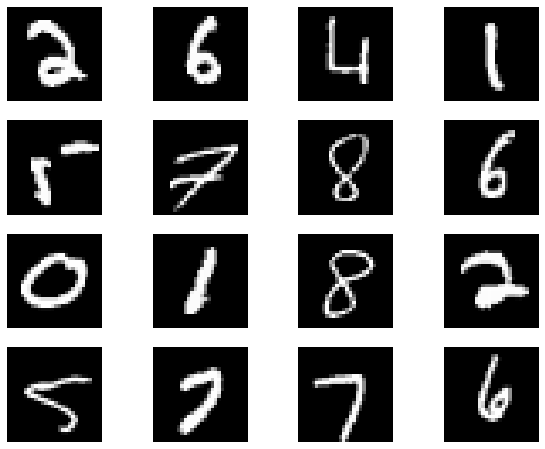

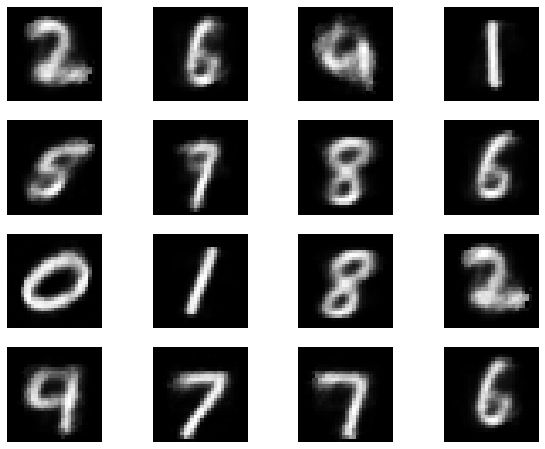

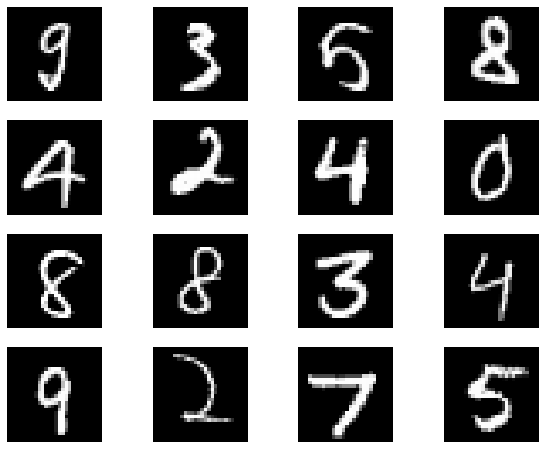

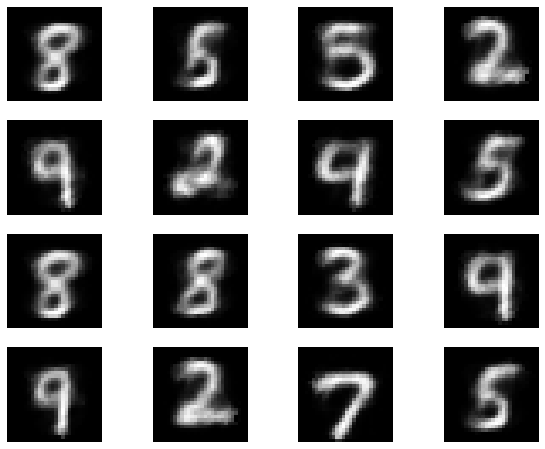

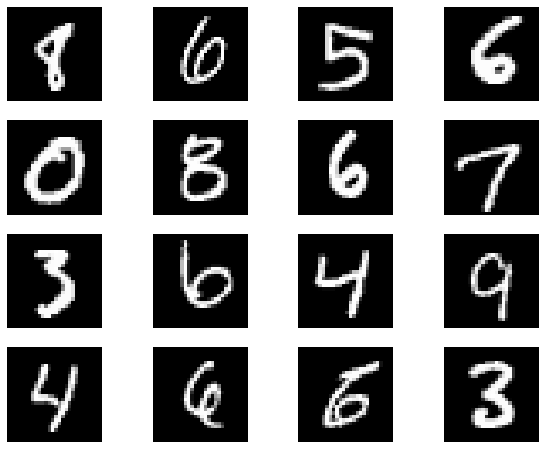

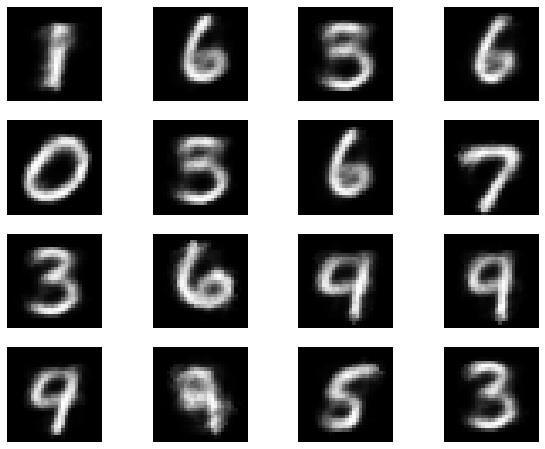

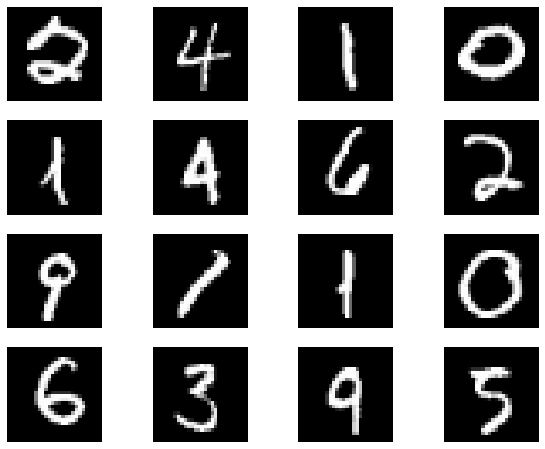

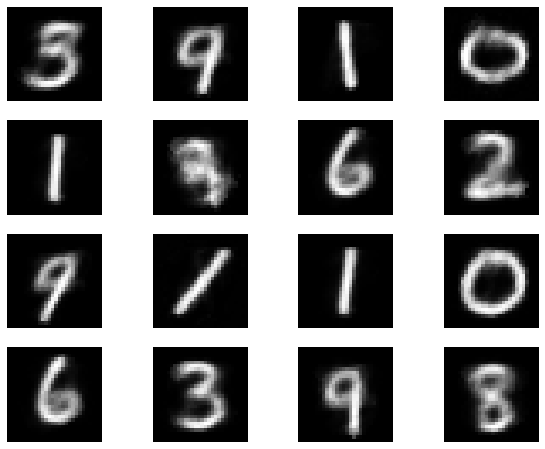

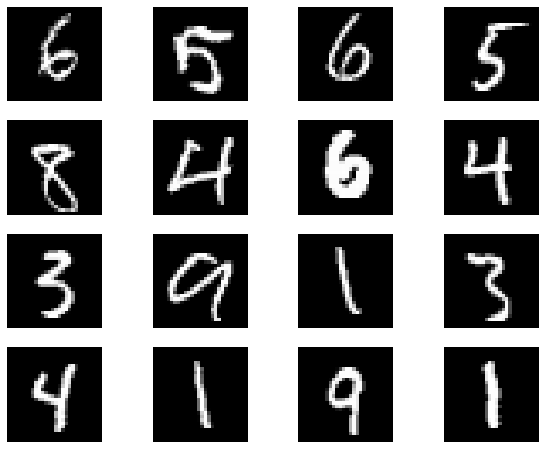

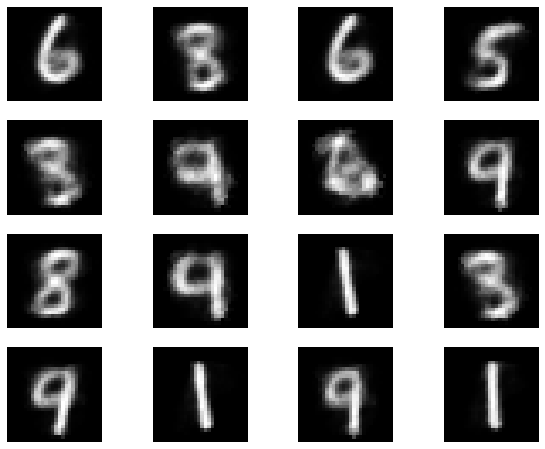

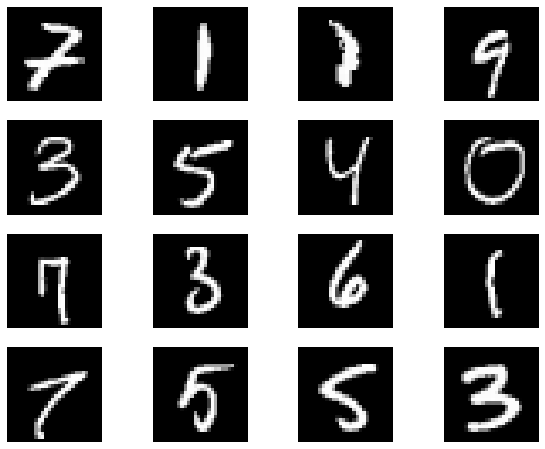

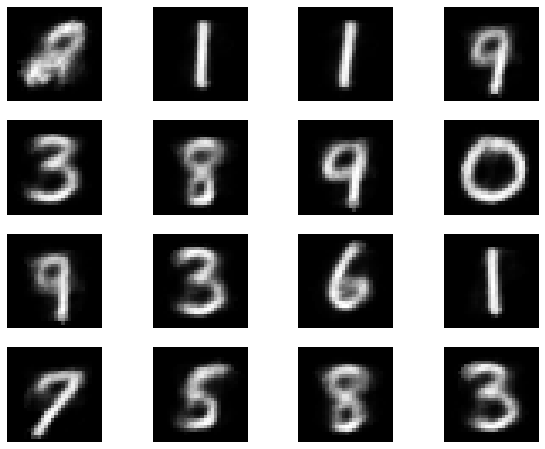

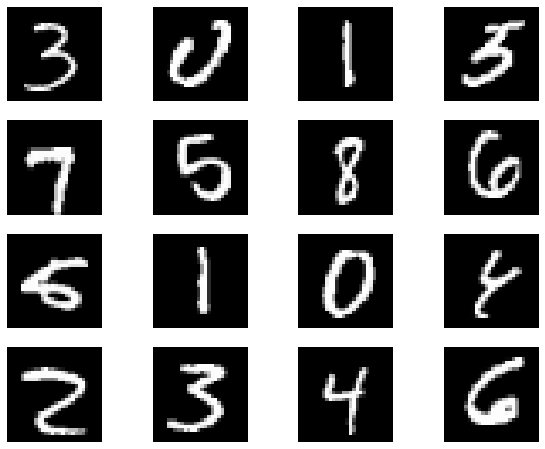

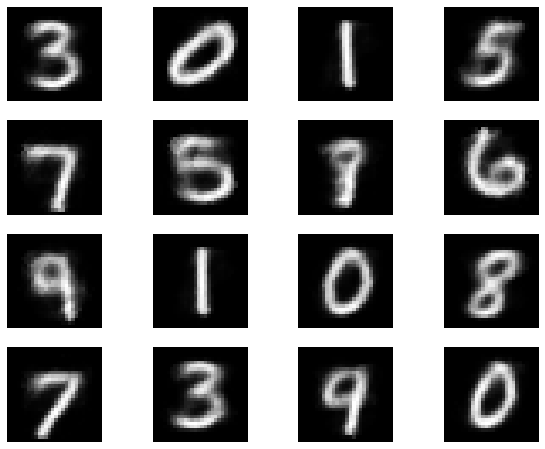

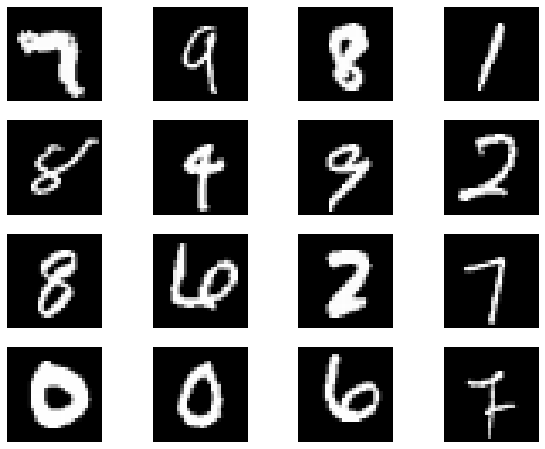

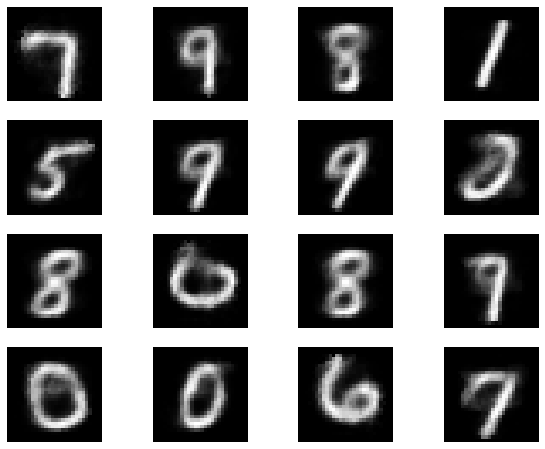

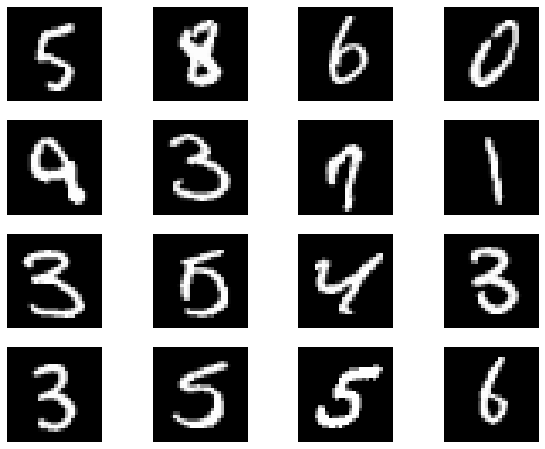

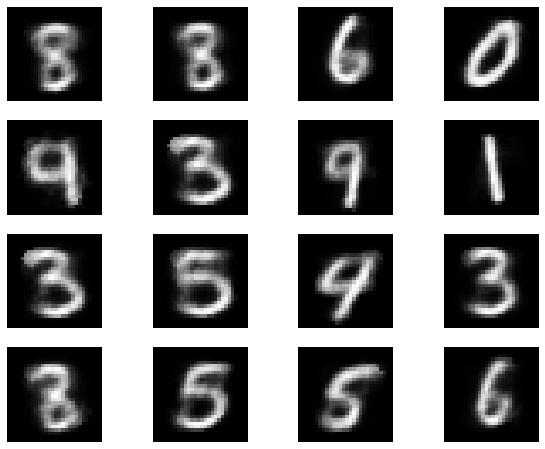

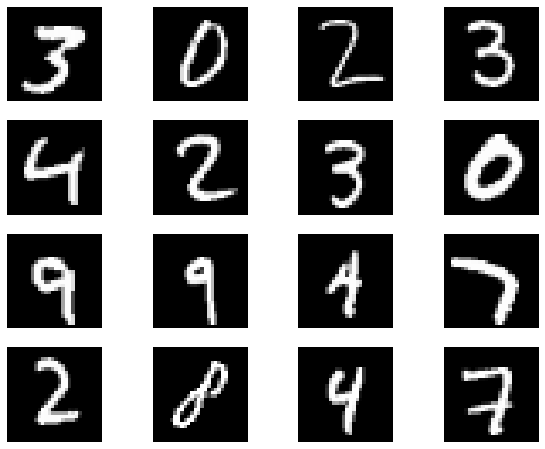

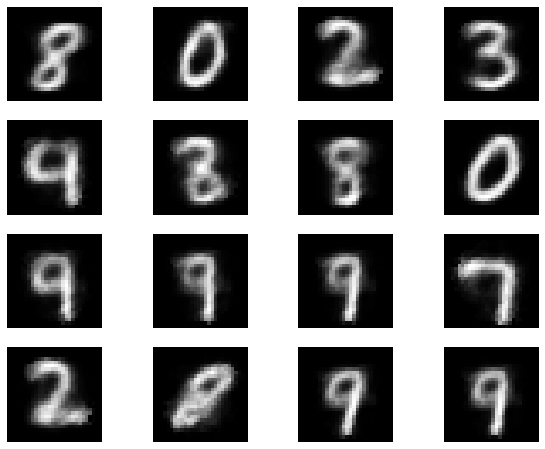

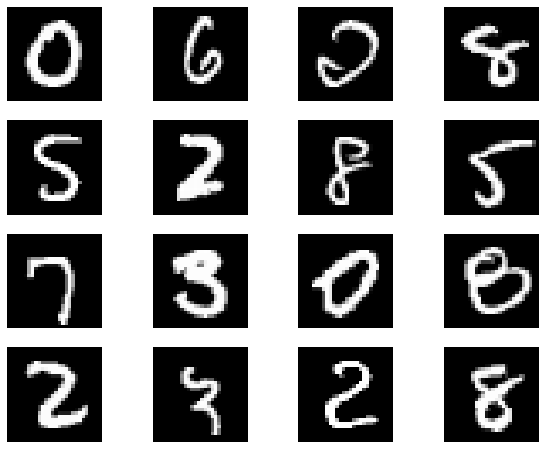

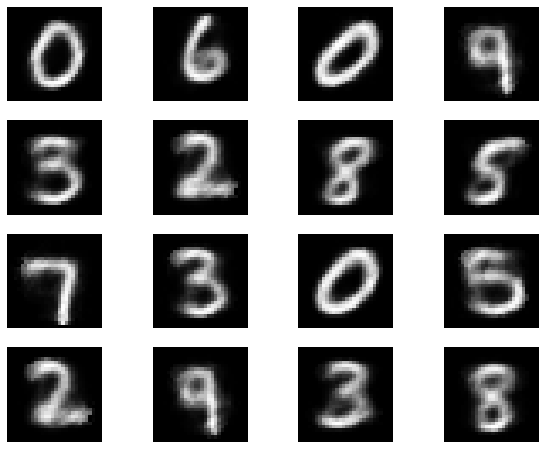

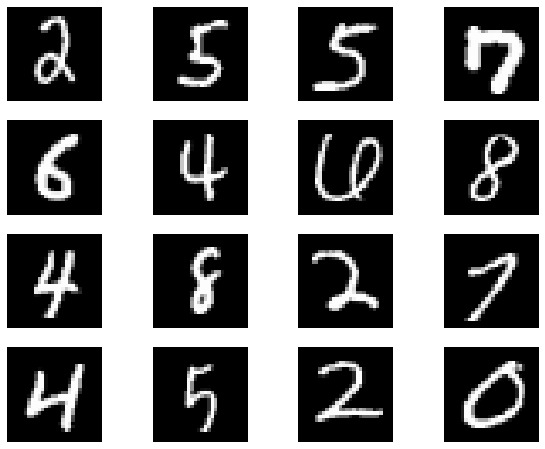

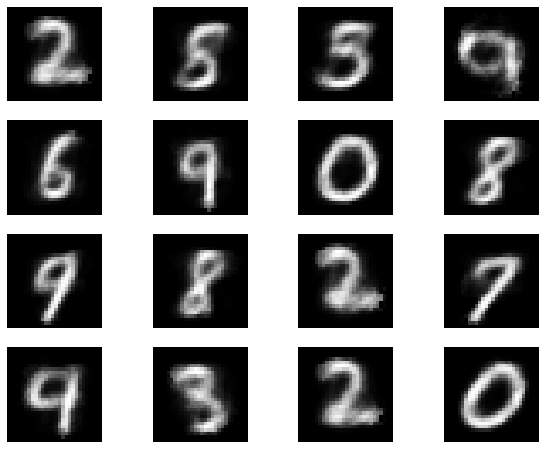

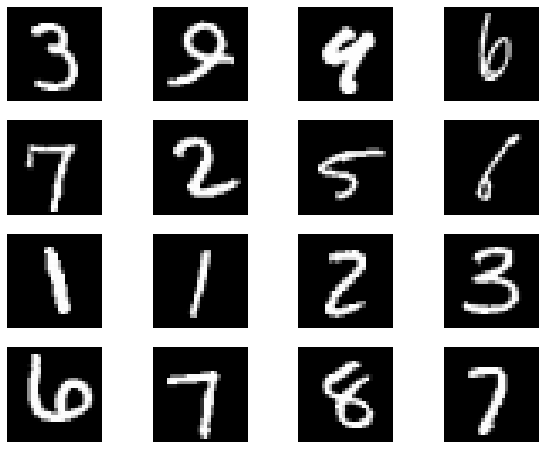

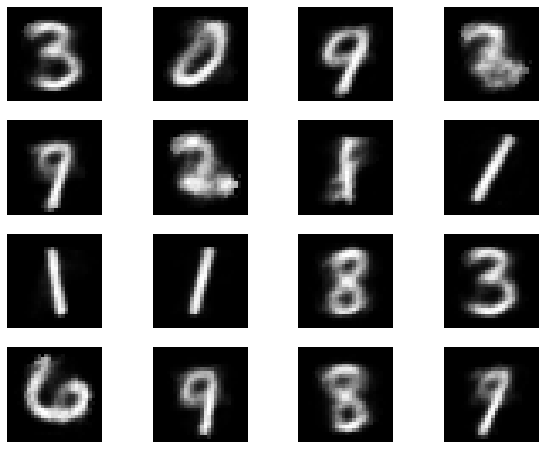

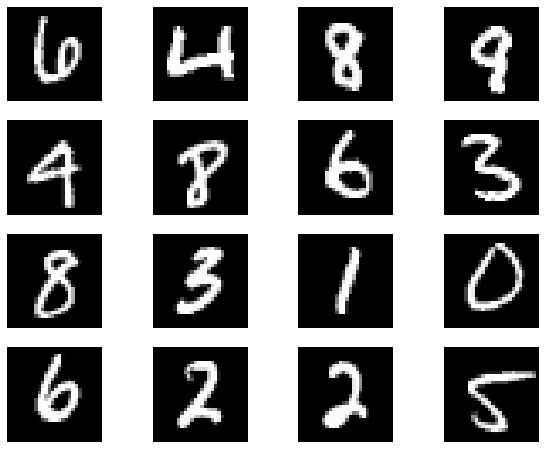

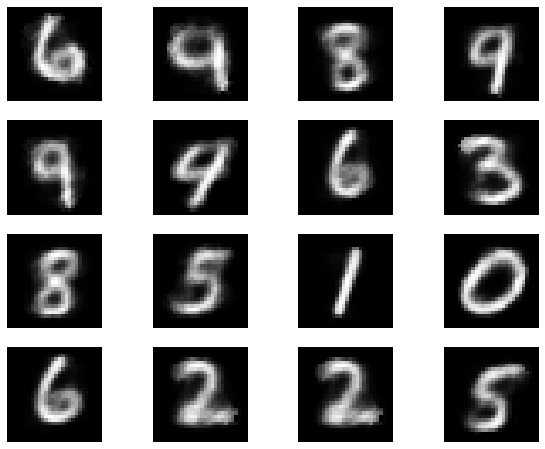

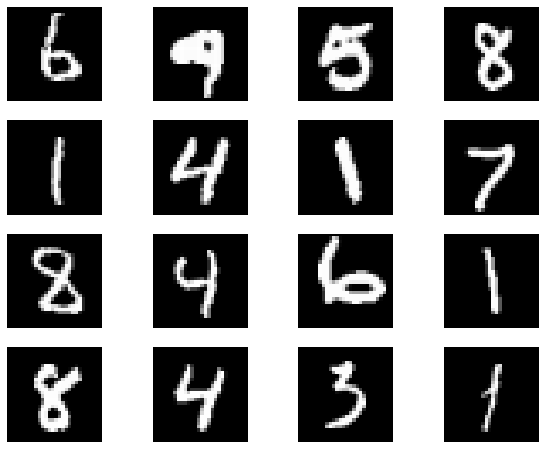

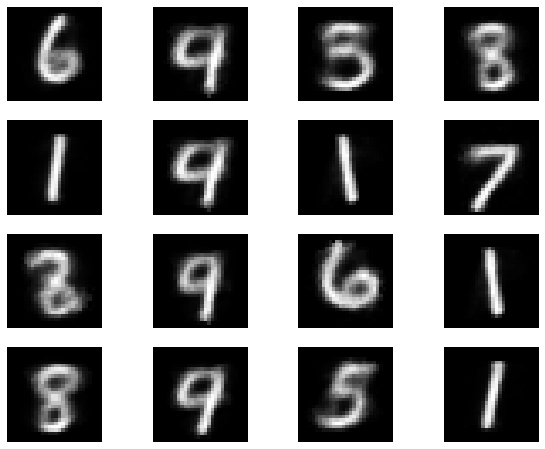

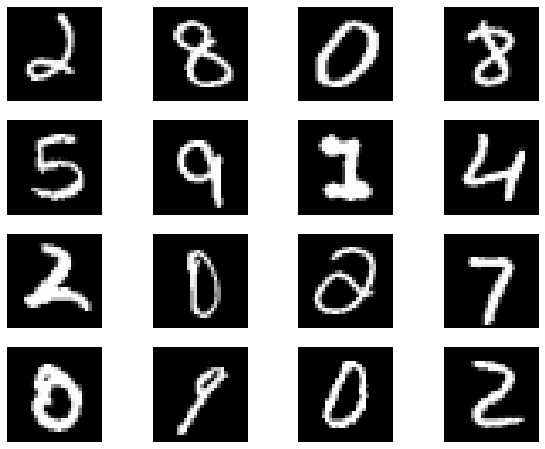

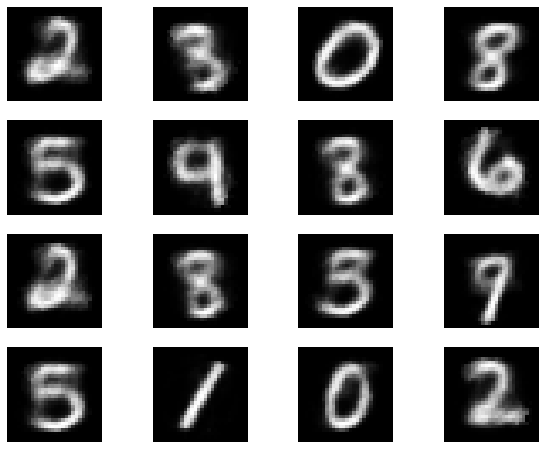

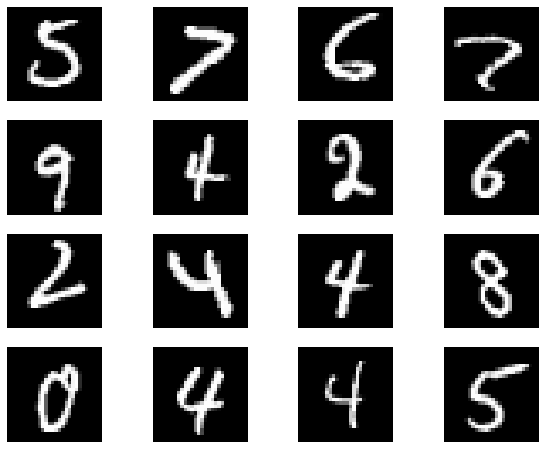

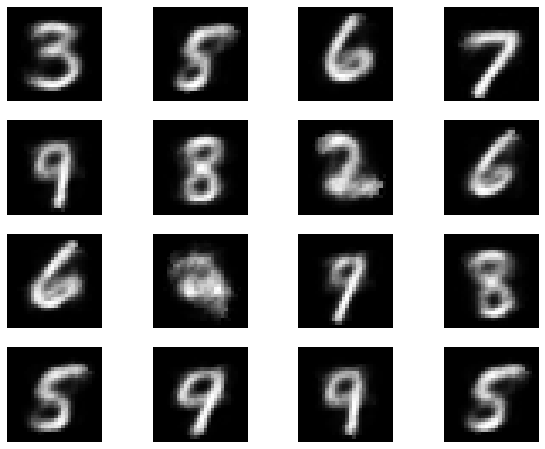

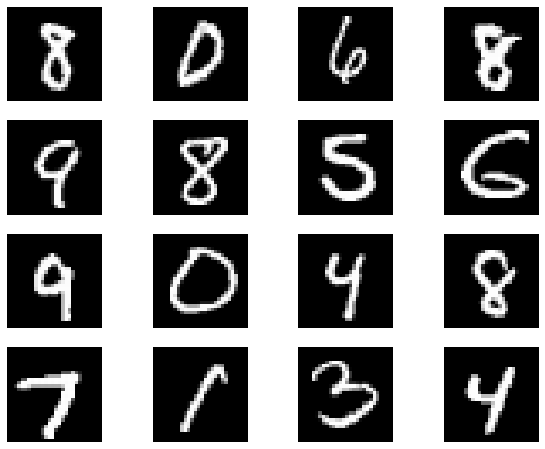

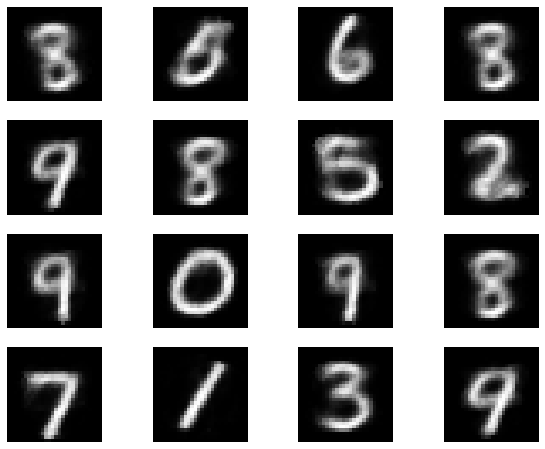

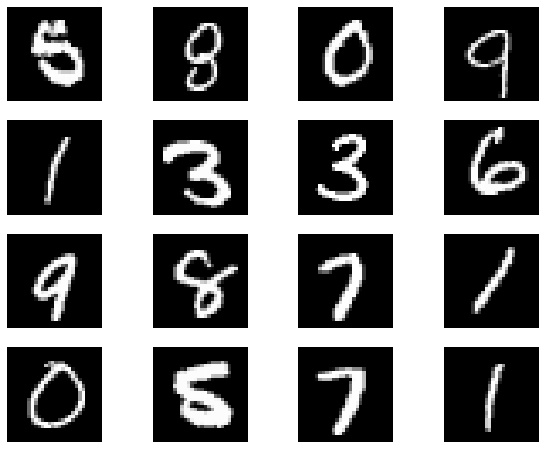

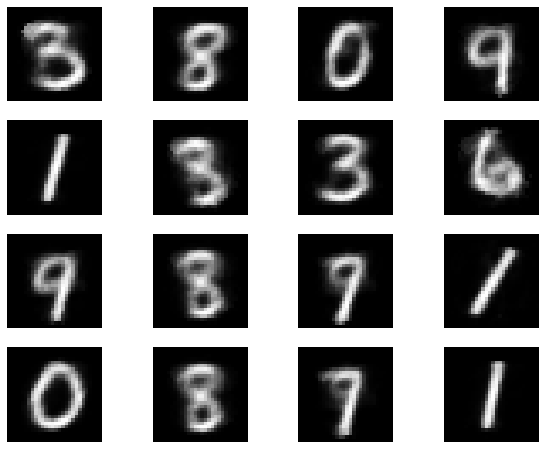

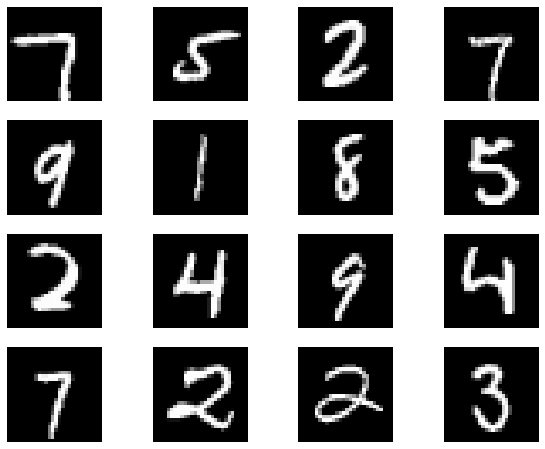

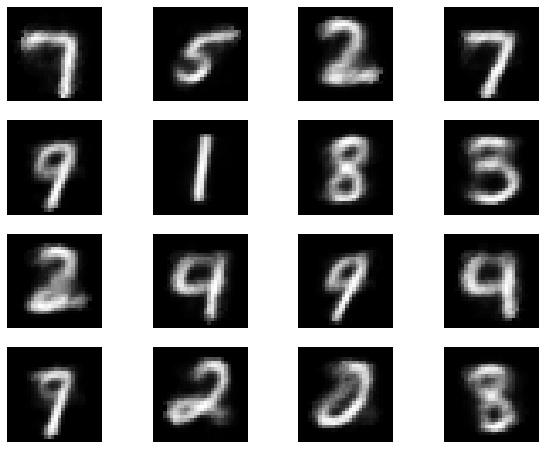

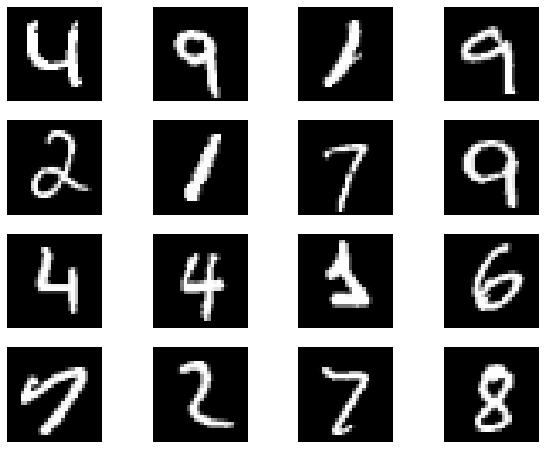

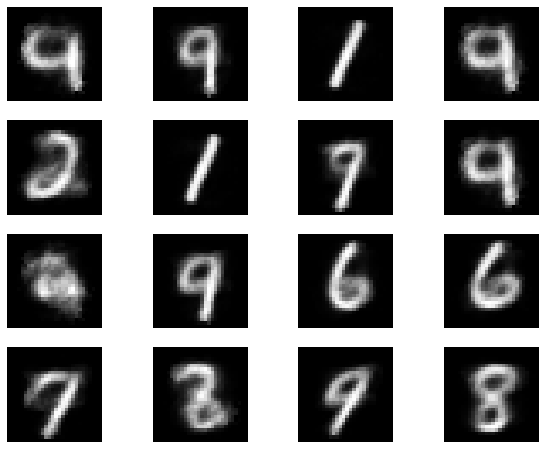

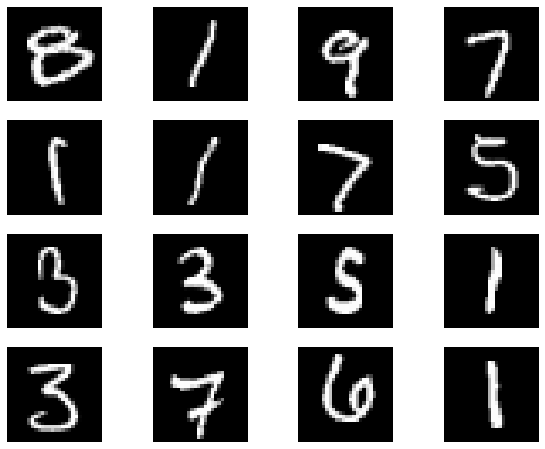

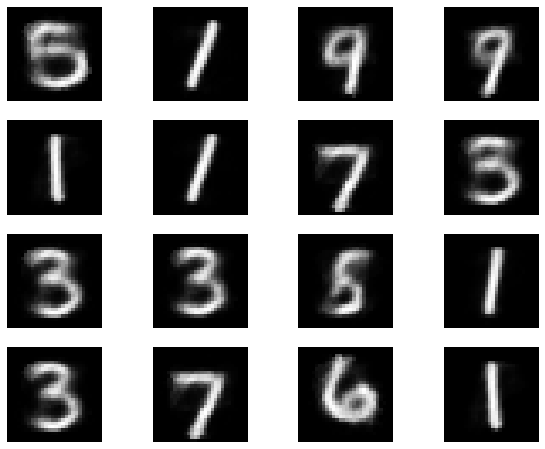

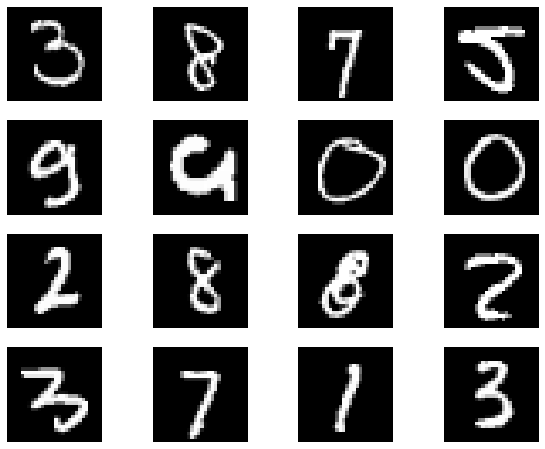

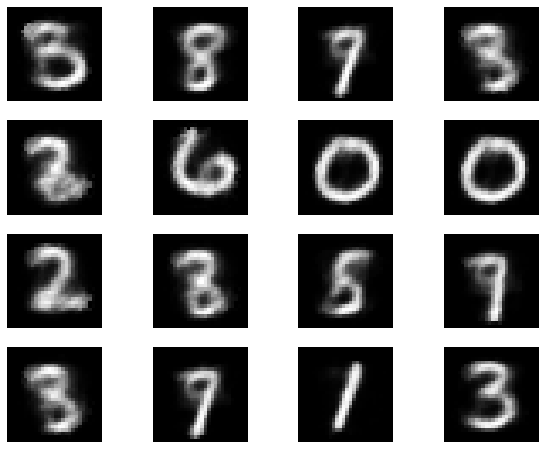

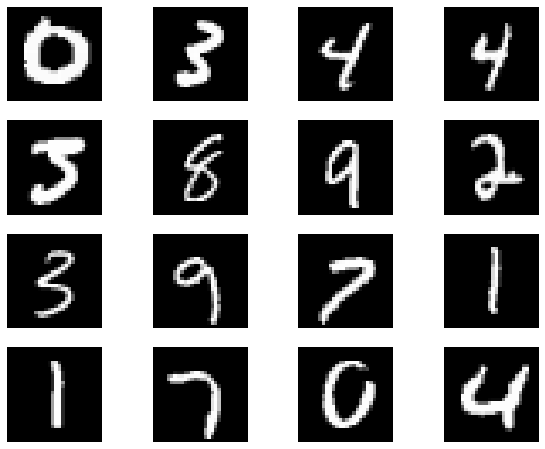

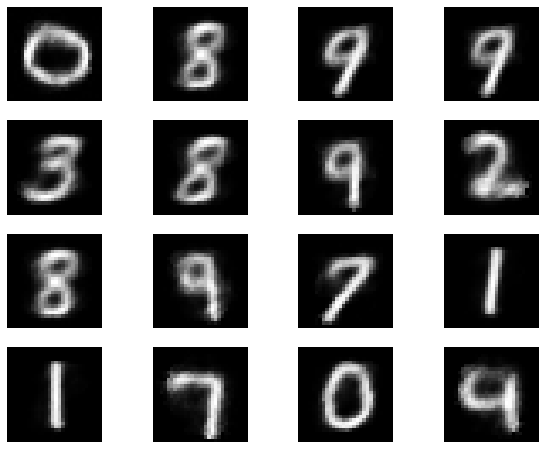

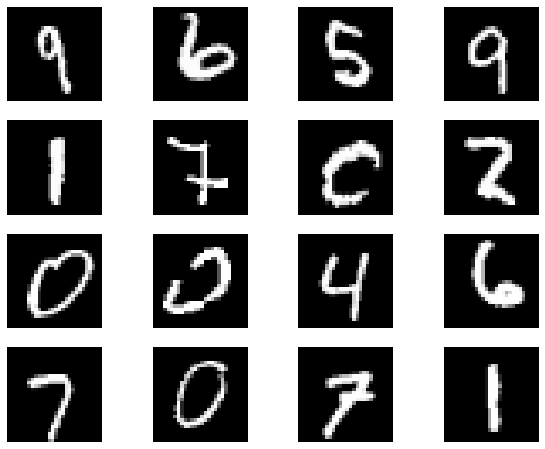

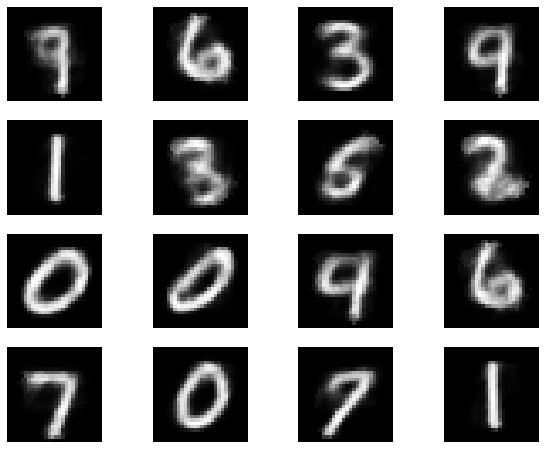

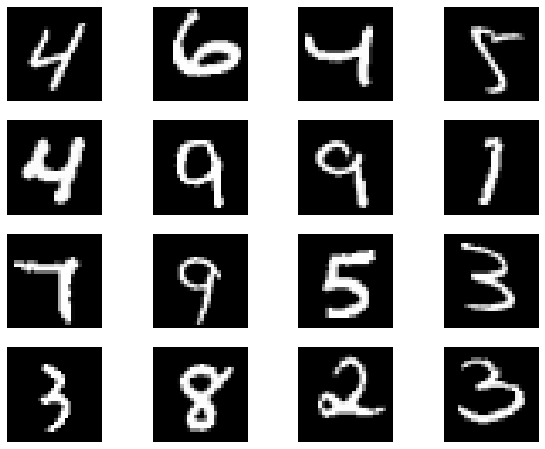

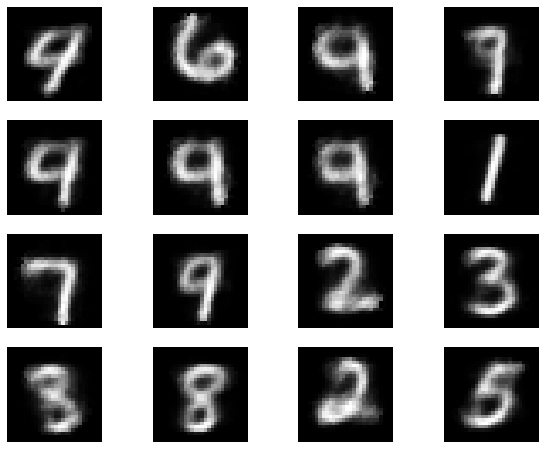

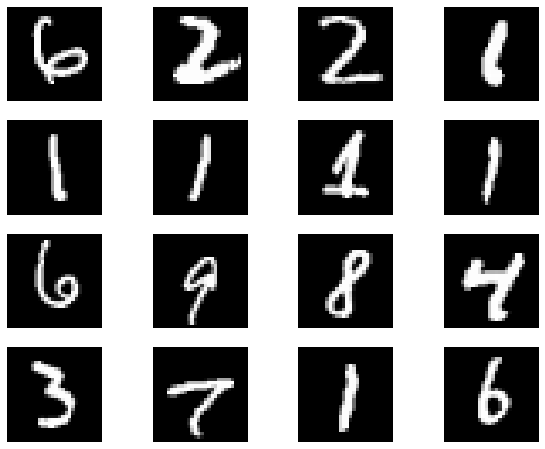

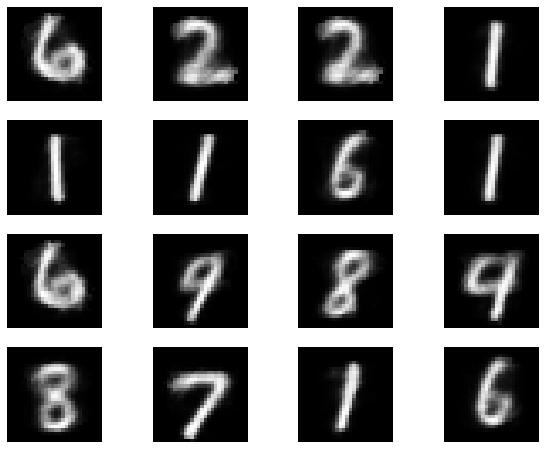

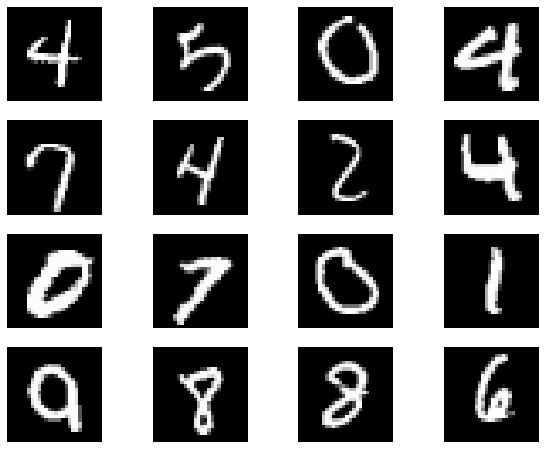

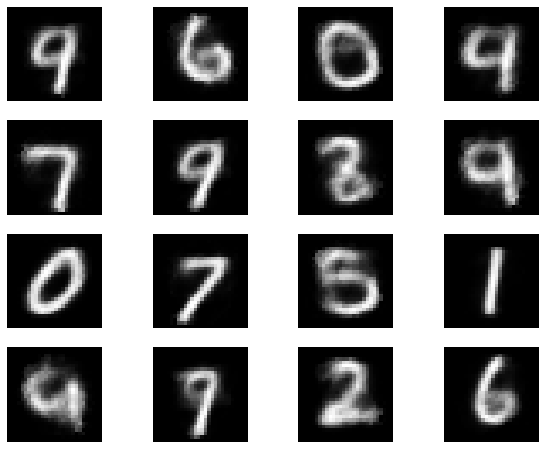

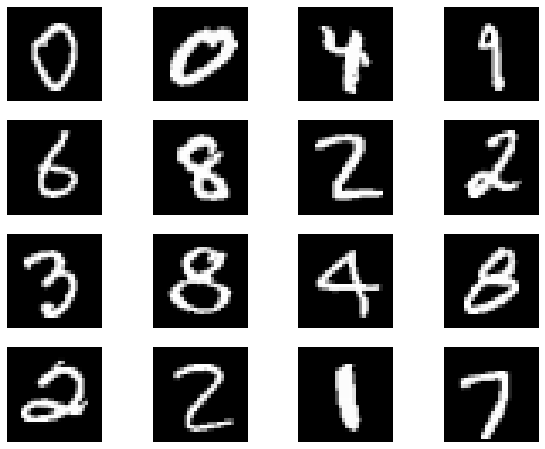

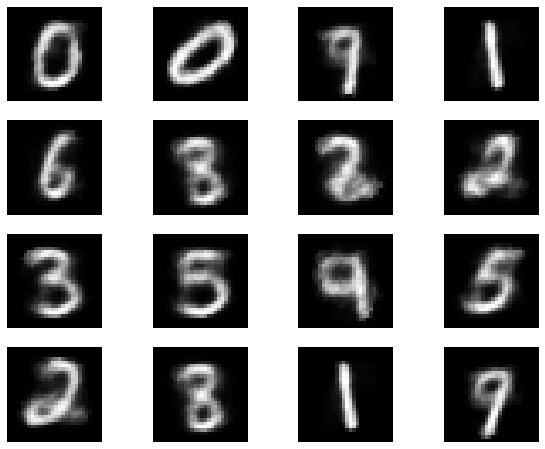

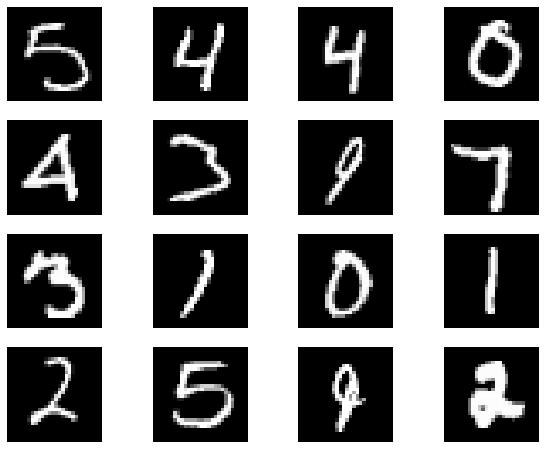

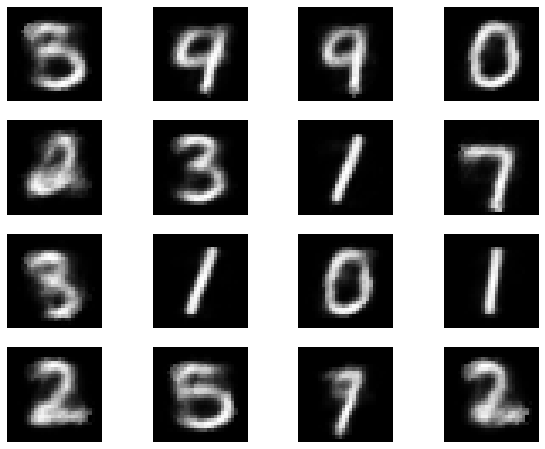

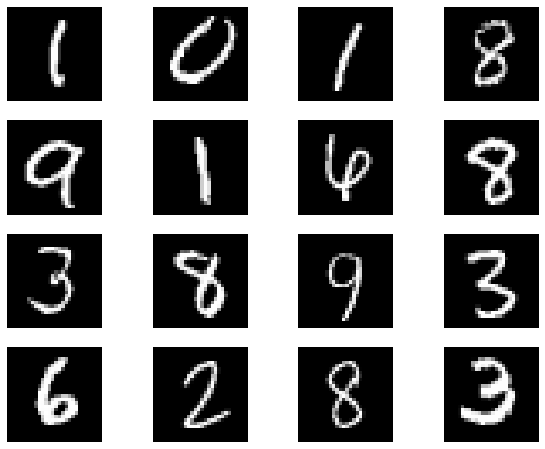

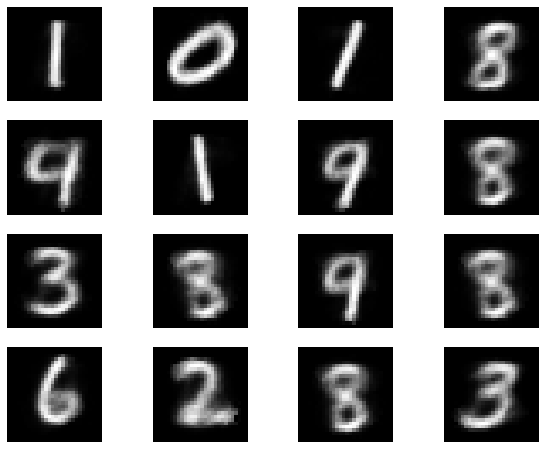

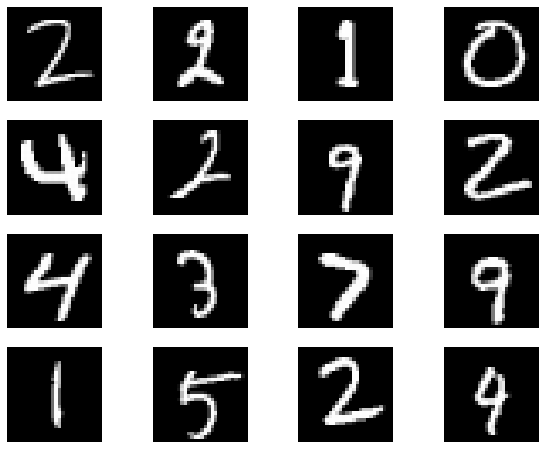

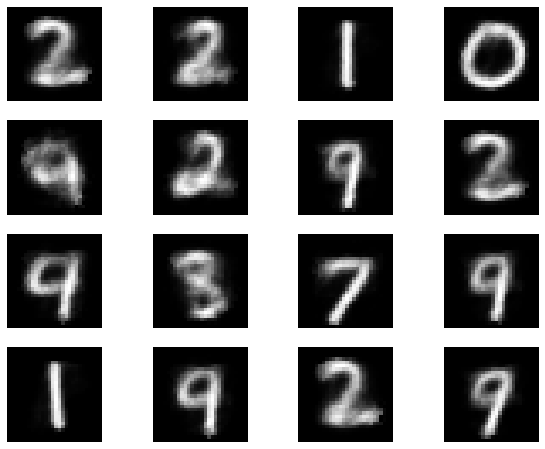

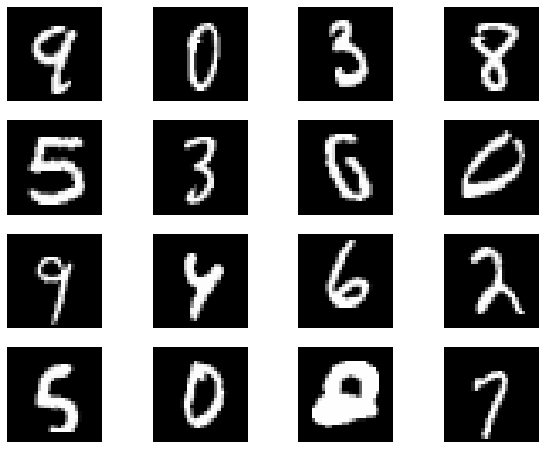

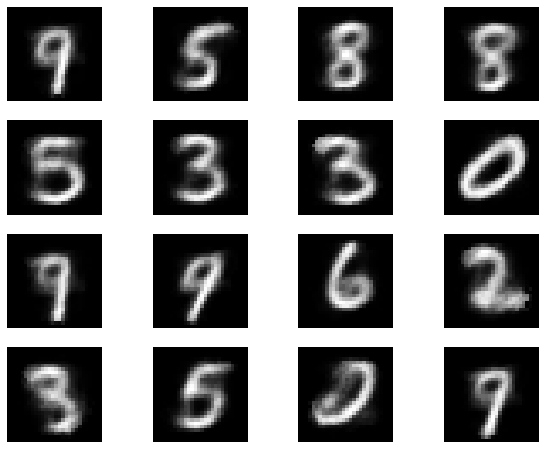

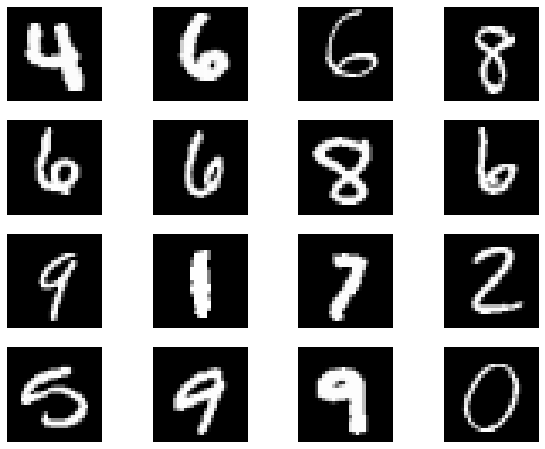

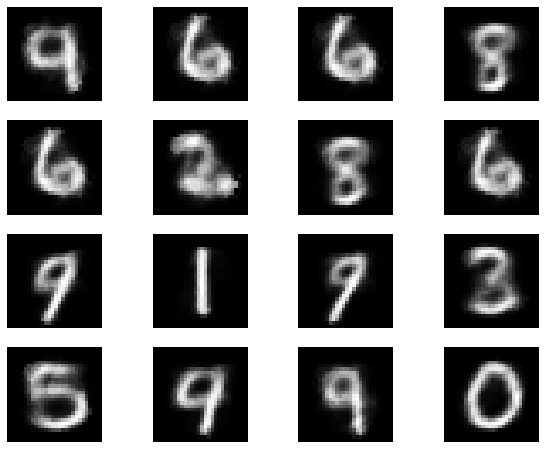

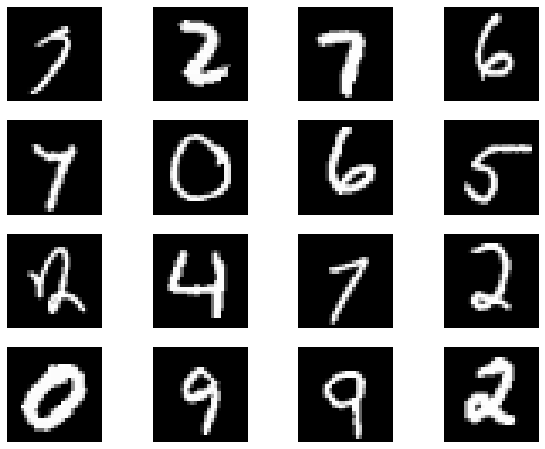

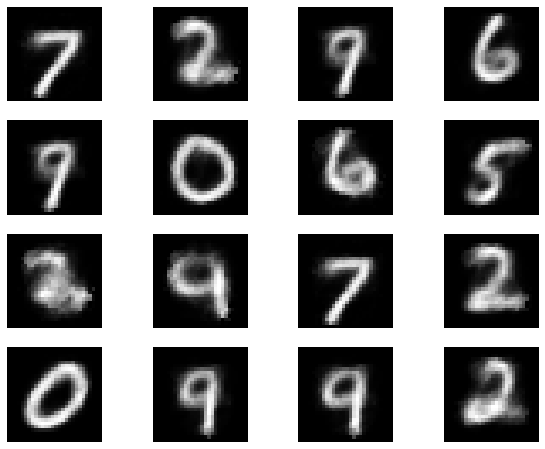

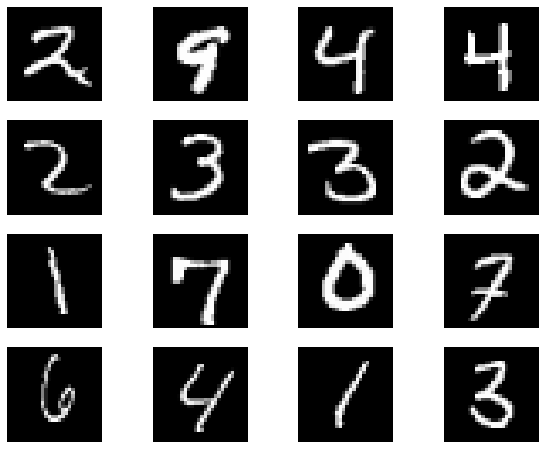

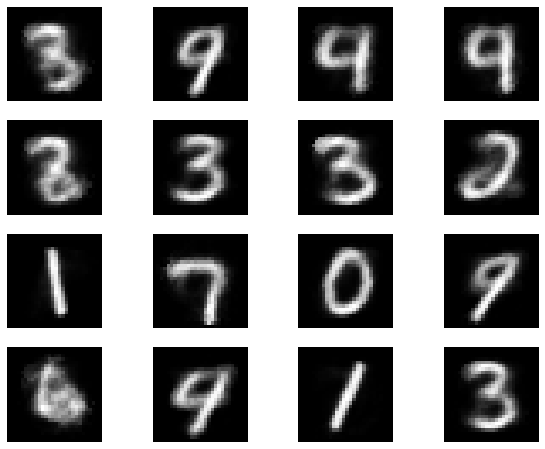

In [ ]:




# Settings
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


# Show images
def show_images(images):
    sqrtn = int(np.ceil(np.sqrt(images.shape[0])))

    for index, image in enumerate(images):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(image.reshape(28, 28))
        plt.axis('off')


# Model structure
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 16),
            nn.Tanh(),
            nn.Linear(16, 2),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        codes = self.encoder(inputs)
        decoded = self.decoder(codes)

        return codes, decoded


# Load model
model = torch.load('autoencoder.pth')
model.eval()
print(model)


# DataLoader
test_set = torchvision.datasets.MNIST(
    root='mnist',
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
test_loader = data.DataLoader(test_set, batch_size=16, shuffle=False)


# Test
with torch.no_grad():
    for data in test_loader:
        inputs = data[0].view(-1, 28*28)
        show_images(inputs)
        plt.show()

        code, outputs = model(inputs)
        show_images(outputs)
        plt.show()
        exit()